In [2]:
from neural_priors.utils.data import get_all_behavioral_data, get_all_subject_ids
import pingouin as pg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import numpy as np
import os, pickle
from scipy import stats, odr, optimize
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
!pip freeze

absl-py==2.1.0
appnope==0.1.4
arviz==0.22.0
asttokens==2.4.1
astunparse==1.6.3
bambi==0.15.0
braincoder @ git+https://github.com/Gilles86/braincoder.git@77487f8e76cf89bffae7d59e718b1f4325e063b3
cachetools==5.3.3
certifi==2024.2.2
charset-normalizer==3.3.2
cloudpickle==3.0.0
cmdstanpy==1.2.5
comm==0.2.2
cons==0.4.7
contourpy==1.2.1
cycler==0.12.1
debugpy==1.8.1
decorator==5.1.1
dill==0.3.8
dm-tree==0.1.8
etuples==0.3.10
exceptiongroup==1.2.1
executing==2.0.1
filelock==3.18.0
flatbuffers==24.3.25
fonttools==4.51.0
formulae==0.5.4
gast==0.4.0
google-auth==2.29.0
google-auth-oauthlib==0.4.6
google-pasta==0.2.0
graphviz==0.21
grpcio==1.64.0
h5netcdf==1.6.4
h5py==3.11.0
idna==3.7
ipykernel==6.29.4
ipython==8.24.0
ipywidgets==8.1.7
jedi==0.19.1
joblib==1.4.2
jupyter_client==8.6.2
jupyter_core==5.7.2
jupyterlab_widgets==3.0.15
keras==2.11.0
kiwisolver==1.4.5
libclang==18.1.1
logical-unification==0.4.6
lxml==5.2.2
Markdown==3.6
markdown-it-py==3.0.0
MarkupSafe==2.1.5
matplotlib==3.9.0
matplotli

In [4]:
plt.rcParams['legend.frameon'] = False
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 170) # 80
pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 70)

In [5]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
# COLORS_COND = {NARROW:'C0', WIDE:'C1'}; THIRD_COLOR = '#009E73'
# COLORS_COND = {NARROW:'#0072B2', WIDE:'#D55E00'}; THIRD_COLOR = '#7570B3'
# COLORS_COND = {NARROW:'#009E73', WIDE:'#E69F00'}; THIRD_COLOR = '#56B4E9'
# COLORS_COND = {NARROW:'#56B4E9', WIDE:'#CC79A7'}; THIRD_COLOR = '#999933'
#COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#55BB55'; FOURTH_COLOR = 'C4'
#COLORS_COND = {NARROW:'#56B4E9', WIDE:'xkcd:peach'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
#COLORS_COND = {NARROW:'cornflowerblue', WIDE:'C1'}; THIRD_COLOR = '#009E73'; FOURTH_COLOR = 'C4'
#COLORS_COND = {NARROW:'#008080', WIDE:'#AA3377'}; THIRD_COLOR = '#009E73'
MAX_COND = {NARROW: 25, WIDE: 40}
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [120]:
def index_filter(df, **kwargs):
    """
    Filter a DataFrame based on index level value(s) and drop levels uniquely determined
    by a single-value filter.

    For a MultiIndex, only those levels filtered by a single element (not list-like)
    that then have only one unique value in the result are dropped.
    For a simple index, if the filtering criterion is a single element and the index
    becomes constant, the index is reset (dropped).

    Parameters:
        df (pd.DataFrame): The DataFrame to filter.
        **kwargs: Each keyword corresponds to an index level name and its filter condition.
                  The condition may be a single value or a list/tuple/set of acceptable values.

    Returns:
        pd.DataFrame: The filtered DataFrame.
    """
    # No filters provided; return the original DataFrame.
    if not kwargs:
        return df

    idx = df.index

    # MultiIndex handling.
    if isinstance(idx, pd.MultiIndex):
        mask = np.ones(len(df), dtype=bool)
        # Build the mask for each provided index level.
        for level, value in kwargs.items():
            if level not in idx.names:
                raise KeyError(f"Index level '{level}' not found in MultiIndex {idx.names}.")
            if not isinstance(value, str) and hasattr(value, '__iter__'): #isinstance(value, (list, tuple, set)):
                mask &= idx.get_level_values(level).isin(value)
            else:
                mask &= (idx.get_level_values(level) == value)
        filtered_df = df[mask]

        # Only drop levels that were filtered with a single value and are constant.
        to_drop = [level for level, value in kwargs.items() 
                   if not isinstance(value, (list, tuple, set)) 
                   and filtered_df.index.get_level_values(level).nunique() == 1]
        if to_drop:
            filtered_df = filtered_df.droplevel(to_drop)
        return filtered_df

    # Simple index handling.
    else:
        if len(kwargs) > 1:
            raise ValueError("A simple index DataFrame accepts only one filtering criterion.")
        key, value = next(iter(kwargs.items()))
        # If the simple index has a name, it must match the key.
        if idx.name is not None and idx.name != key:
            raise KeyError(f"Simple index name '{idx.name}' does not match filter key '{key}'.")
        # Apply the filtering.
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            mask = idx.isin(value)
        else:
            mask = (idx == value)
        filtered_df = df[mask]

        # Drop the index (by resetting it) only if the filter was a single value and the index is constant.
        if not isinstance(value, (list, tuple, set)) and filtered_df.index.nunique() == 1:
            filtered_df = filtered_df.reset_index(drop=True)
        return filtered_df

In [121]:
def paired_strip_plot(ax, x1, x2, y1, y2, jitter=0.05,
                      marker='o', markersize=8, col1='C0', col2='C1',
                      color_line='grey', alpha=0.4, line_width=0.5,
                      color_incr_line=None, color_decr_line=None
                      ):
    """
    Creates a paired strip plot on the given axis.
    
    Parameters:
      ax : matplotlib.axes.Axes
          The axis to plot on.
      x1, x2 : float
          The x-axis positions for the two groups.
      y1, y2 : array-like
          The y-values for the two groups. They should have the same length.
      jitter : float, optional
          The standard deviation of the jitter to add to the x positions (default 0.05).
      marker : str, optional
          The marker style for the points (default 'o').
      markersize : int, optional
          The marker size (default 8).
      col1 : str, optional
          The color for the points in group 1 (default 'C0').
      col2 : str, optional
          The color for the points in group 2 (default 'C1').
      color_line : str, optional
          The color for the connecting lines (default 'grey').
      alpha : float, optional
          The transparency for points and lines (default 0.4).
      line_width : float, optional
          The width of the connecting lines (default 0.5).
    """
    
    color_incr_line = color_incr_line or color_line
    color_decr_line = color_decr_line or color_line

    # Create jittered x positions for each group
    xs1 = np.full(len(y1), x1) + np.random.normal(0, jitter, size=len(y1))
    xs2 = np.full(len(y2), x2) + np.random.normal(0, jitter, size=len(y2))

    # Plot the points for both groups with separate colors
    ax.plot(xs1, y1, linestyle='None', marker=marker, markersize=markersize,
            color=col1, alpha=alpha)
    ax.plot(xs2, y2, linestyle='None', marker=marker, markersize=markersize,
            color=col2, alpha=alpha)

    # Connect each paired point with a line
    for xi1, xi2, yi1, yi2 in zip(xs1, xs2, y1, y2):
        c = color_incr_line if yi2 > yi1 else color_decr_line if yi2 < yi1 else color_line
        ax.plot([xi1, xi2], [yi1, yi2], color=c,
                linewidth=line_width, alpha=alpha)

In [8]:
def odr_1dregression(x, y, data=None):
    if data is None:
        dat = odr.Data(x, y)
    else:
        dat = odr.Data(data[x], data[y])
    myodr = odr.ODR(dat, odr.unilinear, beta0=[1., 0.]) # start point = identity
    res = myodr.run()
    return res

def odr_pred(odr_res, x):
    B = odr_res.beta
    return B[0]*x + B[1]

In [9]:
def quick_ols(y, x):
    model = sm.OLS(y, sm.add_constant(x))
    return model.fit()

In [10]:
def star_string(pv):
    return '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else ''

In [11]:
from matplotlib.transforms import blended_transform_factory

def star_line(ax, x1, x2, y, pval, star_size=10, star_offset=0,
              star_color='black', line_color='black', line_width=1,
              vertical_lines_length=0.05, yTransAxes=False):
    """
    Draws a star and a line between two x positions at a specified y position on the given axis.

    If yTransAxes is True, y (and vertical_lines_length) are interpreted as a fraction of the y-axis.
    x1 and x2 are always in data coordinates.
    
    Parameters:
        ax: matplotlib axis
        x1, x2: x positions (data coordinates)
        y: y position; if yTransAxes is True, this is in axis fraction; otherwise data coordinates.
        pval: p-value to determine the star string.
        star_size: font size for the star.
        star_offset: vertical offset for the star text.
        star_color: color for the star text.
        line_color: color for the line.
        line_width: width of the line.
        vertical_lines_length: length of the vertical lines at the ends.
        yTransAxes: when True, y and vertical_lines_length are in fraction units.
    """
    # Choose appropriate transform for the y coordinate.
    if yTransAxes:
        # x in data coordinates and y in axes fraction.
        transform = blended_transform_factory(ax.transData, ax.transAxes)
    else:
        transform = ax.transData

    # Determine the number of stars based on the p-value.
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

    # Draw the stars at the specified position.
    ax.text((x1 + x2) / 2, y + star_offset, stars, fontsize=star_size,
            color=star_color, ha='center', va='bottom', transform=transform)

    # Draw a horizontal line between the two x positions.
    ax.plot([x1, x2], [y, y], color=line_color, linewidth=line_width, transform=transform)

    if vertical_lines_length > 0:
        # Draw vertical lines at the endpoints.
        ax.plot([x1, x1], [y - vertical_lines_length, y], color=line_color,
                linewidth=line_width, transform=transform)
        ax.plot([x2, x2], [y - vertical_lines_length, y], color=line_color,
                linewidth=line_width, transform=transform)

# Data

In [12]:
bids_folder = '../../ds-neuralpriors'

In [13]:
beh = get_all_behavioral_data(bids_folder=bids_folder) #, subjects=[f'{i}'.rjust(2,'0') for i in range(1,23)])
#beh = beh.droplevel(['session', 'run', 'trial_nr'])

In [14]:
beh

onset  phase  response  nr_frames     n  jitter  start_marker_position  response_time   onset_abs  duration   range  error  \
subject session run trial_nr                                                                                                                                    
01      1       1   1          68.826307      5       NaN       30.0  11.0     6.0                   24.0            NaN   76.378611  0.500457  narrow    NaN   
                    2          76.016292      5      19.0       31.0  23.0     4.0                   14.0       1.317963   83.568595  0.517188  narrow   -4.0   
                    3          87.026471      5      25.0       30.0  23.0     6.0                   11.0       0.834244   94.578775  0.500469  narrow    2.0   
                    4          97.085656      5      24.0       30.0  22.0     5.0                   22.0       1.701381  104.637959  0.500559  narrow    2.0   
                    5         106.744768      5      17.0       31.0  21.0     5.0                   22.0       2.018881  114.297072  0.517009  narrow   -4.0   
...                                  ...    ...       ...        ...   ...     ...                    ...            ...         ...       ...     ...    ...   
41      2       8   26        275.797056      5      25.0       30.0  24.0     4.0                   12.0       1.635028  278.746204  0.500532  narrow    1.0   
                    27        286.857371      5      24.0       30.0  19.0     6.0                   15.0       1.701679  289.806518  0.500510  narrow    5.0   
                    28        296.683059      5      22.0       30.0  17.0     5.0                   15.0       0.100000  299.632207  0.500525  narrow    5.0   
                    29        307.476458      5      19.0       30.0  19.0     6.0                   20.0       1.751607  310.425606  0.500458  narrow    0.0   
                    30        317.202043      5      19.0       30.0  19.0     5.0                   24.0       0.049945  320.151190  0.500598  narrow    0.0   

                              abs_error  squared_error  
subject session run trial_nr                            
01      1       1   1               NaN            NaN  
                    2               4.0           16.0  
                    3               2.0            4.0  
                    4               2.0            4.0  
                    5               4.0           16.0  
...                                 ...            ...  
41      2       8   26              1.0            1.0  
                    27              5.0           25.0  
                    28              5.0           25.0  
                    29              0.0            0.0  
                    30              0.0            0.0  

[18720 rows x 14 columns]

In [15]:
subjects = beh.index.get_level_values('subject').unique().astype(int)
subjects

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

In [119]:
beh.groupby(['subject', 'range']).count()

onset  phase  response  nr_frames    n  jitter  start_marker_position  response_time  onset_abs  duration  error  abs_error  squared_error
subject range                                                                                                                                             
01      narrow    240    240       236        240  240     240                    240            236        240       240    236        236            236
        wide      240    240       231        240  240     240                    240            231        240       240    231        231            231
02      narrow    240    240       238        240  240     240                    240            238        240       240    238        238            238
        wide      240    240       238        240  240     240                    240            238        240       240    238        238            238
03      narrow    240    240       233        240  240     240                    240            233        240       240    233        233            233
...               ...    ...       ...        ...  ...     ...                    ...            ...        ...       ...    ...        ...            ...
39      wide      240    240       240        240  240     240                    240            240        240       240    240        240            240
40      narrow    240    240       234        240  240     240                    240            234        240       240    234        234            234
        wide      240    240       232        240  240     240                    240            232        240       240    232        232            232
41      narrow    240    240       238        240  240     240                    240            238        240       240    238        238            238
        wide      240    240       234        240  240     240                    240            234        240       240    234        234            234

[78 rows x 13 columns]

In [16]:
#index_filter(beh, subject='01', run=1)

## Stan

In [17]:
stan = pd.read_csv('stan/outputs/summaries/results_20250909180225.csv', index_col=0)
#stan = pd.read_csv('stan/outputs/summaries/results_20250815154906.csv', index_col=0)
#stan = pd.read_csv('stan/outputs/summaries_30/results_20250804214456.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
stan

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-27492.300000,1.443070,64.707900,64.863700,-27599.300000,-27492.700000,-27386.900000,2010.54,3651.61,1.00348
z_m_0_15[1],0.114610,0.000566,0.021739,0.021247,0.078855,0.114435,0.151094,1480.90,2538.84,1.00544
z_m_0_15[2],0.099510,0.000547,0.022211,0.022235,0.063319,0.099588,0.135871,1653.63,3347.16,1.00280
z_m_0_15[3],0.116600,0.000439,0.022596,0.022414,0.079168,0.116657,0.153351,2666.43,4364.59,1.00258
z_m_0_15[4],0.101373,0.000458,0.022635,0.022545,0.063642,0.101505,0.138453,2448.83,4141.75,1.00395
...,...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.510532,0.001216,0.153398,0.154659,0.255985,0.510545,0.762470,16217.20,7281.18,1.00044
delta_avg_log_var_s_1322[36],0.620238,0.001170,0.152782,0.152259,0.368349,0.619860,0.874401,17369.80,7457.56,1.00030
delta_avg_log_var_s_1322[37],0.727767,0.001210,0.156056,0.154791,0.465421,0.728736,0.985814,16875.30,7503.76,1.00082
delta_avg_log_var_s_1322[38],0.490295,0.001218,0.158946,0.159789,0.229985,0.491158,0.751249,17153.40,7003.40,1.00109


In [18]:
stan.loc['delta_avg_var_s[1]']

Mean            5.173320
MCSE            0.007173
StdDev          0.792764
MAD             0.786831
5%              3.907980
50%             5.145010
95%             6.520660
ESS_bulk    12529.100000
ESS_tail     7702.000000
R_hat           1.001280
Name: delta_avg_var_s[1], dtype: float64

In [19]:
z = set()
for x in stan.index:
    x = x.split('[')
    if len(x) == 1:
        z.add(x[0])
    elif len(x[1].split(',')) == 1:
        z.add(x[0] + '[i]')
    else:
        z.add(x[0] + '[i,j]')
z
        

{'avg_inv_sigma_0_15',
 'avg_inv_sigma_0_30',
 'avg_inv_sigma_0_30_narrowrange',
 'avg_inv_sigma_s_15[i]',
 'avg_inv_sigma_s_15_1124[i]',
 'avg_inv_sigma_s_15_1223[i]',
 'avg_inv_sigma_s_15_1322[i]',
 'avg_inv_sigma_s_30[i]',
 'avg_inv_sigma_s_30_1124[i]',
 'avg_inv_sigma_s_30_1139[i]',
 'avg_inv_sigma_s_30_1223[i]',
 'avg_inv_sigma_s_30_1238[i]',
 'avg_inv_sigma_s_30_1322[i]',
 'avg_inv_sigma_s_30_1337[i]',
 'avg_inv_sigma_s_30_narrowrange[i]',
 'avg_log_var_0_15',
 'avg_log_var_0_30',
 'avg_log_var_0_30_narrowrange',
 'avg_log_var_s_15[i]',
 'avg_log_var_s_15_1124[i]',
 'avg_log_var_s_15_1223[i]',
 'avg_log_var_s_15_1322[i]',
 'avg_log_var_s_30[i]',
 'avg_log_var_s_30_1124[i]',
 'avg_log_var_s_30_1139[i]',
 'avg_log_var_s_30_1223[i]',
 'avg_log_var_s_30_1238[i]',
 'avg_log_var_s_30_1322[i]',
 'avg_log_var_s_30_1337[i]',
 'avg_log_var_s_30_narrowrange[i]',
 'avg_sigma_0_15',
 'avg_sigma_0_30',
 'avg_sigma_0_30_narrowrange',
 'avg_sigma_s_15[i]',
 'avg_sigma_s_15_1124[i]',
 'avg_sigma_

In [123]:
quantities = ["m", "log_var", "var", "inv_sigma", "sigma"]

# For the narrow condition (model label 15)
stan0_n_list = []
for qty in quantities:
    rows = [f'{qty}_0_15[{i}]' for i in range(1, 17)]
    # extract the three statistics
    df_temp = stan.loc[rows, ['Mean','5%', '95%']]
    # Create a MultiIndex: top level is quantity; second level is statistic name
    df_temp.columns = pd.MultiIndex.from_product([[qty], df_temp.columns])
    df_temp.reset_index(drop=True, inplace=True)
    stan0_n_list.append(df_temp)

stan0_n = pd.concat(stan0_n_list, axis=1)
stan0_n.index = pd.Index(range(10, 26), name='n')
stan0_n

# For the wide condition (model label 30)
stan0_w_list = []
for qty in quantities:
    rows = [f'{qty}_0_30[{i}]' for i in range(1, 32)]
    df_temp = stan.loc[rows, ['Mean','5%', '95%']]
    df_temp.columns = pd.MultiIndex.from_product([[qty], df_temp.columns])
    df_temp.reset_index(drop=True, inplace=True)
    stan0_w_list.append(df_temp)

stan0_w = pd.concat(stan0_w_list, axis=1)
stan0_w.index = pd.Index(range(10, 41), name='n')
stan0_w

m                     log_var                           var                     inv_sigma                        sigma                  
       Mean       5%      95%      Mean        5%       95%      Mean        5%       95%      Mean        5%       95%     Mean       5%      95%
n                                                                                                                                                 
10  10.9346  10.5456  11.3176  0.763153  0.547867  0.979843   2.16360   1.72956   2.66404  0.684256  0.612674  0.760383  1.46775  1.31513  1.63219
11  11.9544  11.5373  12.3668  1.611810  1.409920  1.812390   5.04923   4.09563   6.12508  0.447515  0.404058  0.494129  2.24288  2.02377  2.47489
12  13.1879  12.7638  13.6229  1.868180  1.671820  2.068260   6.52289   5.32186   7.91098  0.393645  0.355537  0.433479  2.54944  2.30692  2.81265
13  14.2110  13.7844  14.6356  1.787760  1.594490  1.983720   6.01818   4.92580   7.26976  0.409784  0.370886  0.450569  2.44889  2.21942  2.69625
14  15.3914  14.9534  15.8281  1.967070  1.773030  2.162010   7.19888   5.88868   8.68861  0.374627  0.339254  0.412089  2.67847  2.42666  2.94764
15  16.6141  16.1918  17.0387  1.930720  1.739080  2.123570   6.94099   5.69208   8.36096  0.381485  0.345837  0.419145  2.63014  2.38581  2.89153
16  17.6919  17.2270  18.1479  2.048390  1.847100  2.250050   7.81382   6.34137   9.48816  0.359759  0.324645  0.397108  2.79008  2.51820  3.08028
17  18.4997  18.0508  18.9525  2.038500  1.844620  2.231150   7.73357   6.32571   9.31059  0.361503  0.327727  0.397599  2.77602  2.51510  3.05132
18  19.4194  18.9623  19.8752  2.107540  1.910500  2.307720   8.28828   6.75646  10.05150  0.349255  0.315416  0.384716  2.87368  2.59932  3.17041
19  20.4993  20.0614  20.9500  2.080550  1.891150  2.270280   8.06268   6.62695   9.68207  0.353947  0.321378  0.388457  2.83474  2.57429  3.11160
20  20.8752  20.3868  21.3673  2.389620  2.197640  2.585950  10.98610   9.00372  13.27600  0.303290  0.274452  0.333264  3.30872  3.00062  3.64362
21  22.0089  21.5384  22.4734  2.219360  2.024870  2.418340   9.26792   7.57513  11.22720  0.330256  0.298445  0.363333  3.03885  2.75230  3.35070
22  22.8545  22.3840  23.3292  2.357370  2.166860  2.549910  10.63590   8.73082  12.80600  0.308212  0.279443  0.338433  3.25567  2.95480  3.57855
23  23.6976  23.2343  24.1720  2.255440  2.060080  2.455520   9.60850   7.84658  11.65250  0.324352  0.292947  0.356993  3.09417  2.80118  3.41358
24  24.4312  23.9608  24.9142  2.322040  2.128470  2.519980  10.26920   8.40197  12.42830  0.313723  0.283657  0.344992  3.19886  2.89862  3.52538
25  25.2283  24.7250  25.7333  2.423630  2.227890  2.619840  11.36870   9.28031  13.73350  0.298195  0.269842  0.328260  3.36565  3.04636  3.70588
26  25.7850  25.2908  26.2824  2.447470  2.250450  2.650430  11.64710   9.49205  14.16010  0.294685  0.265746  0.324579  3.40631  3.08092  3.76299
27  26.9111  26.4038  27.4133  2.550550  2.358920  2.746320  12.90490  10.57950  15.58510  0.279846  0.253306  0.307445  3.58600  3.25262  3.94779
28  27.3964  26.8936  27.9079  2.517360  2.322220  2.715310  12.48380  10.19830  15.10930  0.284532  0.257263  0.313138  3.52701  3.19348  3.88707
29  27.9992  27.5005  28.5056  2.572590  2.380610  2.766270  13.19020  10.81150  15.89940  0.276768  0.250790  0.304129  3.62558  3.28807  3.98740
30  28.7537  28.2466  29.2584  2.525510  2.325420  2.724140  12.58800  10.23090  15.24330  0.283385  0.256130  0.312639  3.54154  3.19858  3.90426
31  29.4332  28.9338  29.9455  2.644580  2.452700  2.835540  14.17260  11.61970  17.03970  0.266973  0.242253  0.293362  3.75832  3.40875  4.12791
32  29.8569  29.3649  30.3402  2.553770  2.368380  2.743130  12.93840  10.68010  15.53550  0.279352  0.253710  0.305994  3.59122  3.26804  3.94151
33  30.5896  30.0822  31.0915  2.502970  2.310860  2.696390  12.30470  10.08310  14.82610  0.286578  0.259709  0.314921  3.50165  3.17540  3.85048
34  30.8875  30.3483  31.4262  2.639270  

In [124]:
stan0_n

m                     log_var                          var                   inv_sigma                        sigma                  
       Mean       5%      95%      Mean        5%       95%     Mean       5%      95%      Mean        5%       95%     Mean       5%      95%
n                                                                                                                                              
10  11.1461  10.7886  11.5109  0.661072  0.495531  0.826779  1.94663  1.64137  2.28595  0.719442  0.661404  0.780543  1.39346  1.28116  1.51194
11  11.9951  11.6332  12.3587  1.059760  0.896815  1.224350  2.89995  2.45179  3.40195  0.589400  0.542170  0.638645  1.70083  1.56582  1.84444
12  13.1660  12.7917  13.5335  1.411810  1.249370  1.572170  4.12297  3.48812  4.81711  0.494249  0.455624  0.535432  2.02809  1.86765  2.19479
13  14.0137  13.6364  14.3845  1.316440  1.158250  1.479520  3.74816  3.18438  4.39084  0.518394  0.477228  0.560387  1.93368  1.78448  2.09543
14  15.1406  14.7601  15.5146  1.344410  1.183580  1.508750  3.85469  3.26605  4.52107  0.511203  0.470304  0.553335  1.96094  1.80722  2.12628
15  16.2123  15.8374  16.5953  1.466620  1.310120  1.625530  4.35447  3.70661  5.08109  0.480868  0.443631  0.519411  2.08434  1.92526  2.25413
16  17.0915  16.7104  17.4672  1.426830  1.268000  1.585320  4.18458  3.55373  4.88082  0.490530  0.452641  0.530466  2.04328  1.88514  2.20926
17  17.6601  17.2765  18.0376  1.392870  1.234820  1.553580  4.04561  3.43777  4.72840  0.498953  0.459878  0.539339  2.00897  1.85412  2.17448
18  18.5127  18.1381  18.8908  1.423350  1.260440  1.583960  4.17114  3.52698  4.87421  0.491415  0.452948  0.532474  2.03987  1.87802  2.20776
19  19.0910  18.7204  19.4692  1.442570  1.282630  1.605950  4.25205  3.60613  4.98260  0.486716  0.447994  0.526598  2.05956  1.89898  2.23217
20  19.8395  19.4711  20.2091  1.461460  1.304460  1.621330  4.33207  3.68567  5.05981  0.482110  0.444563  0.520885  2.07898  1.91981  2.24941
21  20.6471  20.2683  21.0344  1.583810  1.422040  1.744120  4.89653  4.14558  5.72088  0.453517  0.418089  0.491142  2.21020  2.03606  2.39184
22  20.9632  20.5911  21.3311  1.472580  1.317120  1.632120  4.38052  3.73267  5.11470  0.479436  0.442170  0.517595  2.09057  1.93201  2.26157
23  21.5788  21.2047  21.9577  1.440830  1.285820  1.597240  4.24335  3.61766  4.93937  0.487099  0.449951  0.525758  2.05761  1.90202  2.22247
24  22.1172  21.7434  22.4818  1.370940  1.212120  1.530360  3.95765  3.36061  4.61986  0.504447  0.465250  0.545496  1.98704  1.83319  2.14938
25  22.5727  22.2008  22.9403  1.294240  1.130100  1.459160  3.66660  3.09596  4.30234  0.524207  0.482112  0.568332  1.91243  1.75953  2.07421

In [127]:
pd.concat([stan0_n, stan0_w], keys=['narrow', 'wide'], names=['condition', 'n'])

m                     log_var                           var                     inv_sigma                        sigma                  
                 Mean       5%      95%      Mean        5%       95%      Mean        5%       95%      Mean        5%       95%     Mean       5%      95%
condition n                                                                                                                                                 
narrow    10  11.1461  10.7886  11.5109  0.661072  0.495531  0.826779   1.94663   1.64137   2.28595  0.719442  0.661404  0.780543  1.39346  1.28116  1.51194
          11  11.9951  11.6332  12.3587  1.059760  0.896815  1.224350   2.89995   2.45179   3.40195  0.589400  0.542170  0.638645  1.70083  1.56582  1.84444
          12  13.1660  12.7917  13.5335  1.411810  1.249370  1.572170   4.12297   3.48812   4.81711  0.494249  0.455624  0.535432  2.02809  1.86765  2.19479
          13  14.0137  13.6364  14.3845  1.316440  1.158250  1.479520   3.74816   3.18438   4.39084  0.518394  0.477228  0.560387  1.93368  1.78448  2.09543
          14  15.1406  14.7601  15.5146  1.344410  1.183580  1.508750   3.85469   3.26605   4.52107  0.511203  0.470304  0.553335  1.96094  1.80722  2.12628
          15  16.2123  15.8374  16.5953  1.466620  1.310120  1.625530   4.35447   3.70661   5.08109  0.480868  0.443631  0.519411  2.08434  1.92526  2.25413
          16  17.0915  16.7104  17.4672  1.426830  1.268000  1.585320   4.18458   3.55373   4.88082  0.490530  0.452641  0.530466  2.04328  1.88514  2.20926
          17  17.6601  17.2765  18.0376  1.392870  1.234820  1.553580   4.04561   3.43777   4.72840  0.498953  0.459878  0.539339  2.00897  1.85412  2.17448
          18  18.5127  18.1381  18.8908  1.423350  1.260440  1.583960   4.17114   3.52698   4.87421  0.491415  0.452948  0.532474  2.03987  1.87802  2.20776
          19  19.0910  18.7204  19.4692  1.442570  1.282630  1.605950   4.25205   3.60613   4.98260  0.486716  0.447994  0.526598  2.05956  1.89898  2.23217
          20  19.8395  19.4711  20.2091  1.461460  1.304460  1.621330   4.33207   3.68567   5.05981  0.482110  0.444563  0.520885  2.07898  1.91981  2.24941
          21  20.6471  20.2683  21.0344  1.583810  1.422040  1.744120   4.89653   4.14558   5.72088  0.453517  0.418089  0.491142  2.21020  2.03606  2.39184
          22  20.9632  20.5911  21.3311  1.472580  1.317120  1.632120   4.38052   3.73267   5.11470  0.479436  0.442170  0.517595  2.09057  1.93201  2.26157
          23  21.5788  21.2047  21.9577  1.440830  1.285820  1.597240   4.24335   3.61766   4.93937  0.487099  0.449951  0.525758  2.05761  1.90202  2.22247
          24  22.1172  21.7434  22.4818  1.370940  1.212120  1.530360   3.95765   3.36061   4.61986  0.504447  0.465250  0.545496  1.98704  1.83319  2.14938
          25  22.5727  22.2008  22.9403  1.294240  1.130100  1.459160   3.66660   3.09596   4.30234  0.524207  0.482112  0.568332  1.91243  1.75953  2.07421
wide      10  10.9346  10.5456  11.3176  0.763153  0.547867  0.979843   2.16360   1.72956   2.66404  0.684256  0.612674  0.760383  1.46775  1.31513  1.63219
          11  11.9544  11.5373  12.3668  1.611810  1.409920  1.812390   5.04923   4.09563   6.12508  0.447515  0.404058  0.494129  2.24288  2.02377  2.47489
          12  13.1879  12.7638  13.6229  1.868180  1.671820  2.068260   6.52289   5.32186   7.91098  0.393645  0.355537  0.433479  2.54944  2.30692  2.81265
          13  14.2110  13.7844  14.6356  1.787760  1.594490  1.983720   6.01818   4.92580   7.26976  0.409784  0.370886  0.450569  2.44889  2.21942  2.69625
          14  15.3914  14.9534  15.8281  1.967070  1.773030  2.162010   7.19888   5.88868   8.68861  0.374627  0.339254  0.412089  2.67847  2.42666  2.94764
          15  16.6141  16.1918  17.0387  1.930720  1.739080  2.123570   6.94099   5.69208   8.36096  0.381485  0.345837  0.419145  2.63014  2.38581  2.89153
          16  17.6919  17.2270  18.1479  2.048390  1.847100  2.250050   7.81382   6.34137   9.4

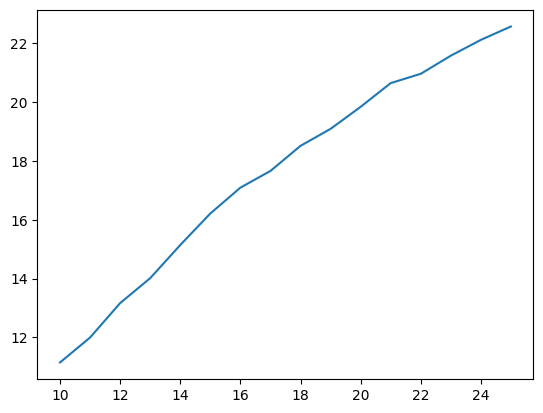

In [126]:
plt.plot(stan0_n.index, stan0_n.m.Mean)

In [22]:
dats = []
for nstr_stan in ['', '_narrowrange', '_1124', '_1223', '_1322', '_1139', '_1238', '_1337']:
    #the_index = index_filter(fisher_info_deltas, model_label=15).index
    dats_nstr_stan = []
    conds = []
    for cond in CONDITIONS:
        if cond is NARROW and nstr_stan in ['_1139', '_1238', '_1337']:
            continue
        conds.append(cond)
        da = []
        nn_cond = {NARROW: '15', WIDE: '30'}[cond]
        for qty in ['avg_var', 'avg_sigma', 'avg_inv_sigma', 'avg_log_var' ]:
            if cond is NARROW and nstr_stan == '_narrowrange':
                da.append( stan.loc[[f'{qty}_s_15[{subject}]' for subject in range(1,40)], 'Mean'].rename(qty).reset_index(drop=True) )
            else:
                da.append( stan.loc[[f'{qty}_s_{nn_cond}{nstr_stan}[{subject}]' for subject in range(1,40)], 'Mean'].rename(qty).reset_index(drop=True) )
        stan_avgs_cond = pd.concat(da, axis=1)
        stan_avgs_cond.index = subjects
        dats_nstr_stan.append(stan_avgs_cond)
    stan_avgs_nstr = pd.concat(dats_nstr_stan, axis=0, keys=conds)
    stan_avgs_nstr.index.names = ['condition', 'subject']
    dats.append(stan_avgs_nstr)

stan_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322', '1139', '1238', '1337'])
stan_avgs.index.names = ['subrange', 'condition', 'subject']
stan_avgs

avg_var  avg_sigma  avg_inv_sigma  avg_log_var
subrange condition subject                                                 
all      narrow    1         4.52088    2.09285       0.493343      1.44519
                   2         5.15803    2.23618       0.461450      1.57827
                   3         6.72513    2.54331       0.409841      1.82631
                   4         5.61183    2.33472       0.440872      1.66681
                   5         4.06040    1.95983       0.544057      1.28464
...                              ...        ...            ...          ...
1337     wide      37       11.41220    3.27085       0.326721      2.30413
                   38       12.14610    3.36843       0.318773      2.35849
                   39       10.44700    3.12579       0.344917      2.20704
                   40        9.43286    2.98738       0.354276      2.13250
                   41       13.41200    3.54345       0.302852      2.46119

[507 rows x 4 columns]

In [23]:
dats = []
for nstr_stan in ['', '_narrowrange', '_1124', '_1223', '_1322']:
    #the_index = index_filter(fisher_info_deltas, model_label=15).index
    dats_nstr_stan = []
    for qty in ['avg_var', 'avg_sigma', 'avg_inv_sigma', 'avg_log_var' ]:
        dats_nstr_stan.append( stan.loc[[f'delta_{qty}_s{nstr_stan}[{subject}]' for subject in range(1,40)], 'Mean'].rename(f'{qty}_delta_wn').reset_index(drop=True) )
    stan_delta_avgs_nstr = pd.concat(dats_nstr_stan, axis=1)
    stan_delta_avgs_nstr.index = subjects
    dats.append(stan_delta_avgs_nstr)
stan_delta_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322'])
stan_delta_avgs.index.names = ['subrange', 'subject']
stan_delta_avgs

avg_var_delta_wn  avg_sigma_delta_wn  avg_inv_sigma_delta_wn  avg_log_var_delta_wn
subrange subject                                                                                    
all      1                 5.17332            0.932365               -0.142582              0.710005
         2                 5.29726            0.899024               -0.118458              0.638796
         3                 7.48430            1.100130               -0.114686              0.688436
         4                 6.19712            1.007670               -0.121861              0.686229
         5                 8.78104            1.481420               -0.219818              1.089600
...                            ...                 ...                     ...                   ...
1322     37                3.33378            0.633996               -0.108835              0.510532
         38                3.85896            0.755370               -0.133280              0.620238
         39                4.27392            0.851008               -0.166874              0.727767
         40                3.06597            0.598276               -0.105300              0.490295
         41                7.38094            1.257330               -0.187008              0.932225

[195 rows x 4 columns]

In [24]:
subj_i_to_subj = {(i+1):subj for i,subj in enumerate( stan_delta_avgs.index.get_level_values('subject').unique()) }
print(subj_i_to_subj)

{1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 24, 23: 25, 24: 26, 25: 27, 26: 28, 27: 29, 28: 30, 29: 31, 30: 32, 31: 33, 32: 34, 33: 35, 34: 36, 35: 37, 36: 38, 37: 39, 38: 40, 39: 41}


In [25]:
das = []
quantities = ['m_s', 'sigma_s', 'var_s', 'inv_sigma_s', 'log_var_s', ]
for qty in quantities:
    da = []
    for cond in CONDITIONS:
        cond_k = {NARROW: 15, WIDE: 30}[cond]
        for subject in range(1, 40):
            nmax = {NARROW: 17, WIDE: 32}[cond]
            for n in range(1, nmax):
                v = stan.loc[f'{qty}_{cond_k}[{subject},{n}]', 'Mean']
                da.append([subj_i_to_subj[subject], cond, n+9., v])
    da = pd.DataFrame(da, columns=['subject', 'condition', 'n', qty[:-2]]).set_index(['subject', 'condition', 'n'])
    das.append(da)
stan_subj_n = pd.concat(das, axis=1)
stan_subj_n['bias'] = stan_subj_n['m'] - stan_subj_n.index.get_level_values('n')
stan_subj_n['log_n'] = np.log(stan_subj_n.index.get_level_values('n'))
stan_subj_n



m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6271  2.06576   4.33406   0.491465  1.43574  1.6271  2.302585
                  11.0  12.9481  1.69995   2.96530   0.603194  1.03588  1.9481  2.397895
                  12.0  14.6908  2.39927   5.88443   0.425824  1.72871  2.6908  2.484907
                  13.0  14.9564  2.13192   4.65695   0.480253  1.49023  1.9564  2.564949
                  14.0  16.8771  2.08874   4.46597   0.489797  1.45015  2.8771  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7192  3.64400  13.99690   0.289542  2.53287 -0.2808  3.583519
                  37.0  35.2929  3.63005  13.72570   0.286904  2.53779 -1.7071  3.610918
                  38.0  36.1955  3.43760  12.37650   0.304800  2.42296 -1.8045  3.637586
                  39.0  36.7015  3.29584  11.28910   0.314963  2.34759 -2.2985  3.663562
                  40.0  37.2749  3.09158  10.10140   0.342095  2.20157 -2.7251  3.688879

[1833 rows x 7 columns]

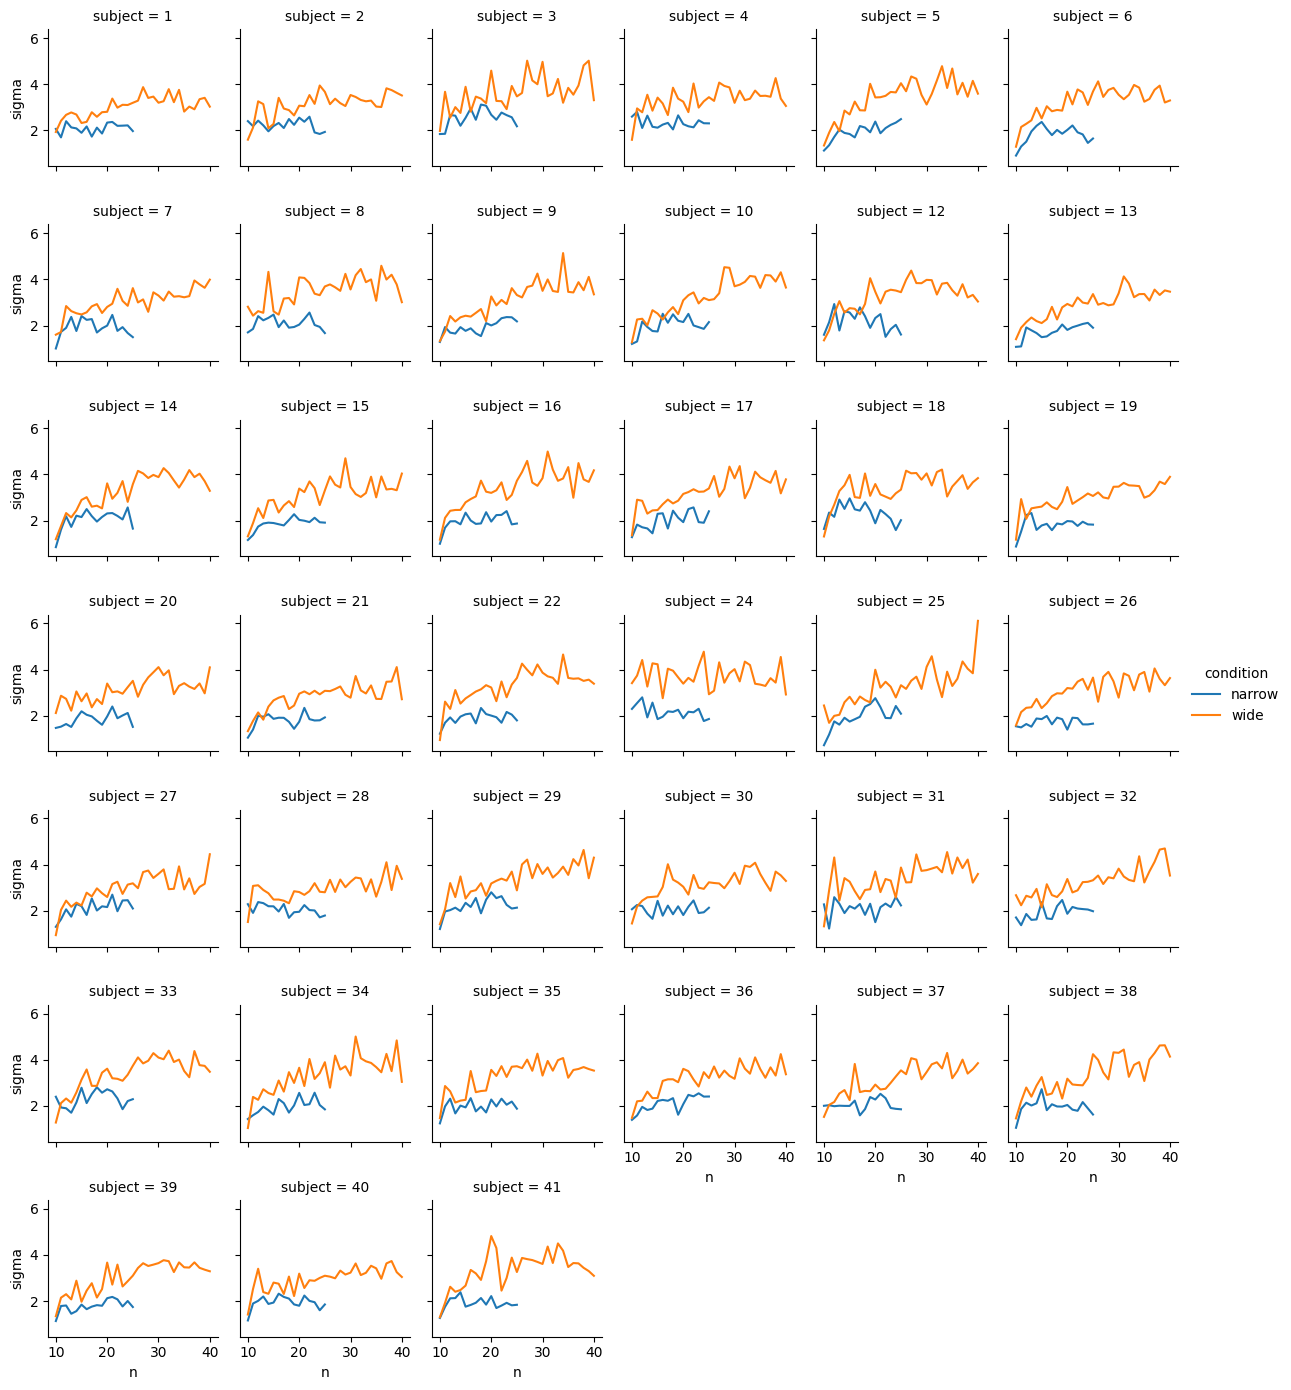

In [26]:
sns.relplot(stan_subj_n, x='n', y='sigma', hue='condition', kind='line', col='subject', col_wrap=6, height=2)

In [27]:
das = []
for qty in ['delta_inv_sigma_s', 'delta_log_var_s', 'delta_sigma_s', 'delta_var_s',
            ]:
    da = []
    for subject in range(1, 40):
        for n in range(1, 17):
            v = stan.loc[f'{qty}[{subject},{n}]', 'Mean']
            da.append([subj_i_to_subj[subject], n+9., v])
    da = pd.DataFrame(da, columns=['subject', 'n', qty[:-2]]).set_index(['subject', 'n'])
    das.append(da)
stan_deltas_subj_n = pd.concat(das, axis=1)
stan_deltas_subj_n

delta_inv_sigma  delta_log_var  delta_sigma  delta_var
subject n                                                           
1       10.0         0.039015      -0.143129    -0.133141  -0.502046
        11.0        -0.179203       0.705200     0.718774   3.037980
        12.0        -0.038018       0.202496     0.276524   1.552040
        13.0        -0.110987       0.528181     0.647982   3.282000
        14.0        -0.100952       0.483441     0.600344   3.100070
...                       ...            ...          ...        ...
41      21.0        -0.372635       1.869150     2.598490  15.944600
        22.0        -0.141807       0.593044     0.647813   2.963900
        23.0        -0.182260       0.865990     1.078390   5.648060
        24.0        -0.307031       1.531800     2.065310  12.007800
        25.0        -0.239819       1.132190     1.419140   7.571230

[624 rows x 4 columns]

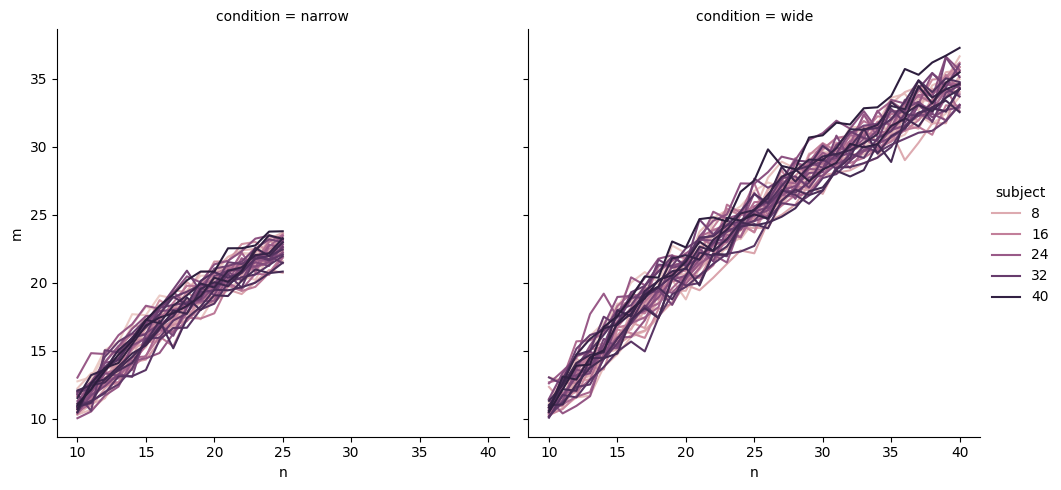

In [28]:
sns.relplot(stan_subj_n, x='n', y='m', hue='subject', kind='line', col='condition')

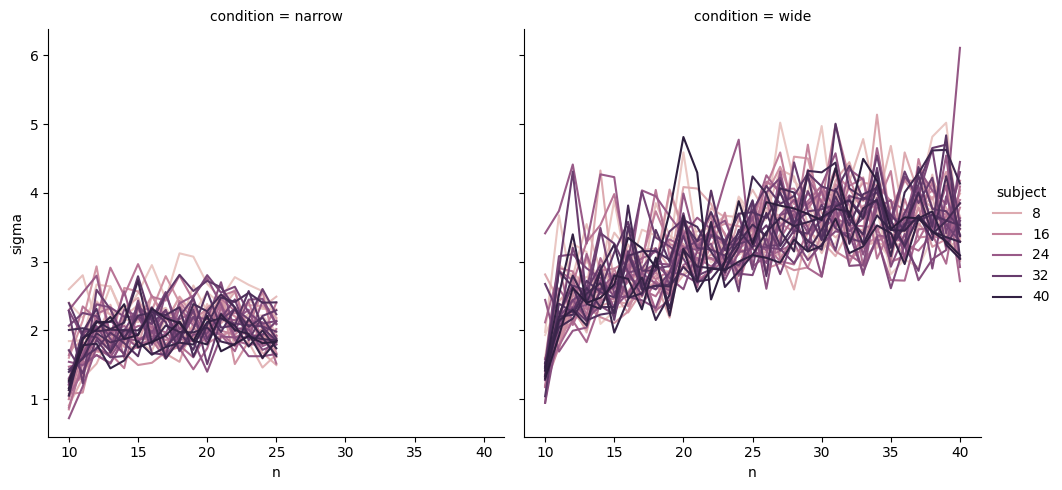

In [29]:
sns.relplot(stan_subj_n, x='n', y='sigma', hue='subject', kind='line', col='condition')

In [30]:
stan_subj_n

m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6271  2.06576   4.33406   0.491465  1.43574  1.6271  2.302585
                  11.0  12.9481  1.69995   2.96530   0.603194  1.03588  1.9481  2.397895
                  12.0  14.6908  2.39927   5.88443   0.425824  1.72871  2.6908  2.484907
                  13.0  14.9564  2.13192   4.65695   0.480253  1.49023  1.9564  2.564949
                  14.0  16.8771  2.08874   4.46597   0.489797  1.45015  2.8771  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7192  3.64400  13.99690   0.289542  2.53287 -0.2808  3.583519
                  37.0  35.2929  3.63005  13.72570   0.286904  2.53779 -1.7071  3.610918
                  38.0  36.1955  3.43760  12.37650   0.304800  2.42296 -1.8045  3.637586
                  39.0  36.7015  3.29584  11.28910   0.314963  2.34759 -2.2985  3.663562
                  40.0  37.2749  3.09158  10.10140   0.342095  2.20157 -2.7251  3.688879

[1833 rows x 7 columns]

In [31]:
stan_subj_n.loc[(1,NARROW)]

/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_75445/1672512187.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  stan_subj_n.loc[(1,NARROW)]


,m,sigma,var,inv_sigma,log_var,bias,log_n
n,,,,,,,
10.0,11.6271,2.06576,4.33406,0.491465,1.43574,1.6271,2.302585
11.0,12.9481,1.69995,2.96530,0.603194,1.03588,1.9481,2.397895
12.0,14.6908,2.39927,5.88443,0.425824,1.72871,2.6908,2.484907
13.0,14.9564,2.13192,4.65695,0.480253,1.49023,1.9564,2.564949
14.0,16.8771,2.08874,4.46597,0.489797,1.45015,2.8771,2.639057
15.0,18.2262,1.89881,3.71091,0.541636,1.25414,3.2262,2.708050
16.0,17.9286,2.17288,4.81242,0.468855,1.53335,1.9286,2.772589
17.0,17.8211,1.73342,3.06997,0.589136,1.07904,0.8211,2.833213
18.0,18.8151,2.12153,4.57889,0.479358,1.48733,0.8151,2.890372


In [32]:
stan.loc[f'm_0_15[16]']

Mean          22.572700
MCSE           0.004559
StdDev         0.225751
MAD            0.226838
5%            22.200800
50%           22.574400
95%           22.940300
ESS_bulk    2472.370000
ESS_tail    4738.950000
R_hat          1.002300
Name: m_0_15[16], dtype: float64

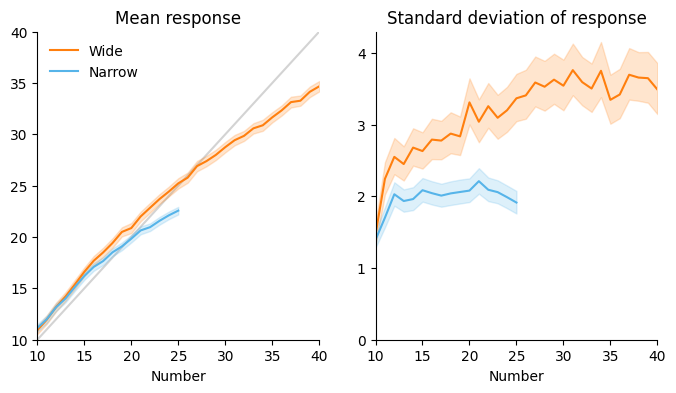

In [33]:
with_mse = False
fig, axs = subplots(ncols=2+with_mse, nrows=1, figsize=(4*(2+with_mse),4))

def plot_subjects_stan(axs):
    qties = ['m_0', 'sigma_0', ] # 'log_inv_var_0']
    if with_mse:
        qties.append('sqrt_mse')
    for iq, qty in enumerate(qties):
        ax = axs[iq]
        for cond in reversed(CONDITIONS):
            c = COLORS_COND[cond]
            xs = np.arange(10, MAX_COND[cond]+1, 1)
            # for subject in stan_subj_n.index.get_level_values('subject').unique():
            #     ax.plot(xs, stan_subj_n.loc[(subject, cond), qty[:-2]], c=c, alpha=.1)
            vs = []; vs_5 = []; vs_95 = []
            delta = int( {NARROW: W_NARROW, WIDE: W_WIDE}[cond] )
            for j in range(1,delta+2):
                r = stan.loc[f'{qty}_{delta}[{j}]']
                vs.append( r['Mean'] )
                vs_5.append( r['5%'] )
                vs_95.append( r['95%'] )
            ax.plot(xs, vs, c=c, alpha=1., label=cond.capitalize())
            ax.fill_between(xs, vs_5, vs_95, color=c, alpha=.2)

plot_subjects_stan(axs.flat)
axs = axs.flat
axs[0].legend(loc='upper left')
#axs[0].set_ylabel('Response'); # $\hat x$
#axs[1].set_ylabel('Standard deviation of response');
axs[0].set_title('Mean response')
axs[1].set_title('Standard deviation of response')
if with_mse:
    axs[2].set_ylabel('$\sqrt{MSE} = \sqrt{bias^2 + variance}$');
for ax in axs: #.flatten():
    ax.set_xlim(10,40)
    #ax.set_xticks([30,40,50,60,70,80,90])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axs[1].set_ylim(0,None)
axs[1].set_yticks([0,1,2,3,4])
axs[0].set_ylim(10,40)
axs[0].axline((10,10), slope=1, c='lightgrey', zorder=-100)
# for ax in axs[:,0]:
#     ax.set_ylim(41,80)
#     ax.set_yticks([41,50,60,70,80])
#     ax.axline((60,60), slope=1, c='lightgrey', zorder=-1000)
# for ax in axs[:,1]:
#     ax.set_ylim(1.7,5.)
#     ax.set_yticks([2,3,4,5])
# for ax in axs[:,2]:
#     ax.set_ylim(2,11)
#     ax.set_yticks([2,4,6,8,10])
for ax in axs:
    ax.set_xlabel('Number') # $x$
#axs[1].set_xlim(13,22)
#fig.savefig(apc.todayDirPath() + '/subjects.pdf', bbox_inches='tight', transparent=False)

## fMRI

### Fisher information

In [34]:
fisher_info = pd.read_csv('decoding/fisher_information.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6, 8] ) #['fisher_information'] 
print( fisher_info.index.names )
print( fisher_info.index.get_level_values('fit_response').unique() )
print( fisher_info.index.get_level_values('smoothed').unique() )
#print( fisher_info.index.get_level_values('spherical_noise').unique() )
#print( fisher_info.index.get_level_values('separate_sigmas').unique() )
print( fisher_info.index.get_level_values('model_label').unique() )
fisher_info = fisher_info.droplevel('fit_response').droplevel('smoothed').droplevel('Unnamed: 0').droplevel(None) #.droplevel('spherical_noise') #.droplevel('model_label')
# print('!!! dropping separate_sigmas = True')
# fisher_info = index_filter(fisher_info, separate_sigmas=False)
#fisher_info['log_fi'] = np.log(fisher_info['fisher_information'])
fisher_info['sqrt_fi'] = np.sqrt(fisher_info['fisher_information'])
fisher_info['inv_fi'] = 1./(fisher_info['fisher_information'])
fisher_info['inv_sqrt_fi'] = 1./np.sqrt(fisher_info['fisher_information'])
fisher_info = fisher_info.rename(columns={'fisher_information': 'fi', 'log(fisher_information)': 'log_fi'})
fisher_info['log_n'] = np.log(fisher_info.index.get_level_values('n'))
fisher_info

['subject', 'model_label', 'fit_response', 'smoothed', None, 'Unnamed: 0', 'n', 'condition']
Index([False], dtype='bool', name='fit_response')
Index([True], dtype='bool', name='smoothed')
Index([31], dtype='int64', name='model_label')


fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      31          36.0 wide       0.273421 -1.296742  0.522897  3.657362     1.912423  3.583519
                    37.0 wide       0.255428 -1.364815  0.505399  3.914997     1.978635  3.610918
                    38.0 wide       0.238561 -1.433131  0.488427  4.191801     2.047389  3.637586
                    39.0 wide       0.222782 -1.501563  0.471997  4.488700     2.118655  3.663562
                    40.0 wide       0.208044 -1.570006  0.456118  4.806678     2.192414  3.688879

[2418 rows x 6 columns]

In [35]:
fisher_info_1518 = pd.read_csv('decoding/2025-06-26 fisher_information.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6, 8] ) #['fisher_information'] 
print( fisher_info_1518.index.get_level_values('fit_response').unique() )
print( fisher_info_1518.index.get_level_values('smoothed').unique() )
print( fisher_info_1518.index.get_level_values('spherical_noise').unique() )
print( fisher_info_1518.index.get_level_values('separate_sigmas').unique() )
print( fisher_info_1518.index.get_level_values('model_label').unique() )
fisher_info_1518 = fisher_info_1518.droplevel('fit_response').droplevel('smoothed').droplevel('spherical_noise') #.droplevel('model_label')
print('!!! dropping separate_sigmas = True')
fisher_info_1518 = index_filter(fisher_info_1518, separate_sigmas=False)
fisher_info_1518['log_fi'] = np.log(fisher_info_1518['fisher_information'])
fisher_info_1518['sqrt_fi'] = np.sqrt(fisher_info_1518['fisher_information'])
fisher_info_1518['inv_fi'] = 1./(fisher_info_1518['fisher_information'])
fisher_info_1518['inv_sqrt_fi'] = 1./np.sqrt(fisher_info_1518['fisher_information'])
fisher_info_1518 = fisher_info_1518.rename(columns={'fisher_information': 'fi'})
fisher_info_1518['log_n'] = np.log(fisher_info_1518.index.get_level_values('n'))
fisher_info_1518

Index([False], dtype='bool', name='fit_response')
Index([True], dtype='bool', name='smoothed')
Index([True], dtype='bool', name='spherical_noise')
Index([False, True], dtype='bool', name='separate_sigmas')
Index([15, 18], dtype='int64', name='model_label')
!!! dropping separate_sigmas = True


fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       15          10.0 narrow     5.692601  1.739167  2.385917  0.175667     0.419126  2.302585
                    11.0 narrow     3.702477  1.309002  1.924182  0.270089     0.519701  2.397895
                    12.0 narrow     0.979151 -0.021069  0.989521  1.021293     1.010590  2.484907
                    13.0 narrow     1.185767  0.170390  1.088929  0.843336     0.918333  2.564949
                    14.0 narrow     0.537878 -0.620123  0.733402  1.859156     1.363509  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879

[3666 rows x 6 columns]

In [36]:
fisher_info.columns, fisher_info_1518.columns

(Index(['fi', 'log_fi', 'sqrt_fi', 'inv_fi', 'inv_sqrt_fi', 'log_n'], dtype='object'),
 Index(['fi', 'log_fi', 'sqrt_fi', 'inv_fi', 'inv_sqrt_fi', 'log_n'], dtype='object'))

In [37]:
fisher_info.index.names, fisher_info_1518.index.names

(FrozenList(['subject', 'model_label', 'n', 'condition']),
 FrozenList(['subject', 'model_label', 'n', 'condition']))

In [38]:
fisher_info = pd.concat([fisher_info, fisher_info_1518], )
fisher_info

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879

[6084 rows x 6 columns]

In [39]:
dats = []
for nstr in ['', '_narrowrange', '_1124', '_1223', '_1322']:
    a, b  = (-100,100) if nstr=='' else (10,25) if nstr == '_narrowrange' else (11,24) if nstr == '_1124' else (12,23) if nstr == '_1223' else (13,22)
    dats.append( index_filter(fisher_info, n=range(a, b+1)).groupby(['subject', 'model_label', 'condition' ]).mean() ) # 
fisher_info_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322']).drop(columns=['log_n'])
fisher_info_avgs.index.names = ['subrange', 'subject', 'model_label', 'condition'] # 'model_label',
fisher_info_avgs

fi    log_fi   sqrt_fi     inv_fi  inv_sqrt_fi
subrange subject model_label condition                                                      
all      1       15          narrow     0.855621 -1.172242  0.706231   5.068577     2.080115
                             wide       0.251763 -2.447645  0.377351  18.130914     3.942094
                 18          narrow     0.843114 -1.413441  0.656623   6.623666     2.375812
                             wide       0.274819 -2.578914  0.368716  21.365276     4.262218
                 31          narrow     0.516915 -1.606773  0.541309   6.827314     2.467959
...                                          ...       ...       ...        ...          ...
1322     41      15          wide       0.701192 -0.361723  0.835927   1.444619     1.200130
                 18          narrow     2.052164  0.713177  1.430516   0.493025     0.701097
                             wide       0.666308 -0.407681  0.815933   1.505791     1.226607
                 31          narrow     1.587406  0.455942  1.258020   0.638048     0.797441
                             wide       0.772112 -0.283385  0.873105   1.356512     1.158676

[1170 rows x 5 columns]

In [40]:
fisher_info_avgs_deltas = (index_filter(fisher_info_avgs, condition=WIDE) - index_filter(fisher_info_avgs, condition=NARROW)).add_suffix('_delta_wn')
fisher_info_avgs_deltas

fi_delta_wn  log_fi_delta_wn  sqrt_fi_delta_wn  inv_fi_delta_wn  inv_sqrt_fi_delta_wn
subrange subject model_label                                                                                       
all      1       15             -0.603858        -1.275403         -0.328880        13.062337              1.861979
                 18             -0.568295        -1.165473         -0.287907        14.741609              1.886406
                 31             -0.243635        -0.661894         -0.140797         7.439760              1.063984
         2       15             -0.067489        -0.678275         -0.104880         8.066872              1.143553
                 18             -0.063444        -0.715131         -0.104180         9.804793              1.288462
...                                   ...              ...               ...              ...                   ...
1322     40      18             -0.084845        -1.425479         -0.142589       117.164516              5.463195
                 31             -0.014305        -0.475928         -0.041205        22.762243              1.536526
         41      15             -1.275781        -1.038396         -0.568427         0.933682              0.486266
                 18             -1.385856        -1.120858         -0.614584         1.012767              0.525510
                 31             -0.815294        -0.739327         -0.384916         0.718464              0.361235

[585 rows x 5 columns]

In [41]:
fisher_info

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n
subject model_label n    condition                                                               
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057
...                                      ...       ...       ...       ...          ...       ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879

[6084 rows x 6 columns]

In [42]:
fisher_info_deltas = ( index_filter(fisher_info, condition=WIDE ) - index_filter(fisher_info, condition=NARROW) ).drop(columns=['log_n']).add_suffix('_diff')
fisher_info_deltas['log_n'] = np.log(fisher_info_deltas.index.get_level_values('n'))
fisher_info_deltas

fi_diff  log_fi_diff  sqrt_fi_diff  inv_fi_diff  inv_sqrt_fi_diff     log_n
subject model_label n                                                                                 
1       15          10.0 -4.517753    -1.578028     -1.302013     0.675507          0.503465  2.302585
                    11.0 -1.851967    -0.693541     -0.563848     0.270302          0.215412  2.397895
                    12.0  0.759647     0.574263      0.329114    -0.446183         -0.252230  2.484907
                    13.0 -0.642712    -0.780934     -0.352006     0.998097          0.438661  2.564949
                    14.0 -0.162006    -0.358384     -0.120318     0.801324          0.267589  2.639057
...                            ...          ...           ...          ...               ...       ...
41      31          36.0  0.004423     0.016310      0.004247    -0.060139         -0.015659  3.583519
                    37.0  0.014591     0.058820      0.014647    -0.237189         -0.059056  3.610918
                    38.0  0.022645     0.099737      0.023760    -0.439636         -0.104689  3.637586
                    39.0  0.028919     0.139042      0.031699    -0.669591         -0.152532  3.663562
                    40.0  0.033701     0.176723      0.038574    -0.929131         -0.202541  3.688879

[3627 rows x 6 columns]

### Decoding quantities

In [43]:
fmri_estimates_stats = pd.read_csv('decoding/expected_uncertainty.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] )
#fmri_estimates_stats = pd.read_csv('decoding/2025-07-31 expected_uncertainty.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6 ] )
#fmri_estimates_stats = pd.read_csv('decoding/2025-07-24 expected_uncertainty.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, ] )

print( fmri_estimates_stats.index.get_level_values('subject').unique() )
print( fmri_estimates_stats.index.get_level_values('model_label').unique() )
print( fmri_estimates_stats.index.get_level_values('fit_response').unique() )
print( fmri_estimates_stats.index.get_level_values('smoothed').unique() )
print( fmri_estimates_stats.index.get_level_values('spherical_noise').unique() )
print( fmri_estimates_stats.index.get_level_values('many_samples').unique() )
print( fmri_estimates_stats.index.get_level_values(None).unique() )
print( fmri_estimates_stats.index.get_level_values('wide').unique() )
fmri_estimates_stats.index = fmri_estimates_stats.index.droplevel(['fit_response', 'smoothed', 'spherical_noise', None ] ).rename({'range': 'condition'}) # 'spherical_noise',  'model_label'
# fmri_estimates_stats.index = fmri_estimates_stats.index.droplevel(['fit_response', 'smoothed', ] ).rename({'range': 'condition'}) # 'spherical_noise',  'model_label'
fmri_estimates_stats = index_filter(fmri_estimates_stats, many_samples=True)
fmri_estimates_stats['sigma'] = np.sqrt( fmri_estimates_stats.var_E )
fmri_estimates_stats['bias'] = fmri_estimates_stats.mean_E - fmri_estimates_stats.index.get_level_values('n')
fmri_estimates_stats['log_var'] = np.log(fmri_estimates_stats.var_E)
fmri_estimates_stats['log_n'] = np.log(fmri_estimates_stats.index.get_level_values('n'))
# if 'wide_prior' not in fmri_estimates_stats.index.names:
#     fmri_estimates_stats = fmri_estimates_stats.set_index(pd.Index([True]*len(fmri_estimates_stats), name='wide_prior'), append=True)
#     fmri_estimates_stats = fmri_estimates_stats.reorder_levels(['subject', 'model_label', 'wide_prior', 'condition', 'n'], axis=0)
fmri_estimates_stats

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')
Index([15, 18, 31], dtype='int64', name='model_label')
Index([False], dtype='bool', name='fit_response')
Index([True], dtype='bool', name='smoothed')
Index([True], dtype='bool', name='spherical_noise')
Index([False, True], dtype='bool', name='many_samples')
Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61],
      dtype='int64')
Index([False, True], dtype='bool', name='wide')


mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide  condition n                                                                                            
1       15          False narrow    10.0  10.631045    0.631045  1.276577        0.631045  1.129857  0.631045  0.244182  2.302585
                                    11.0  11.175836    0.175836  0.259381        0.219162  0.509295  0.175836 -1.349456  2.397895
                                    12.0  12.060424    0.060424  0.282017        0.273017  0.531053  0.060424 -1.265786  2.484907
                                    13.0  13.059976    0.059976  0.596356        0.474482  0.772241  0.059976 -0.516918  2.564949
                                    14.0  14.295382    0.295382  0.779362        0.649081  0.882815  0.295382 -0.249280  2.639057
...                                             ...         ...       ...             ...       ...       ...       ...       ...
41      31          True  wide      36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
                                    37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
                                    38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
                                    39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
                                    40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[10998 rows x 8 columns]

In [44]:
fmri_estimates_stats.index.names

FrozenList(['subject', 'model_label', 'wide', 'condition', 'n'])

In [45]:
#### we don't need this anymore

fmri_estimates_stats_1518 = pd.read_csv('decoding/2025-07-16 expected_error_pars.tsv', sep='\t', index_col=[0, 1, 2, 3, 4, 5, 6, ] )
print( fmri_estimates_stats_1518.index.get_level_values('spherical_noise').unique() )
print( fmri_estimates_stats_1518.index.get_level_values('smoothed').unique() )
print( fmri_estimates_stats_1518.index.get_level_values('fit_response').unique() )
print( fmri_estimates_stats_1518.index.get_level_values('model_label').unique() )
fmri_estimates_stats_1518.index = fmri_estimates_stats_1518.index.droplevel(['smoothed', 'fit_response', 'spherical_noise',] ).rename({'range': 'condition'}) # 
fmri_estimates_stats_1518['sigma'] = np.sqrt( fmri_estimates_stats_1518.var_E )
fmri_estimates_stats_1518['bias'] = fmri_estimates_stats_1518.mean_E - fmri_estimates_stats_1518.index.get_level_values('n')
fmri_estimates_stats_1518['log_var'] = np.log(fmri_estimates_stats_1518.var_E)
fmri_estimates_stats_1518['log_n'] = np.log(fmri_estimates_stats_1518.index.get_level_values('n'))
fmri_estimates_stats_1518
# add index level in the MultiIndex, named "wide_prior", and with value False for all rows
fmri_estimates_stats_1518 = fmri_estimates_stats_1518.set_index(pd.Index([False]*len(fmri_estimates_stats_1518), name='wide'), append=True)
# reorder the index levels to have 'wide_prior' as the third level
fmri_estimates_stats_1518 = fmri_estimates_stats_1518.reorder_levels(fmri_estimates_stats.index.names, axis=0)
fmri_estimates_stats_1518

Index([True], dtype='bool', name='spherical_noise')
Index([True], dtype='bool', name='smoothed')
Index([False], dtype='bool', name='fit_response')
Index([15, 18], dtype='int64', name='model_label')


/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide  condition n                                                                                            
1       15          False narrow    10.0  10.611801    0.611800  1.425448        0.611800  1.193921  0.611801  0.354486  2.302585
                                    11.0  11.137037    0.137037  0.243799        0.190036  0.493760  0.137037 -1.411413  2.397895
                                    12.0  12.139342    0.139343  0.358819        0.279343  0.599015  0.139342 -1.024939  2.484907
                                    13.0  13.040127    0.040127  0.605830        0.476747  0.778351  0.040127 -0.501155  2.564949
                                    14.0  14.287040    0.287040  0.827021        0.657156  0.909407  0.287040 -0.189925  2.639057
...                                             ...         ...       ...             ...       ...       ...       ...       ...
40      18          False wide      21.0  20.284681   -0.715318  1.085669        0.888804  1.041954 -0.715319  0.082196  3.044522
                                    22.0  20.323923   -1.676076  1.244854        1.710050  1.115730 -1.676077  0.219018  3.091042
                                    23.0  20.410765   -2.589235  1.564157        2.591409  1.250663 -2.589235  0.447347  3.135494
                                    24.0  20.319063   -3.680938  2.342525        3.680938  1.530531 -3.680937  0.851229  3.178054
                                    25.0  20.261852   -4.738148  3.050201        4.738148  1.746482 -4.738148  1.115207  3.218876

[2432 rows x 8 columns]

In [46]:
fmri_estimates_stats.columns, fmri_estimates_stats_1518.columns

(Index(['mean_E', 'mean_error', 'var_E', 'mean_abs_error', 'sigma', 'bias', 'log_var', 'log_n'], dtype='object'),
 Index(['mean_E', 'mean_error', 'var_E', 'mean_abs_error', 'sigma', 'bias', 'log_var', 'log_n'], dtype='object'))

In [47]:
fmri_estimates_stats.index.names, fmri_estimates_stats_1518.index.names

(FrozenList(['subject', 'model_label', 'wide', 'condition', 'n']),
 FrozenList(['subject', 'model_label', 'wide', 'condition', 'n']))

In [48]:
fmri_estimates_stats.index.get_level_values('subject').unique(), fmri_estimates_stats_1518.index.get_level_values('subject').unique()

(Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject'),
 Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40], dtype='int64', name='subject'))

In [49]:
# # concatenate the two dataframes. 
# fmri_estimates_stats = pd.concat([fmri_estimates_stats, fmri_estimates_stats_1518], axis=0)
# fmri_estimates_stats


In [50]:
index_filter(fmri_estimates_stats, subject=41)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
model_label wide  condition n                                                                                            
15          False narrow    10.0  10.047835    0.047835  0.032021        0.047835  0.178945  0.047835 -3.441357  2.302585
                            11.0  11.054851    0.054851  0.051016        0.090556  0.225868  0.054851 -2.975608  2.397895
                            12.0  12.011307    0.011307  0.074963        0.128651  0.273794  0.011307 -2.590755  2.484907
                            13.0  12.987581   -0.012419  0.074352        0.125168  0.272675 -0.012419 -2.598950  2.564949
                            14.0  13.989042   -0.010958  0.062955        0.107226  0.250909 -0.010958 -2.765333  2.639057
...                                     ...         ...       ...             ...       ...       ...       ...       ...
31          True  wide      36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
                            37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
                            38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
                            39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
                            40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[282 rows x 8 columns]

In [51]:
fmri_estimates_deltas = ( index_filter(fmri_estimates_stats, condition=WIDE ) - index_filter(fmri_estimates_stats, condition=NARROW) ).drop(columns=['log_n']).add_suffix('_diff')
fmri_estimates_deltas['log_n'] = np.log(fmri_estimates_deltas.index.get_level_values('n'))
fmri_estimates_deltas

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff     log_n
subject model_label wide  n                                                                                                                 
1       15          False 10.0    -0.050498        -0.050498    1.013983            -0.050498    0.383603  -0.050498      0.584614  2.302585
                          11.0     0.139003         0.139003    0.675155             0.141537    0.457419   0.139003      1.281751  2.397895
                          12.0     0.283465         0.283465    0.393491             0.208343    0.290840   0.283465      0.873497  2.484907
                          13.0     0.226957         0.226956   -0.109304             0.017199   -0.074350   0.226957     -0.202467  2.564949
                          14.0    -0.322429        -0.322429   -0.126352            -0.097452   -0.074725  -0.322429     -0.176883  2.639057
...                                     ...              ...         ...                  ...         ...        ...           ...       ...
41      31          True  36.0    -0.023750        -0.023749    0.004048             0.002428    0.003039  -0.023750      0.009127  3.583519
                          37.0    -0.011200        -0.011199    0.003052            -0.001810    0.002304  -0.011200      0.006955  3.610918
                          38.0    -0.010354        -0.010355   -0.013320            -0.008786   -0.010350  -0.010354     -0.032167  3.637586
                          39.0     0.005909         0.005908   -0.026087            -0.013922   -0.022905   0.005909     -0.080454  3.663562
                          40.0     0.036720         0.036721   -0.020996            -0.036721   -0.021679   0.036720     -0.089547  3.688879

[5499 rows x 8 columns]

In [52]:
#index_filter(fmri_estimates_stats, subject=1, wide_prior=True, condition=NARROW)

In [53]:
dats = []
for nstr in ['', '_narrowrange', '_1124', '_1223', '_1322', '_1139', '_1238', '_1337']:
    #a, b  = (-100,100) if nstr=='' else (10,25) if nstr == '_narrowrange' else (11,24) if nstr == '_1124' else (12,23) if nstr == '_1223' else (13,22)
    a, b  = (-100,100) if nstr=='' else (10,25) if nstr == '_narrowrange' else (int(nstr[1:3]),int(nstr[3:5])) 
    dats.append( index_filter(fmri_estimates_stats.drop(columns=['log_n']), n=range(a, b+1)).groupby(['subject', 'wide', 'condition', 'model_label', ]).mean() ) # 
fmri_estimates_avgs = pd.concat(dats, axis=0, keys=['all', 'narrowrange', '1124', '1223', '1322', '1139', '1238', '1337'])
fmri_estimates_avgs.index.names = ['subrange', 'subject', 'wide', 'condition', 'model_label',]
fmri_estimates_avgs

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var
subrange subject wide  condition model_label                                                                               
all      1       False narrow    15           17.496742   -0.003258  0.809486        0.639884  0.881334 -0.003258 -0.302409
                                 18           17.490109   -0.009891  0.918530        0.715775  0.941218 -0.009891 -0.165377
                                 31           17.489696   -0.010304  0.684116        0.579671  0.812900 -0.010304 -0.455493
                       wide      15           17.467846   -0.032154  1.465295        0.894194  1.186800 -0.032154  0.295767
                                 18           17.464351   -0.035649  1.434932        0.888099  1.175855 -0.035649  0.281057
...                                                 ...         ...       ...             ...       ...       ...       ...
1337     41      True  narrow    18           25.015866    0.015866  0.155676        0.208866  0.362512  0.015866 -2.205569
                                 31           25.017403    0.017403  0.181284        0.242189  0.401237  0.017403 -1.946800
                       wide      15           25.012638    0.012638  0.287656        0.362171  0.532198  0.012638 -1.276601
                                 18           25.009807    0.009808  0.294706        0.368574  0.539584  0.009807 -1.245556
                                 31           25.014618    0.014618  0.284279        0.357922  0.527312  0.014618 -1.302229

[3744 rows x 7 columns]

Text(0, 0.5, 'sigma Model 31')

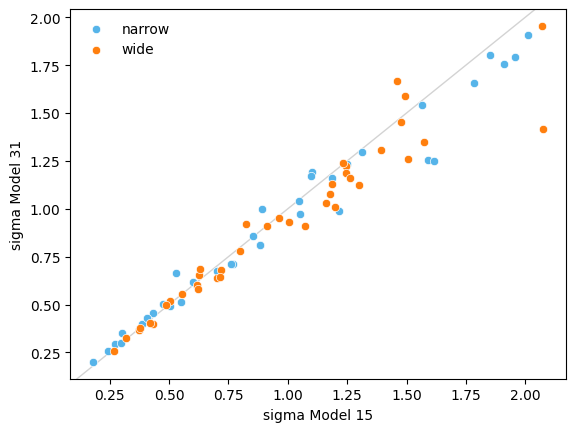

In [54]:
for cond in CONDITIONS:
    xxx = index_filter(fmri_estimates_avgs, subrange='narrowrange', model_label=15, condition=cond, wide=False).sigma
    yyy = index_filter(fmri_estimates_avgs, subrange='narrowrange', model_label=31, condition=cond, wide=False).sigma
    sns.scatterplot(x=xxx, y=yyy, c=COLORS_COND[cond], label=cond,)
axline((1,1), slope=1, color='lightgrey', lw=1, zorder=-1000)
plt.xlabel('sigma Model 15')
plt.ylabel('sigma Model 31')

In [55]:
index_filter(fmri_estimates_stats, wide=True, model_label=31)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject condition n                                                                                            
1       narrow    10.0  10.489996    0.489996  1.024747        0.489996  1.012298  0.489996  0.024446  2.302585
                  11.0  11.101033    0.101033  0.199169        0.160104  0.446283  0.101033 -1.613602  2.397895
                  12.0  12.170335    0.170334  0.335862        0.302554  0.579536  0.170335 -1.091055  2.484907
                  13.0  13.130262    0.130262  0.559787        0.494164  0.748189  0.130262 -0.580198  2.564949
                  14.0  14.257319    0.257318  0.729024        0.629840  0.853829  0.257319 -0.316048  2.639057
...                           ...         ...       ...             ...       ...       ...       ...       ...
41      wide      36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
                  37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
                  38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
                  39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
                  40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[2418 rows x 8 columns]

In [56]:
fmri_ests_avgs_deltas = ( index_filter(fmri_estimates_avgs, condition='wide') - index_filter(fmri_estimates_avgs, condition='narrow') ).add_suffix('_diff')
fmri_ests_avgs_deltas

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff
subrange subject wide  model_label                                                                                                    
all      1       False 15             -0.028896        -0.028896    0.655809             0.254310    0.305466  -0.028896      0.598176
                       18             -0.025758        -0.025758    0.516403             0.172324    0.234637  -0.025758      0.446434
                       31             -0.021607        -0.021607    0.647172             0.253735    0.319018  -0.021607      0.657903
                 True  15             -0.009398        -0.009398    1.475437             0.365632    0.520711  -0.009398      0.772774
                       18             -0.006143        -0.006143    1.267838             0.276767    0.416597  -0.006143      0.573453
...                                         ...              ...         ...                  ...         ...        ...           ...
1337     41      False 18             -0.015743        -0.015743    0.177769             0.228722    0.250979  -0.015743      1.497454
                       31             -0.008392        -0.008393    0.125707             0.165356    0.174288  -0.008392      0.992014
                 True  15             -0.004251        -0.004251    0.123439             0.140378    0.154276  -0.004251      0.812291
                       18             -0.006058        -0.006058    0.139030             0.159708    0.177072  -0.006058      0.960013
                       31             -0.002785        -0.002784    0.102995             0.115733    0.126075  -0.002785      0.644571

[1872 rows x 7 columns]

In [57]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide  condition n                                                                                            
1       15          False narrow    10.0  10.631045    0.631045  1.276577        0.631045  1.129857  0.631045  0.244182  2.302585
                                    11.0  11.175836    0.175836  0.259381        0.219162  0.509295  0.175836 -1.349456  2.397895
                                    12.0  12.060424    0.060424  0.282017        0.273017  0.531053  0.060424 -1.265786  2.484907
                                    13.0  13.059976    0.059976  0.596356        0.474482  0.772241  0.059976 -0.516918  2.564949
                                    14.0  14.295382    0.295382  0.779362        0.649081  0.882815  0.295382 -0.249280  2.639057
...                                             ...         ...       ...             ...       ...       ...       ...       ...
41      31          True  wide      36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
                                    37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
                                    38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
                                    39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
                                    40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[10998 rows x 8 columns]

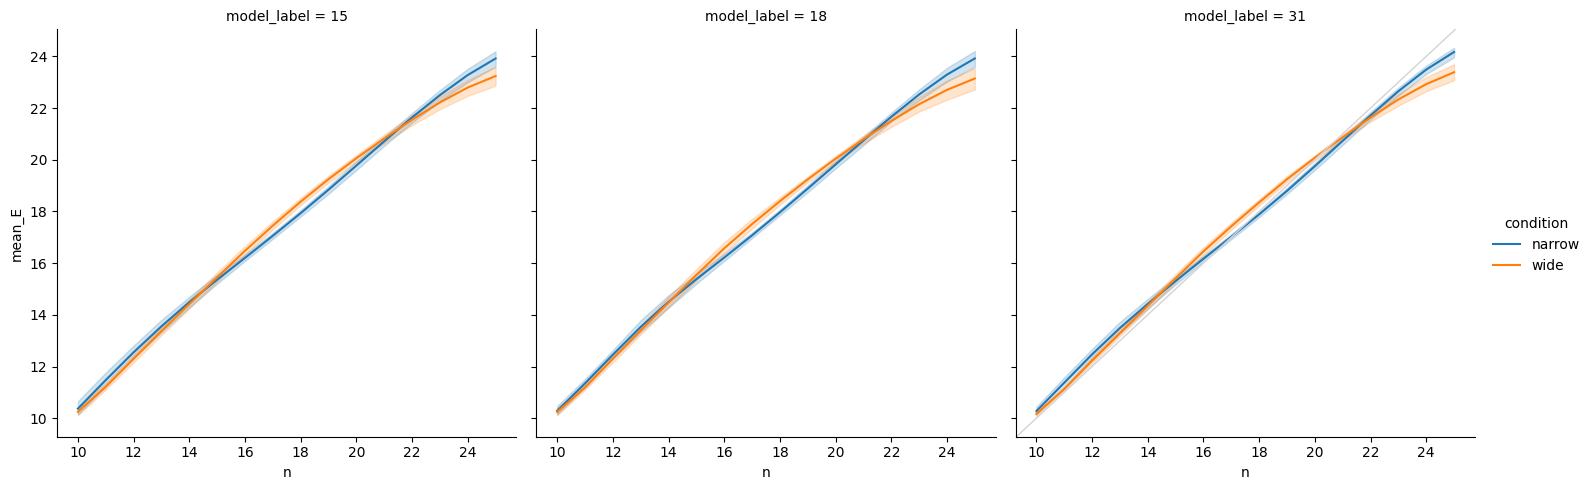

In [58]:
sns.relplot(index_filter(fmri_estimates_stats, wide=False), x='n', y='mean_E', hue='condition', kind='line', col='model_label', ) # , model_label=15
axline((10,10), slope=1, color='lightgrey', lw=1)

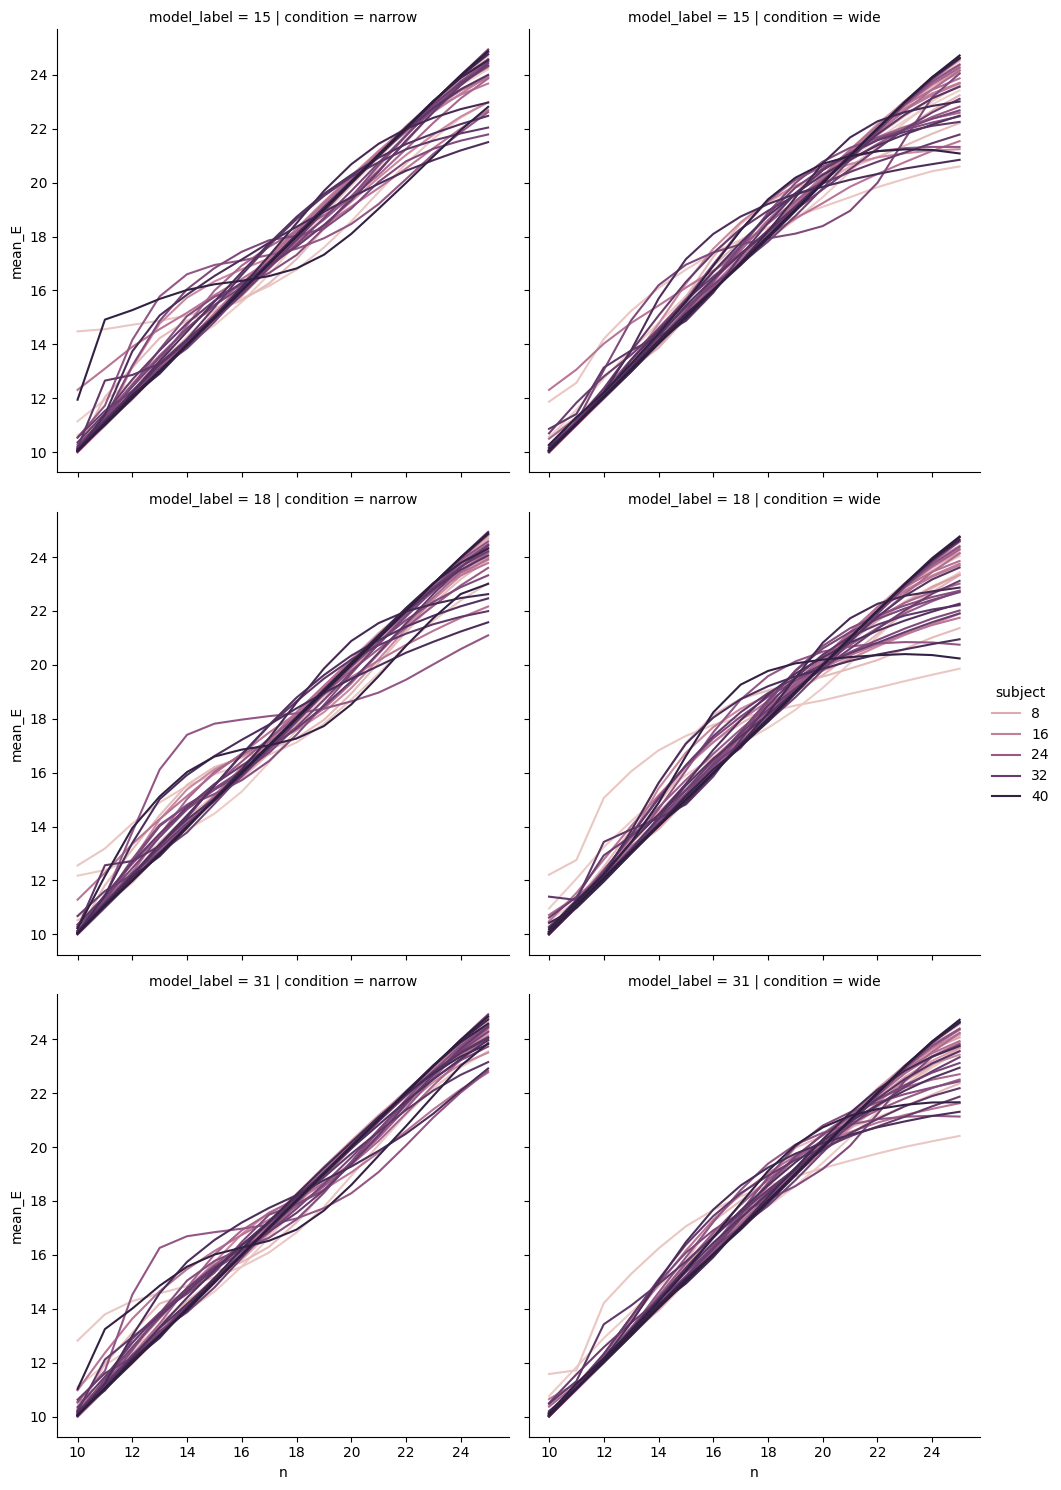

In [59]:
sns.relplot(index_filter(fmri_estimates_stats, wide=False), x='n', y='mean_E', hue='subject', kind='line', col='condition', row='model_label') 

### fMRI - trial responses

In [60]:
fmri_trial_resps = pd.read_csv('decoding/decoding_pars.tsv', delimiter='\t',) # index_col=[0,1,2,3])
fmri_trial_resps = fmri_trial_resps.drop(columns=['session', 'run', 'trial_nr', 'onset', 'phase', 'nr_frames', 'jitter', 'start_marker_position', 'onset_abs', 'duration'])
fmri_trial_resps = fmri_trial_resps.rename(columns={'range':'condition'})
fmri_trial_resps = fmri_trial_resps.set_index(['spherical_noise', 'subject', 'condition'])
fmri_trial_resps['t'] = fmri_trial_resps.groupby(level=['spherical_noise', 'subject', 'condition']).cumcount() + 1
fmri_trial_resps.set_index('t', append=True, inplace=True)
fmri_trial_resps = fmri_trial_resps.sort_index()
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  
spherical_noise subject condition t                                   
False           1       narrow    1              low            high  
                                  2              low             low  
                                  3              low            high  
                                  4              low             low  
                                  5              low             low  
...                                              ...             ...  
True            41      wide      236            low             low  
                                  237           high             low  
                                  238           high             low  
                                  239            low            high  
                                  240           high            high  

[37440 rows x 14 columns]

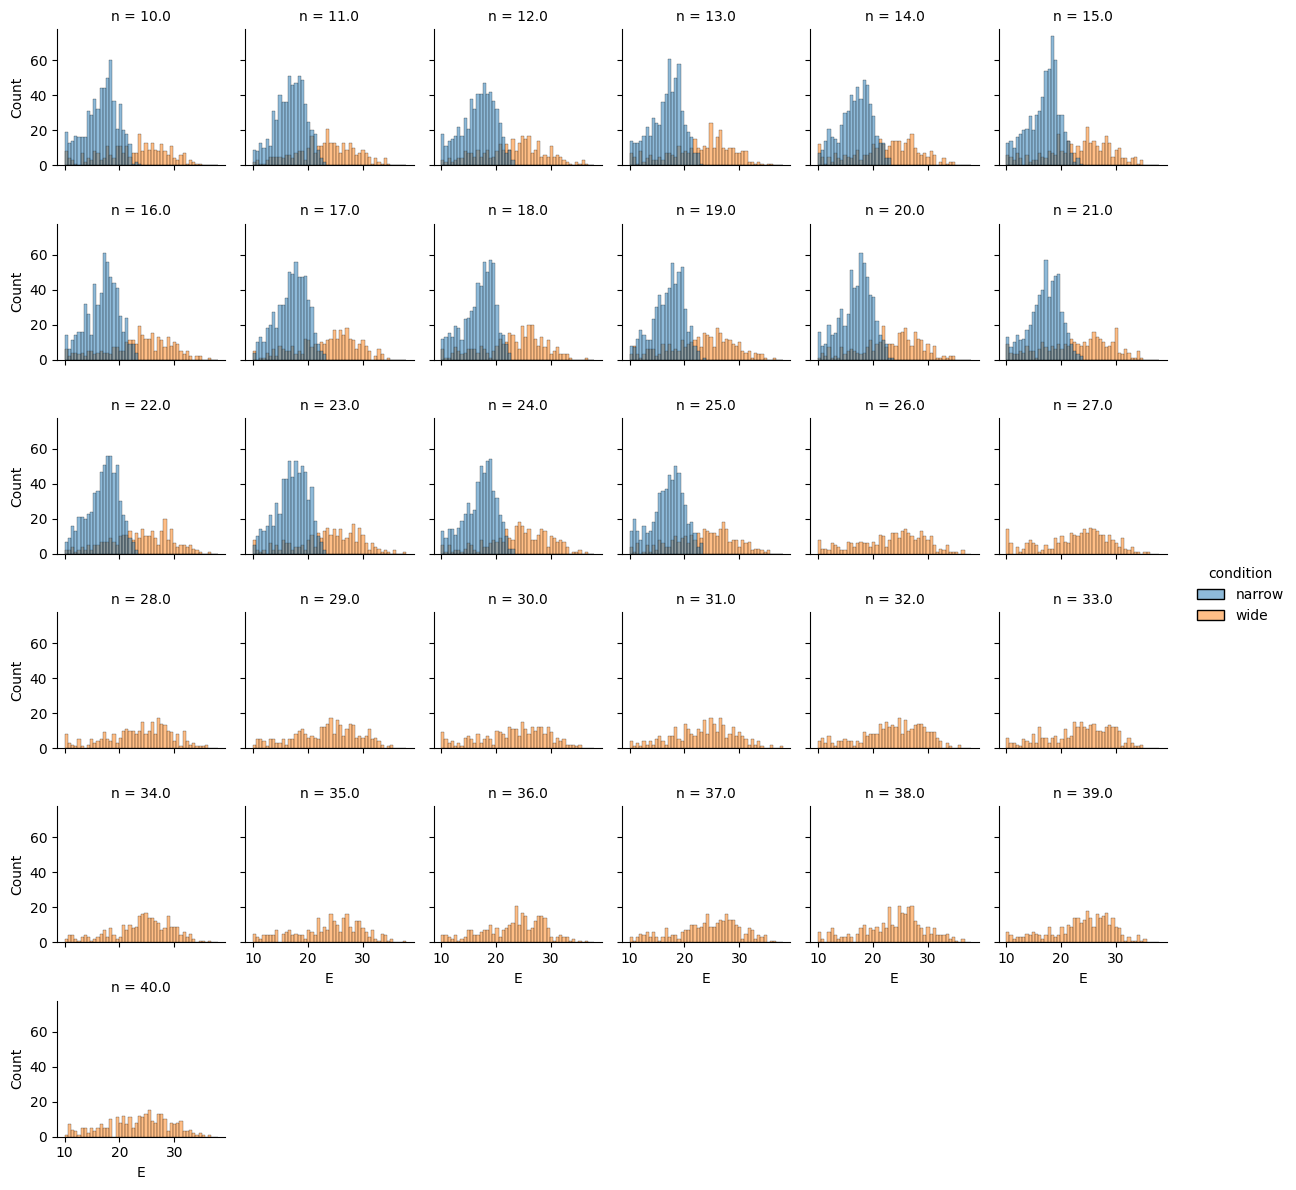

In [60]:
sns.displot(index_filter(fmri_trial_resps, spherical_noise=False), x='E', hue='condition', col='n', col_wrap=6, height=2 )

In [61]:
pg.corr(fmri_trial_resps.response - fmri_trial_resps.n, fmri_trial_resps.E- fmri_trial_resps.n)

,n,r,CI95%,p-val,BF10,power
pearson,36632,0.344781,"[0.34, 0.35]",0.0,inf,1.0


In [62]:
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  
spherical_noise subject condition t                                   
False           1       narrow    1              low            high  
                                  2              low             low  
                                  3              low            high  
                                  4              low             low  
                                  5              low             low  
...                                              ...             ...  
True            41      wide      236            low             low  
                                  237           high             low  
                                  238           high             low  
                                  239            low            high  
                                  240           high            high  

[37440 rows x 14 columns]

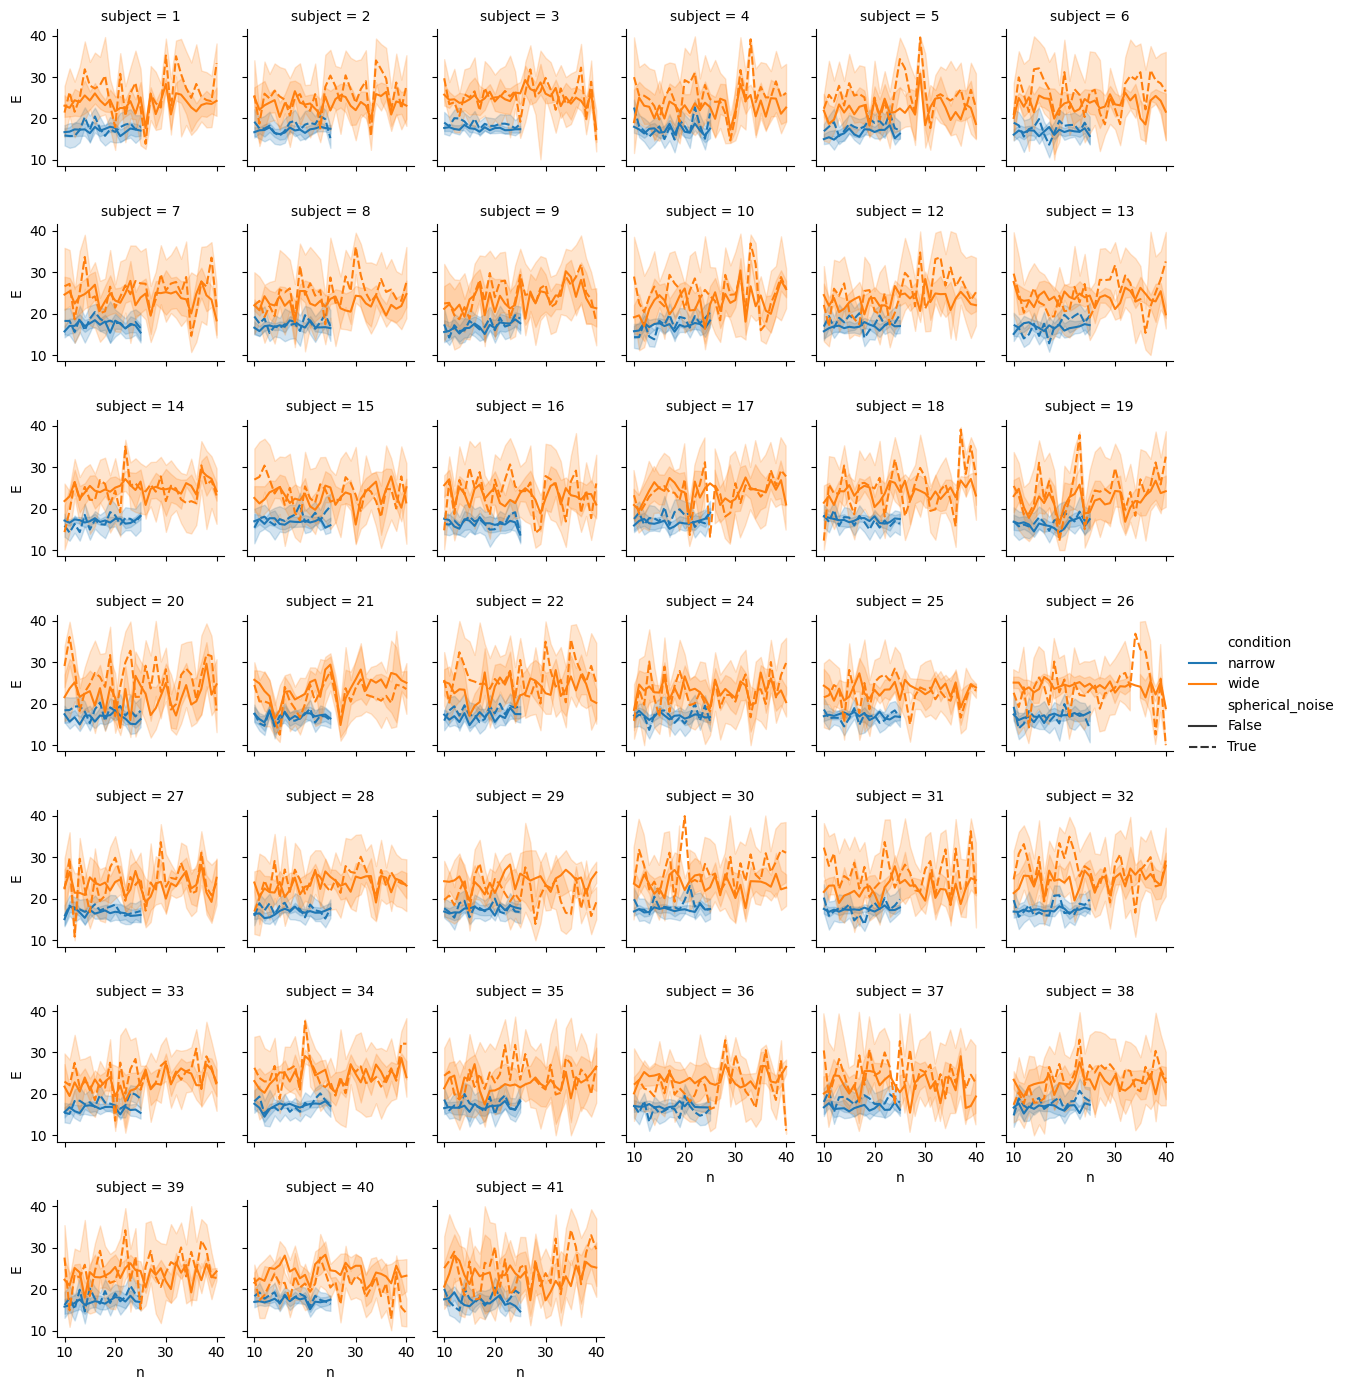

In [63]:
sns.relplot(fmri_trial_resps, x='n', y='E', col='subject', col_wrap=6, hue='condition', kind='line', style='spherical_noise', height=2)

In [64]:
fmri_trial_resps.groupby(['spherical_noise', 'subject', 'condition', 'n']).E.std().groupby(['spherical_noise', 'condition']).describe()

count       mean       std       min       25%        50%        75%        max
spherical_noise condition                                                                                  
False           narrow      624.0   2.751000  0.739734  1.092717  2.183299   2.755838   3.311370   4.562988
                wide       1206.0   5.377288  1.881534  0.177488  3.996001   5.403182   6.627117  11.550149
True            narrow      624.0   5.463510  0.825909  2.180790  4.922319   5.596368   6.088765   7.227569
                wide       1205.0  10.280070  2.648900  0.040281  9.157212  10.745091  12.042573  18.187642

### fMRI - trial posteriors

In [65]:
fmri_trial_pdfs = pd.read_csv('decoding/decoding_pdf.tsv', delimiter='\t', ) #index_col=[0,1,2,3,4,5,])
# fmri_trial_resps = fmri_trial_resps.drop(columns=['session', 'run', 'trial_nr', 'onset', 'phase', 'nr_frames', 'jitter', 'start_marker_position', 'onset_abs', 'duration'])
# fmri_trial_resps = fmri_trial_resps.rename(columns={'range':'condition'})
# fmri_trial_resps = fmri_trial_resps.set_index(['spherical_noise', 'subject', 'condition'])
# fmri_trial_resps['t'] = fmri_trial_resps.groupby(level=['spherical_noise', 'subject', 'condition']).cumcount() + 1
# fmri_trial_resps.set_index('t', append=True, inplace=True)
# fmri_trial_resps = fmri_trial_resps.sort_index()
fmri_trial_pdfs

/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_19714/4047400185.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  fmri_trial_pdfs = pd.read_csv('decoding/decoding_pdf.tsv', delimiter='\t', ) #index_col=[0,1,2,3,4,5,])


,n,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,10.0,10.0.1,11.0,11.0.1,12.0,12.0.1,13.0,13.0.1,14.0,14.0.1,15.0,15.0.1,16.0,16.0.1,17.0,17.0.1,18.0,18.0.1,19.0,19.0.1,20.0,20.0.1,21.0,21.0.1,22.0,22.0.1,23.0,23.0.1,24.0,24.0.1,25.0,25.0.1,26.0,26.0.1,27.0,27.0.1,28.0,28.0.1,29.0,29.0.1,30.0,30.0.1,31.0,31.0.1,32.0,32.0.1,33.0,33.0.1,34.0,34.0.1,35.0,35.0.1,36.0,36.0.1,37.0,37.0.1,38.0,38.0.1,39.0,39.0.1,40.0,40.0.1
0,range,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
1,subject,subject,session,run2,trial_nr,run,x,range,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01,01,1,1,1,1,11.0,0.0,8.613667e-09,1.305750e-07,1.429114e-09,2.465364e-08,9.132926e-10,6.984720e-09,1.443271e-09,3.721917e-09,3.545521e-09,3.352635e-09,1.224174e-08,3.998643e-09,5.551717e-08,5.625584e-09,3.045889e-07,9.044418e-09,1.861738e-06,1.637333e-08,1.176583e-05,3.283066e-08,7.210743e-05,7.157757e-08,4.064149e-04,1.664431e-07,2.019521e-03,4.053290e-07,8.569186e-03,1.016574e-06,3.035631e-02,2.586661e-06,8.854943e-02,6.590169e-06,2.113650e-01,1.662339e-05,4.129873e-01,4.111191e-05,6.642354e-01,9.887247e-05,8.881707e-01,2.296540e-04,1.000000e+00,5.123162e-04,9.623071e-01,1.092746e-03,8.042585e-01,2.220719e-03,5.934576e-01,4.289047e-03,3.929104e-01,7.858250e-03,2.370574e-01,1.364430e-02,1.322648e-01,2.244010e-02,6.916470e-02,3.496443e-02,3.431537e-02,5.163939e-02,1.633058e-02,7.236905e-02,7.526593e-03,9.635738e-02
3,01,01,1,1,2,1,23.0,0.0,1.158690e-13,4.995173e-13,3.836964e-14,2.743317e-13,2.956573e-14,1.531646e-13,4.397758e-14,1.143061e-13,1.153293e-13,1.137147e-13,5.673588e-13,1.338782e-13,4.626253e-12,1.915378e-13,5.347730e-11,3.467983e-13,7.688816e-10,7.872671e-13,1.231143e-08,2.161543e-12,1.991638e-07,6.903414e-12,2.985235e-06,2.478515e-11,3.845055e-05,9.718125e-11,3.994552e-04,4.059024e-10,3.182975e-03,1.766768e-09,1.875456e-02,7.856967e-09,7.986602e-02,3.507092e-08,2.434876e-01,1.546269e-07,5.327192e-01,6.637825e-07,8.472269e-01,2.739071e-06,1.000000e+00,1.074368e-05,8.996006e-01,3.966383e-05,6.357357e-01,1.366940e-04,3.643044e-01,4.366987e-04,1.747418e-01,1.286038e-03,7.232379e-02,3.476558e-03,2.657276e-02,8.599837e-03,8.892072e-03,1.942800e-02,2.772261e-03,4.004962e-02,8.214319e-04,7.534152e-02,2.352867e-04,1.294673e-01
4,01,01,1,1,3,1,23.0,0.0,1.675825e-35,2.968929e-34,3.463434e-36,6.401781e-35,2.571608e-36,2.282138e-35,5.095557e-36,1.439590e-35,2.111341e-35,1.487283e-35,1.683662e-34,2.175506e-35,2.302058e-33,4.254626e-35,4.838025e-32,1.083576e-34,1.429366e-30,3.480895e-34,5.506795e-29,1.363134e-33,2.592412e-27,6.310381e-33,1.408042e-25,3.364934e-32,8.380592e-24,2.021527e-31,5.218224e-22,1.342274e-30,3.258491e-20,9.687790e-30,1.963077e-18,7.487948e-29,1.101347e-16,6.116502e-28,5.571279e-15,5.218310e-27,2.467551e-13,4.600071e-26,9.321506e-12,4.150101e-25,2.934734e-10,3.798468e-24,7.550323e-09,3.498981e-23,1.562063e-07,3.220451e-22,2.566570e-06,2.941925e-21,3.320263e-05,2.651156e-20,3.365804e-04,2.343775e-19,2.670373e-03,2.021995e-18,1.662018e-02,1.69

### fMRI-Stan

In [66]:
#stan_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804221241.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10
#stan_fmri = pd.read_csv('stan/outputs/summaries_fmri_30/results_20250804230132.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
stan_fmri_notspherical = pd.read_csv('stan/outputs/summaries_fmri_notspherical_30/results_20250805175119.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
stan_fmri_spherical = pd.read_csv('stan/outputs/summaries_fmri_spherical_30/results_20250805174026.csv', index_col=0) # prior on m_0 -> 30, prior on sigma_0 -> 10, prior tau, nu
stan_fmri_spherical

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-49162.500000,1.002330,46.994700,-49238.200000,-49163.200000,-49083.200000,2198.24,3.38221,1.005900
z_m_0_15[1],0.253463,0.000064,0.007964,0.240409,0.253435,0.266644,15700.90,24.15730,0.999709
z_m_0_15[2],0.204598,0.000063,0.007897,0.191687,0.204644,0.217618,15897.90,24.46040,1.000040
z_m_0_15[3],0.164896,0.000062,0.007952,0.151954,0.164928,0.177829,16401.20,25.23480,0.999713
z_m_0_15[4],0.130767,0.000064,0.007845,0.117550,0.130869,0.143387,15262.30,23.48250,1.000130
...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],1.303230,0.000255,0.032562,1.250050,1.303000,1.357030,16256.70,25.01240,0.999571
delta_avg_log_var_s_1322[36],1.302900,0.000260,0.032916,1.249120,1.302980,1.357430,16031.00,24.66530,0.999622
delta_avg_log_var_s_1322[37],1.303230,0.000259,0.032575,1.249660,1.303060,1.357020,15768.70,24.26170,0.999535
delta_avg_log_var_s_1322[38],1.303470,0.000262,0.032750,1.249810,1.302970,1.358280,15655.30,24.08720,0.999591


In [67]:
das = []
quantities = ['m_s', 'sigma_s', 'var_s', 'inv_sigma_s', 'log_var_s', ]
for qty in quantities:
    da = []
    for cond in CONDITIONS:
        cond_k = {NARROW: 15, WIDE: 30}[cond]
        for subject in range(1, 40):
            nmax = {NARROW: 17, WIDE: 32}[cond]
            for n in range(1, nmax):
                v = stan_fmri_spherical.loc[f'{qty}_{cond_k}[{subject},{n}]', 'Mean']
                da.append([subj_i_to_subj[subject], cond, n+9., True, v])
                v = stan_fmri_notspherical.loc[f'{qty}_{cond_k}[{subject},{n}]', 'Mean']
                da.append([subj_i_to_subj[subject], cond, n+9., False, v])
    da = pd.DataFrame(da, columns=['subject', 'condition', 'n', 'is_spherical', qty[:-2]]).set_index(['subject', 'condition', 'n', 'is_spherical'])
    das.append(da)
stan_fmri_subj_n = pd.concat(das, axis=1)
stan_fmri_subj_n['bias'] = stan_fmri_subj_n['m'] - stan_fmri_subj_n.index.get_level_values('n')
stan_fmri_subj_n['log_n'] = np.log(stan_fmri_subj_n.index.get_level_values('n'))
stan_fmri_subj_n

m     sigma        var  inv_sigma  log_var     bias     log_n
subject condition n    is_spherical                                                                     
1       narrow    10.0 True          17.4936   5.63029   31.72990   0.177777  3.45538   7.4936  2.302585
                       False         16.7592   2.51876    6.45596   0.403943  1.83018   6.7592  2.302585
                  11.0 True          17.0705   5.61109   31.51300   0.178381  3.44858   6.0705  2.397895
                       False         16.9291   2.41496    5.95679   0.422828  1.74238   5.9291  2.397895
                  12.0 True          16.8883   5.56703   31.02040   0.179795  3.43280   4.8883  2.484907
...                                      ...       ...        ...        ...      ...      ...       ...
41      wide      38.0 False         23.9553   6.32056   40.77050   0.161395  3.66757 -14.0447  3.637586
                  39.0 True          25.7054  11.00360  121.28300   0.091032  4.79476 -13.2946  3.663562
                       False         23.9600   6.12961   38.31490   0.166306  3.60693 -15.0400  3.663562
                  40.0 True          24.4963  11.05180  122.36900   0.090651  4.80333 -15.5037  3.688879
                       False         23.3781   7.07131   51.00120   0.144177  3.89263 -16.6219  3.688879

[3666 rows x 7 columns]

In [68]:
index_filter(stan_fmri_subj_n, condition=NARROW, n=10, is_spherical=True)

,m,sigma,var,inv_sigma,log_var,bias,log_n
subject,,,,,,,
1,17.4936,5.63029,31.7299,0.177777,3.45538,7.4936,2.302585
2,17.6701,5.63019,31.7291,0.177782,3.45534,7.6701,2.302585
3,17.6758,5.62926,31.7182,0.177810,3.45502,7.6758,2.302585
4,17.8188,5.63054,31.7330,0.177770,3.45547,7.8188,2.302585
5,17.5449,5.62731,31.6967,0.177874,3.45431,7.5449,2.302585
6,17.6756,5.63147,31.7433,0.177741,3.45580,7.6756,2.302585
7,17.6370,5.63043,31.7317,0.177773,3.45543,7.6370,2.302585
8,17.6578,5.63026,31.7299,0.177780,3.45537,7.6578,2.302585
9,17.5964,5.62970,31.7239,0.177799,3.45516,7.5964,2.302585


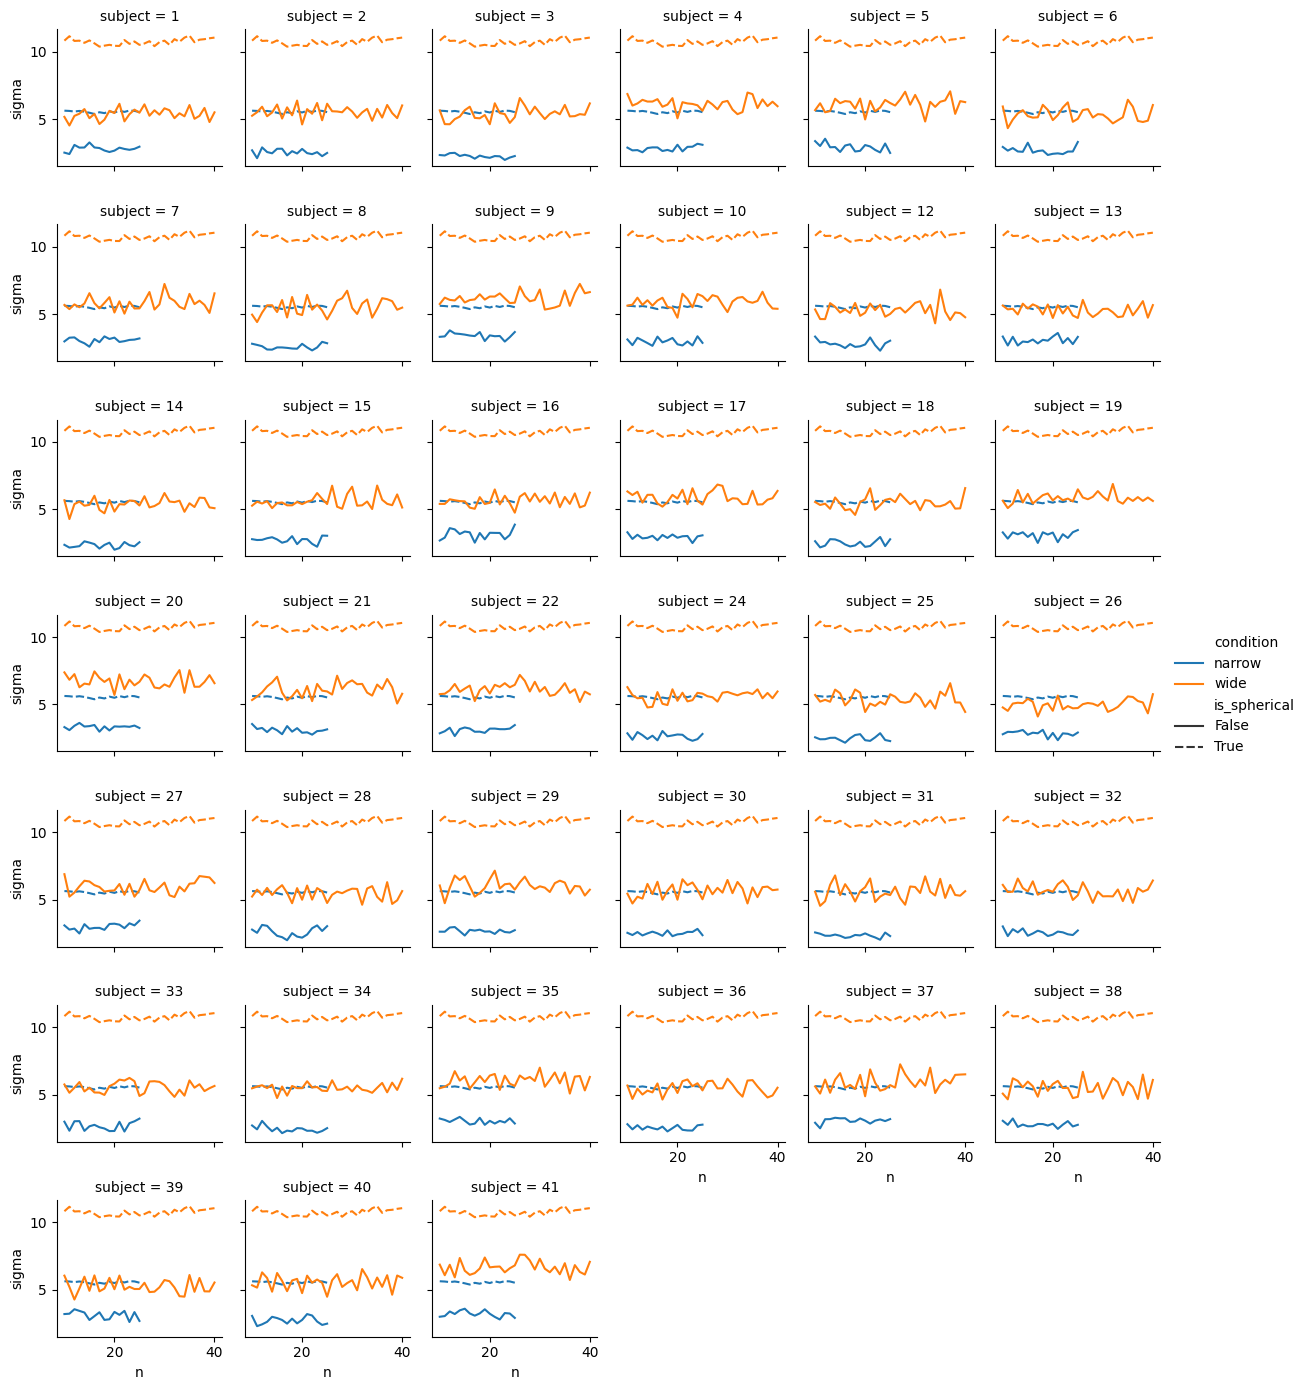

In [69]:
sns.relplot(stan_fmri_subj_n, x='n', y='sigma', hue='condition', kind='line', col='subject', col_wrap=6, height=2, style='is_spherical')

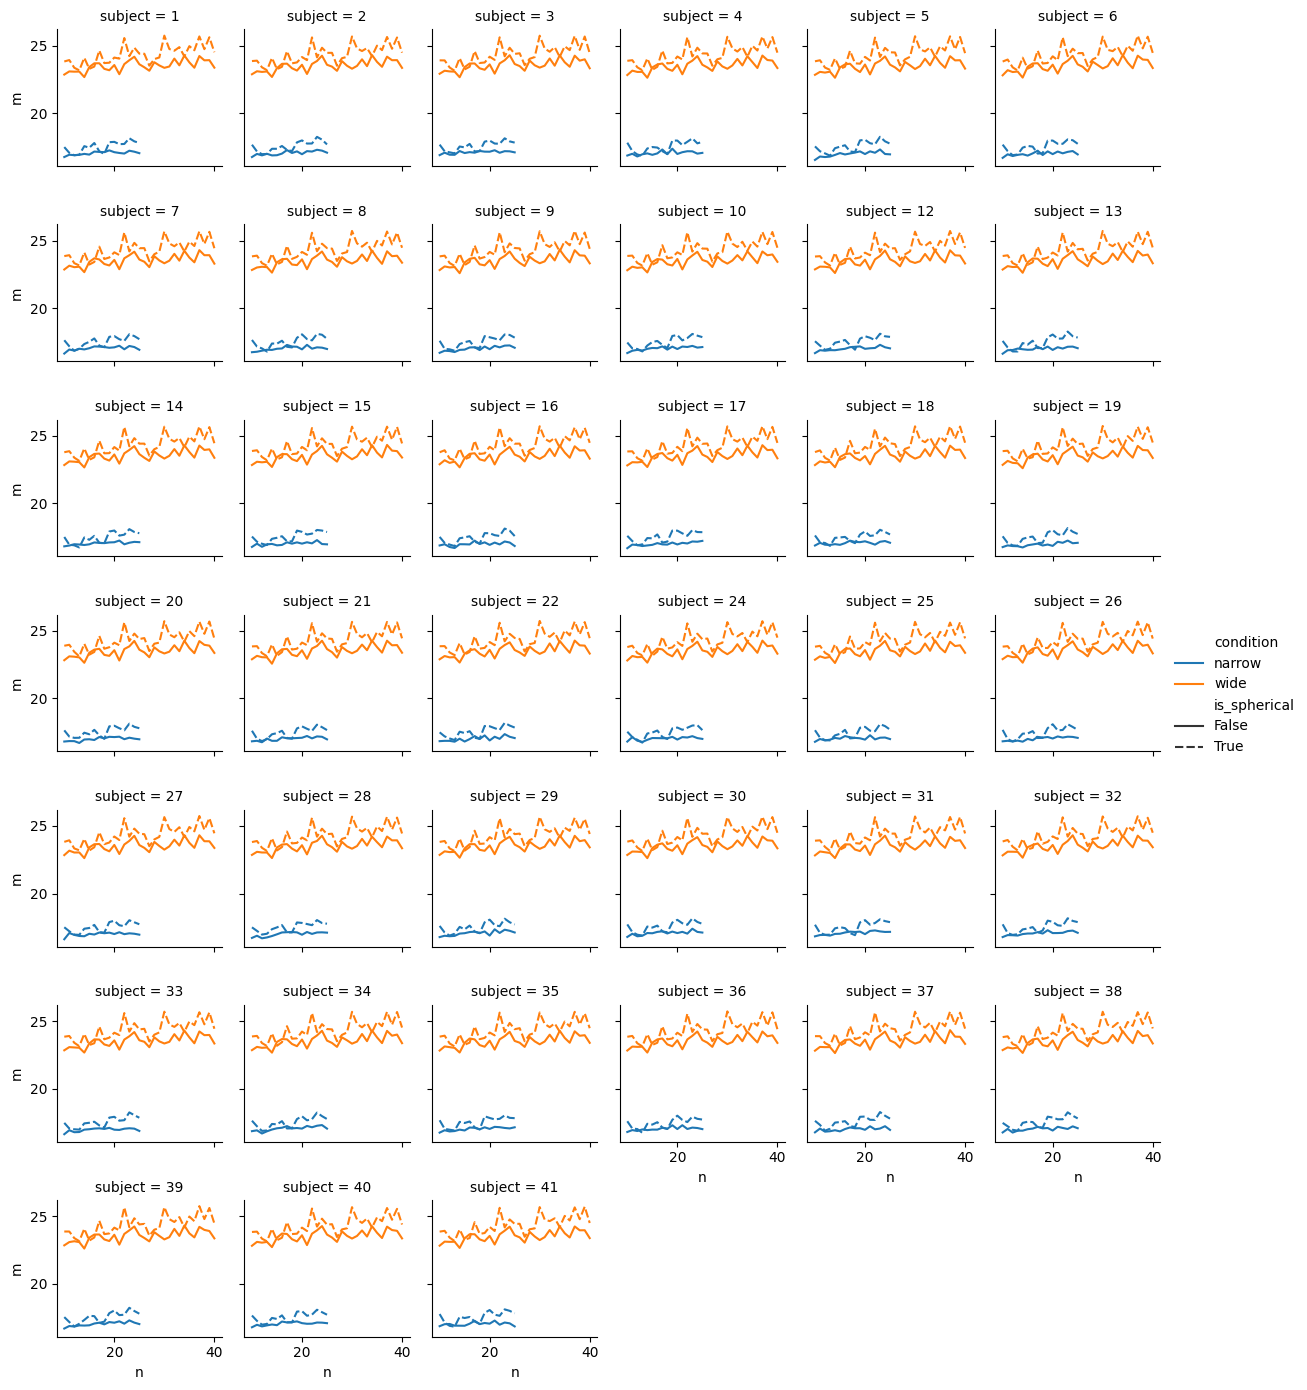

In [70]:
sns.relplot(stan_fmri_subj_n, x='n', y='m', hue='condition', kind='line', col='subject', col_wrap=6, height=2, style='is_spherical')

# fMRI across conditions

## Fisher info

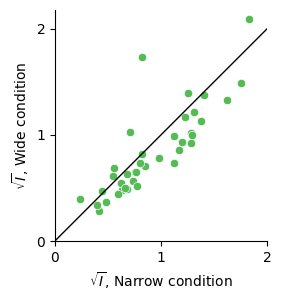

In [71]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
#ax.set_xscale('log'); ax.set_yscale('log')
model_label = 31
subrange = 'narrowrange' # '1124'
qty = 'sqrt_fi'
label = '$\sqrt{I}$' # '$\langle \sqrt{I(x)}\\rangle$'
sns.scatterplot( x=index_filter(fisher_info_avgs, subrange=subrange, condition=NARROW, model_label=model_label)[qty].rename(f'{label}, {NARROW.capitalize()} condition'), # model_label=15,
             y=index_filter(fisher_info_avgs, subrange=subrange, condition=WIDE, model_label=model_label)[qty].rename(f'{label}, {WIDE.capitalize()} condition'), # model_label=15, 
            ax=ax, color=THIRD_COLOR)
ax.axline((1,1), slope=1, color='k', linestyle='-', lw=1)
#ax.set_xlim(0,2.25)
#ax.set_ylim(ax.get_xlim())
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(f'figures/{qty}_w_vs_n.pdf', bbox_inches='tight')

In [72]:
fisher_info_avgs.columns

Index(['fi', 'log_fi', 'sqrt_fi', 'inv_fi', 'inv_sqrt_fi'], dtype='object')

Paired t-test: t = -6.529, p = 5.37e-08, dof = 38


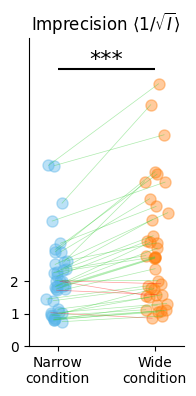

In [73]:
fig, ax = plt.subplots(figsize=(2, 4))
model_label = 31
subrange = 'narrowrange' # '1124'
qty = 'inv_sqrt_fi'
xx1 = index_filter(fisher_info_avgs, subrange=subrange, condition=NARROW, model_label=model_label)[qty].rename(NARROW)
xx2 = index_filter(fisher_info_avgs, subrange=subrange, condition=WIDE, model_label=model_label)[qty].rename(WIDE)
paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2,
                 color_decr_line='red', color_incr_line='limegreen', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE])
ax.set_xlim(0.7, 2.3)
ax.set_ylim((0,9.5) if qty == 'inv_sqrt_fi' else (-3.75, 1.7) if qty == 'log_fi' else (0,2.49) if qty == 'sqrt_fi' else None)
ax.set_xticks([1, 2])
ax.set_yticks([0,1,2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title('Imprecision $\\langle 1/\sqrt{I} \\rangle$' if qty == 'inv_sqrt_fi' else "Log-Fisher information" if qty == 'log_fi' else
             #'fMRI-derived average $\sqrt{I}$' if qty == 'sqrt_fi' else qty
             'fMRI-derived $\sqrt{I}$' if qty == 'sqrt_fi' else qty
             )
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less' if qty in ['inv_sqrt_fi',] else 'greater')
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(ax.get_ylim()[0] + 0.9*(ax.get_ylim()[1]-ax.get_ylim()[0]), 1, 2, color='k', lw=1.5)
if (pv := paired_test['p-val'].iloc[0]) < 0.05:
    ax.text(1.5, ax.get_ylim()[0] + 0.93*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')

#fig.savefig(f'figures/delta_{qty}.pdf', bbox_inches='tight')

count    39.000000
mean     -0.088071
std       0.231144
min      -0.394936
25%      -0.252481
50%      -0.136482
75%      -0.034746
max       0.910485
Name: sqrt_fi_delta_wn, dtype: float64

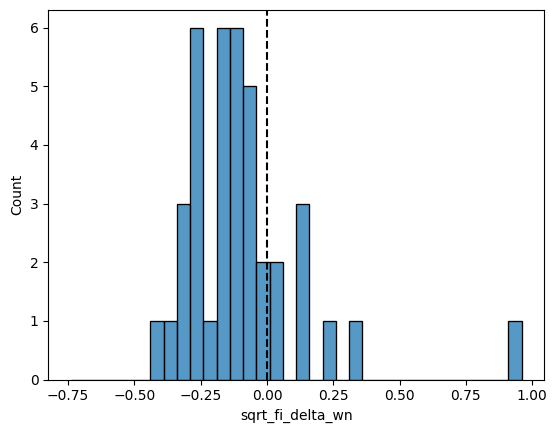

In [74]:
subrange = 'narrowrange'
model_label = 31
sns.histplot( index_filter(fisher_info_avgs_deltas, subrange=subrange, model_label=model_label).sqrt_fi_delta_wn, bins=np.arange(-.74, 1.,.05), ) # model_label=15,
axvline(0, color='k', linestyle='--')
index_filter(fisher_info_avgs_deltas, subrange=subrange, model_label=model_label).sqrt_fi_delta_wn.describe()

## Decoding

In [75]:
fmri_estimates_avgs

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var
subrange subject wide  condition model_label                                                                               
all      1       False narrow    15           17.496742   -0.003258  0.809486        0.639884  0.881334 -0.003258 -0.302409
                                 18           17.490109   -0.009891  0.918530        0.715775  0.941218 -0.009891 -0.165377
                                 31           17.489696   -0.010304  0.684116        0.579671  0.812900 -0.010304 -0.455493
                       wide      15           17.467846   -0.032154  1.465295        0.894194  1.186800 -0.032154  0.295767
                                 18           17.464351   -0.035649  1.434932        0.888099  1.175855 -0.035649  0.281057
...                                                 ...         ...       ...             ...       ...       ...       ...
1337     41      True  narrow    18           25.015866    0.015866  0.155676        0.208866  0.362512  0.015866 -2.205569
                                 31           25.017403    0.017403  0.181284        0.242189  0.401237  0.017403 -1.946800
                       wide      15           25.012638    0.012638  0.287656        0.362171  0.532198  0.012638 -1.276601
                                 18           25.009807    0.009808  0.294706        0.368574  0.539584  0.009807 -1.245556
                                 31           25.014618    0.014618  0.284279        0.357922  0.527312  0.014618 -1.302229

[3744 rows x 7 columns]

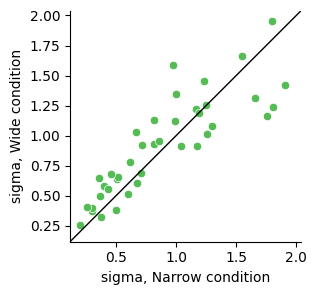

In [76]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
#ax.set_xscale('log'); ax.set_yscale('log')
model_label = 31
subrange = 'narrowrange' # '1124'
wide_prior = False
qty = 'sigma'
label = qty #'var_E' # '$\langle \sqrt{I(x)}\\rangle$'
sns.scatterplot( x=index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=NARROW, wide=wide_prior)[qty].rename(f'{label}, {NARROW.capitalize()} condition'), # model_label=15,
             y=index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=WIDE, wide=wide_prior)[qty].rename(f'{label}, {WIDE.capitalize()} condition'),
            ax=ax, color=THIRD_COLOR)
ax.axline((1,1), slope=1, color='k', linestyle='-', lw=1)
xmin, xmax = (lambda x: (min(x[0]), max(x[1])))(list(zip( ax.get_xlim(), ax.get_ylim() )))
ax.set_xlim(xmin, xmax)
ax.set_ylim(xmin, xmax)
#ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#fig.savefig('figures/sqrt_I_w_vs_n.pdf', bbox_inches='tight')

In [77]:
fmri_estimates_avgs.columns

Index(['mean_E', 'mean_error', 'var_E', 'mean_abs_error', 'sigma', 'bias', 'log_var'], dtype='object')

Paired t-test: t = -1.746, p = 0.0445, dof = 38


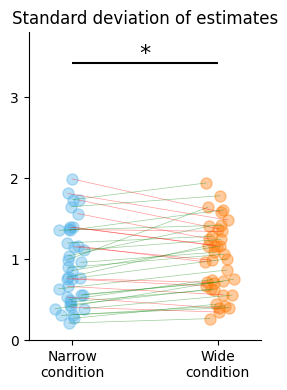

In [78]:
fig, ax = plt.subplots(figsize=(3, 4))
model_label = 31
subrange = '1223' #'all' # 'narrowrange' # '1124'
wide_prior = False
qty = 'sigma'
xx1 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=NARROW, wide=wide_prior)[qty].rename(NARROW)
xx2 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=WIDE, wide=wide_prior)[qty].rename(WIDE)
paired_strip_plot(gca(), x1=1, x2=2, y1=xx1, y2=xx2,
                 color_decr_line='red', color_incr_line='g', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE],)
ax.set_xlim(0.7, 2.3)
ax.set_ylim(0,3.8)
ax.set_yticks([0,1,2,3])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Standard deviation of estimates' if qty == 'sigma' else qty)

# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less')
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(ax.get_ylim()[0] + 0.9*(ax.get_ylim()[1]-ax.get_ylim()[0]), 1, 2, color='k', lw=1.5)
if (pv := paired_test['p-val'].iloc[0]) < 0.05:
    ax.text(1.5, ax.get_ylim()[0] + 0.93*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')

#fig.savefig(f'figures/delta_{qty}.pdf', bbox_inches='tight')

count    39.000000
mean      0.425625
std       0.347166
min      -0.097495
25%       0.143021
50%       0.301146
75%       0.620931
max       1.292141
Name: sigma_diff, dtype: float64

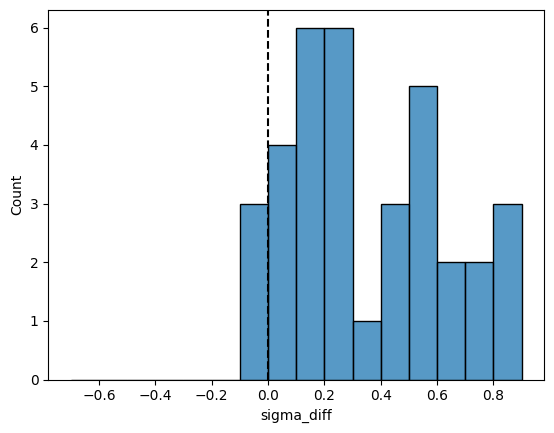

In [79]:
subrange = 'narrowrange'
model_label = 31
wide_prior = True
qty = 'sigma_diff'
sns.histplot( index_filter(fmri_ests_avgs_deltas, subrange=subrange, model_label=model_label, wide=wide_prior)[qty], bins=np.arange(-.7, 1.,.1), ) # model_label=15,
axvline(0, color='k', linestyle='--')
index_filter(fmri_ests_avgs_deltas, subrange=subrange, model_label=model_label, wide=wide_prior)[qty].describe()

# fMRI across x

## Fisher info

In [80]:
fisher_info['one_over_n'] = 1./fisher_info.index.get_level_values('n')
fisher_info

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n  one_over_n
subject model_label n    condition                                                                           
1       31          10.0 narrow     6.035191  1.797608  2.456663  0.165695     0.407056  2.302585    0.100000
                    11.0 narrow     3.724520  1.314938  1.929902  0.268491     0.518161  2.397895    0.090909
                    12.0 narrow     1.117674  0.111250  1.057201  0.894715     0.945894  2.484907    0.083333
                    13.0 narrow     1.006050  0.006032  1.003020  0.993986     0.996989  2.564949    0.076923
                    14.0 narrow     0.460209 -0.776076  0.678387  2.172928     1.474085  2.639057    0.071429
...                                      ...       ...       ...       ...          ...       ...         ...
41      18          36.0 wide       0.278386 -1.278748  0.527623  3.592138     1.895294  3.583519    0.027778
                    37.0 wide       0.260428 -1.345428  0.510322  3.839830     1.959548  3.610918    0.027027
                    38.0 wide       0.243548 -1.412443  0.493505  4.105973     2.026320  3.637586    0.026316
                    39.0 wide       0.227707 -1.479694  0.477187  4.391601     2.095615  3.663562    0.025641
                    40.0 wide       0.212865 -1.547096  0.461373  4.697809     2.167443  3.688879    0.025000

[6084 rows x 7 columns]

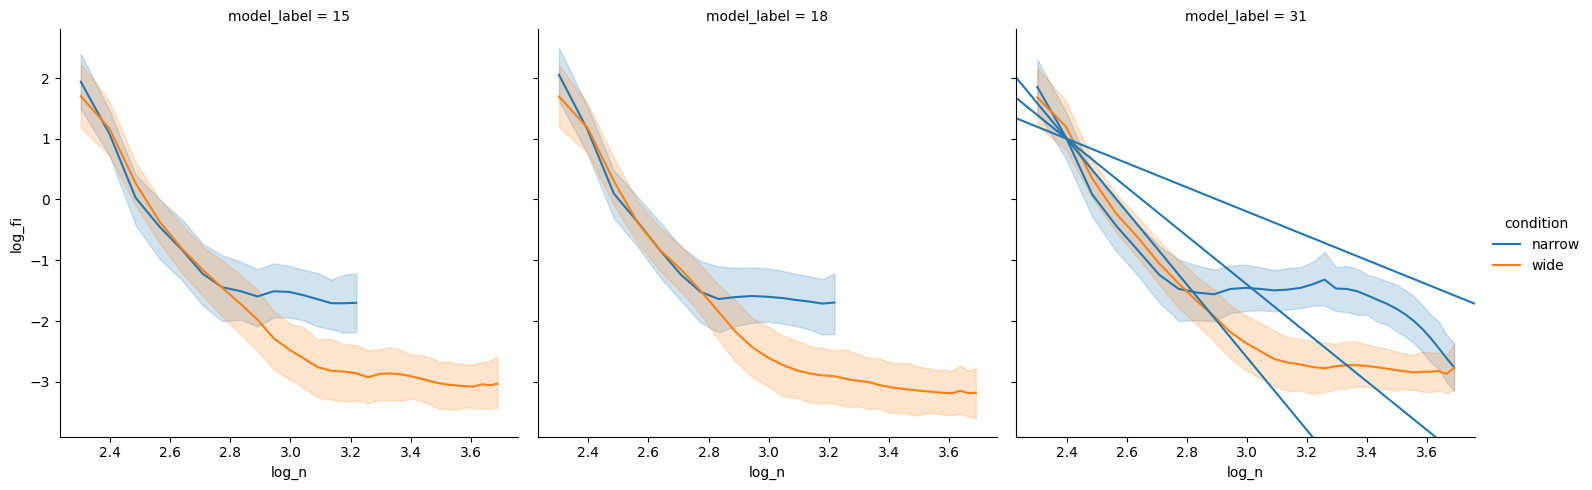

In [81]:
sns.relplot( fisher_info, x='log_n', y='log_fi', hue='condition', kind='line', col='model_label') # index_filter(fisher_info, model_label=15)
gca().axline((2.4, 1), slope=-2)
gca().axline((2.4, 1), slope=-4)
gca().axline((2.4, 1), slope=-6)

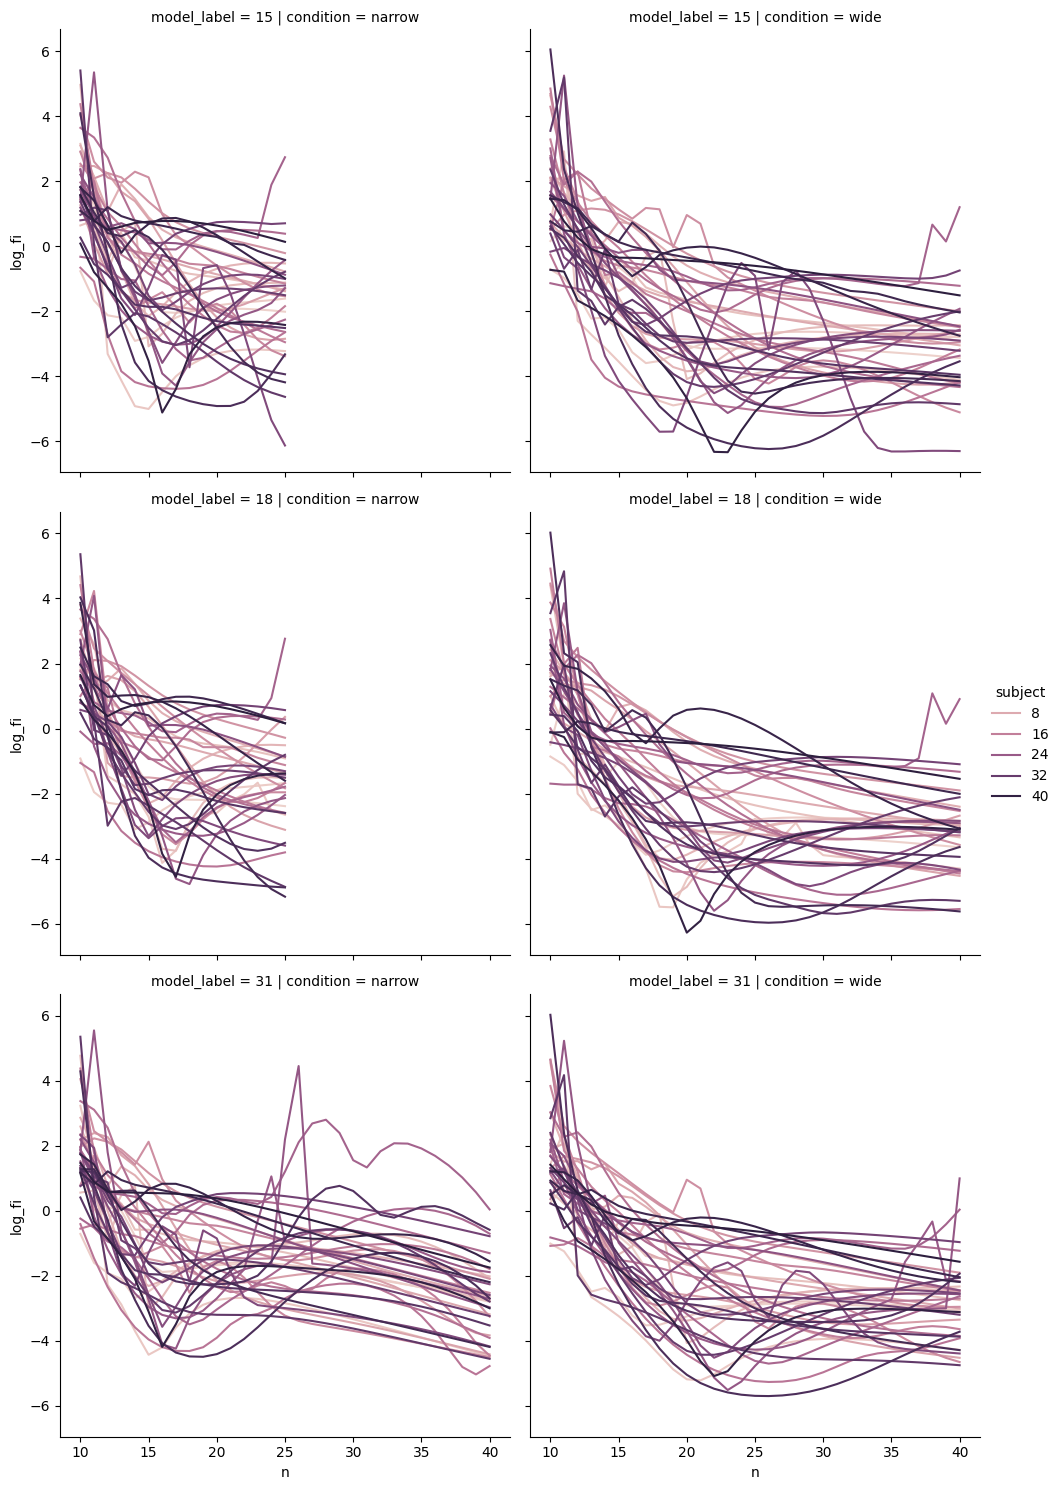

In [82]:
sns.relplot( index_filter(fisher_info), x='n', y='log_fi', hue='subject', kind='line', col='condition', row='model_label') # model_label=15

## Decoding

In [83]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide  condition n                                                                                            
1       15          False narrow    10.0  10.631045    0.631045  1.276577        0.631045  1.129857  0.631045  0.244182  2.302585
                                    11.0  11.175836    0.175836  0.259381        0.219162  0.509295  0.175836 -1.349456  2.397895
                                    12.0  12.060424    0.060424  0.282017        0.273017  0.531053  0.060424 -1.265786  2.484907
                                    13.0  13.059976    0.059976  0.596356        0.474482  0.772241  0.059976 -0.516918  2.564949
                                    14.0  14.295382    0.295382  0.779362        0.649081  0.882815  0.295382 -0.249280  2.639057
...                                             ...         ...       ...             ...       ...       ...       ...       ...
41      31          True  wide      36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
                                    37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
                                    38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
                                    39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
                                    40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[10998 rows x 8 columns]

In [84]:
index_filter(fmri_estimates_stats, model_label=31, condition=cond, n=range(10,MAX_COND[cond]+1))

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject wide  n                                                                                            
1       False 10.0  10.391723    0.391723  1.571768        0.391723  1.253702  0.391723  0.452201  2.302585
              11.0  11.181816    0.181816  0.483202        0.203015  0.695128  0.181816 -0.727319  2.397895
              12.0  12.259137    0.259137  0.585010        0.375990  0.764859  0.259137 -0.536127  2.484907
              13.0  13.351614    0.351614  0.583535        0.528030  0.763895  0.351614 -0.538651  2.564949
              14.0  14.123784    0.123784  0.792251        0.579726  0.890085  0.123784 -0.232877  2.639057
...                       ...         ...       ...             ...       ...       ...       ...       ...
41      True  36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
              37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
              38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
              39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
              40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[1833 rows x 8 columns]

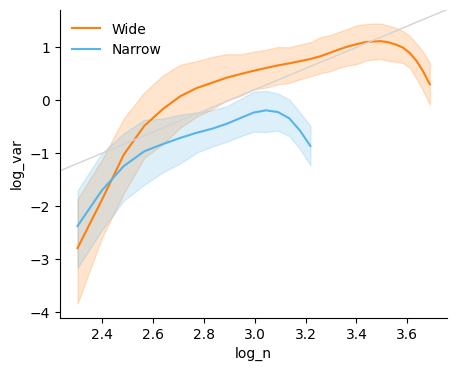

In [85]:
#sns.relplot(index_filter(fmri_estimates_stats, model_label=31), x='n', y='sigma', hue='condition', kind='line',) #  model_label=15
fig, ax = plt.subplots(figsize=(5, 4))
for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, condition=cond, n=range(10,MAX_COND[cond]+1), wide=cond==WIDE),
                 x='log_n', y='log_var', label=cond.capitalize(), color=COLORS_COND[cond], ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axline((2.4, -1), slope=2, color='lightgrey', lw=1, )
# ax.set_xlim(10, 40)
# ax.set_ylim(0, 2.5)
# ax.set_xlabel('Number')
# ax.set_ylabel(None)
# ax.set_title('Standard deviation of fMRI-derived estimates')

In [86]:
COLORS_COND[NARROW]
"#78BEE7"

'#78BEE7'

Text(0.5, 1.0, 'Standard deviation of fMRI-derived estimates')

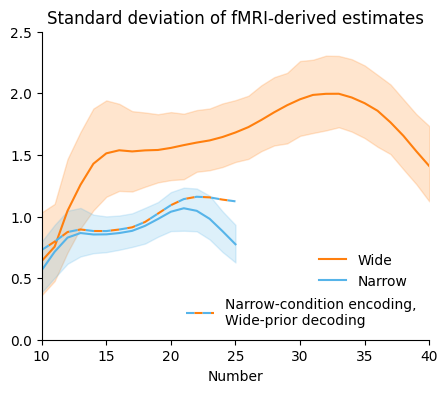

In [87]:
#sns.relplot(index_filter(fmri_estimates_stats, model_label=31), x='n', y='sigma', hue='condition', kind='line',) #  model_label=15
fig, ax = plt.subplots(figsize=(5, 4))
for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide=cond==WIDE, condition=cond, n=range(10, 41)), x='n', y='sigma', label=cond.capitalize(), color=COLORS_COND[cond], ax=ax)
    #sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=cond!=WIDE, condition=cond, n=range(10,41)), x='n', y='sigma', label=cond.capitalize(), color=COLORS_COND[cond], ax=ax, ls=':')
#sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=False, condition=WIDE, n=range(10,41)), x='n', y='sigma', label=WIDE.capitalize(), color=COLORS_COND[WIDE], ax=ax, ls=':')
sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide=True, condition=NARROW, n=range(10,26)), x='n', y='sigma',
             label='Narrow-condition encoding,\nWide-prior decoding', 
             color=COLORS_COND[NARROW], errorbar=None, ax=ax, dashes=[4, 4], gapcolor=COLORS_COND[WIDE])
# sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide_prior=True, condition=NARROW, n=range(10,26)), x='n', y='sigma',
#              color=COLORS_COND[WIDE], errorbar=None, ax=ax, ls=':')
leg_hands = list(zip( *ax.get_legend_handles_labels() ))
leg1 = ax.legend( *zip( *leg_hands[:2] ), loc=(.7, .15) )
leg2 = ax.legend( *zip( *leg_hands[2:] ), loc='lower right' )
ax.add_artist(leg1) 
#ax.add_artist(leg2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(10, 40)
ax.set_ylim(0, 2.5)
ax.set_xlabel('Number')
ax.set_ylabel(None)
ax.set_title('Standard deviation of fMRI-derived estimates')

In [88]:
leg2.get_texts()

<a list of 1 Text objects>

In [89]:
list( zip( *list(zip( *ax.get_legend_handles_labels() ))[:2] ) )

[(<matplotlib.lines.Line2D at 0x331139d80>,
  <matplotlib.lines.Line2D at 0x3311fcd90>),
 ('Wide', 'Narrow')]

In [90]:
index_filter(fmri_estimates_stats, model_label=31, wide=True, condition=NARROW)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject n                                                                                            
1       10.0  10.489996    0.489996  1.024747        0.489996  1.012298  0.489996  0.024446  2.302585
        11.0  11.101033    0.101033  0.199169        0.160104  0.446283  0.101033 -1.613602  2.397895
        12.0  12.170335    0.170334  0.335862        0.302554  0.579536  0.170335 -1.091055  2.484907
        13.0  13.130262    0.130262  0.559787        0.494164  0.748189  0.130262 -0.580198  2.564949
        14.0  14.257319    0.257318  0.729024        0.629840  0.853829  0.257319 -0.316048  2.639057
...                 ...         ...       ...             ...       ...       ...       ...       ...
41      36.0  36.046790    0.046790  0.441537        0.490404  0.664482  0.046790 -0.817494  3.583519
        37.0  37.029034    0.029035  0.437285        0.499277  0.661275  0.029034 -0.827170  3.610918
        38.0  37.973454   -0.026546  0.420786        0.491332  0.648680 -0.026546 -0.865631  3.637586
        39.0  38.806374   -0.193625  0.337467        0.437836  0.580919 -0.193626 -1.086287  3.663562
        40.0  39.435400   -0.564601  0.245129        0.564601  0.495105 -0.564600 -1.405971  3.688879

[1209 rows x 8 columns]

Paired t-test: t = -7.465, p = 2.91e-09, dof = 38


Text(0.0, 1.0, 'fMRI-derived standard deviation of estimates')

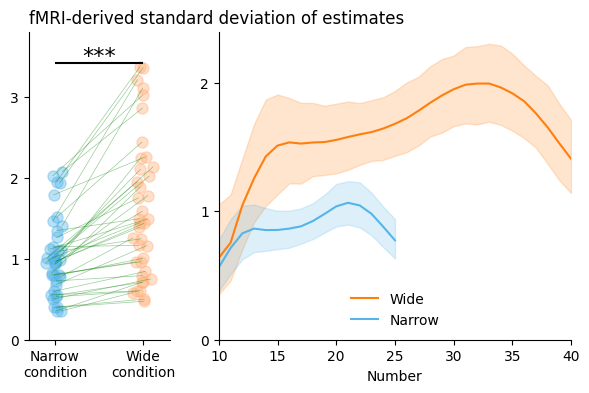

In [91]:
fig, axs = plt.subplots(figsize=(7, 4), ncols=2, width_ratios=(2,5),) # sharey=True)
model_label = 31
subrange = 'all' # '1124'
qty = 'sigma'

#####
ax = axs[1]
ax.set_ylim(0, 2.4)

for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide=cond==WIDE, condition=cond, n=range(10,MAX_COND[cond]+1)), x='n', y='sigma', label=cond.capitalize(),
                 color=COLORS_COND[cond], ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(10, 40)
ax.set_xlabel('Number')
ax.set_ylabel(None)
ax.legend(loc='lower center', )
ax.set_yticks([0, 1, 2])
#ax.set_title('Standard deviation of fMRI-derived estimates', x=.55)

####
ax = axs[0]
xx1 = index_filter(fmri_estimates_avgs, model_label=model_label, wide=True, subrange=subrange, condition=NARROW)[qty].rename(NARROW)
xx2 = index_filter(fmri_estimates_avgs, model_label=model_label, wide=True, subrange=subrange, condition=WIDE)[qty].rename(WIDE)
paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2,
                 color_decr_line='red', color_incr_line='g', col1=COLORS_COND[NARROW], col2='xkcd:peach') #COLORS_COND[WIDE],)
ax.set_xlim(0.7, 2.3)
ax.set_ylim(0,3.8)
ax.set_yticks([0,1,2,3])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.set_title('Standard deviation of fMRI-derived estimates', x=.5, ha='left')

# paired test
paired_test = pg.ttest(xx1, xx2, paired=True, alternative='less')
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(ax.get_ylim()[0] + .9*(ax.get_ylim()[1]-ax.get_ylim()[0]), 1, 2, color='k', lw=1.5, clip_on=False)
if (pv := paired_test['p-val'].iloc[0]) < 0.05:
    #ax.text(1.5, ax.get_ylim()[0] + 1.04*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')
    ax.text(1.5, ax.get_ylim()[0] + .92*(ax.get_ylim()[1]-ax.get_ylim()[0]), star_string(pv), ha='center', va='center', fontsize=16, color='k')

axs[0].set_title('fMRI-derived standard deviation of estimates', x=0., ha='left' )

#fig.savefig(f'figures/fmri_{qty}.pdf', bbox_inches='tight')

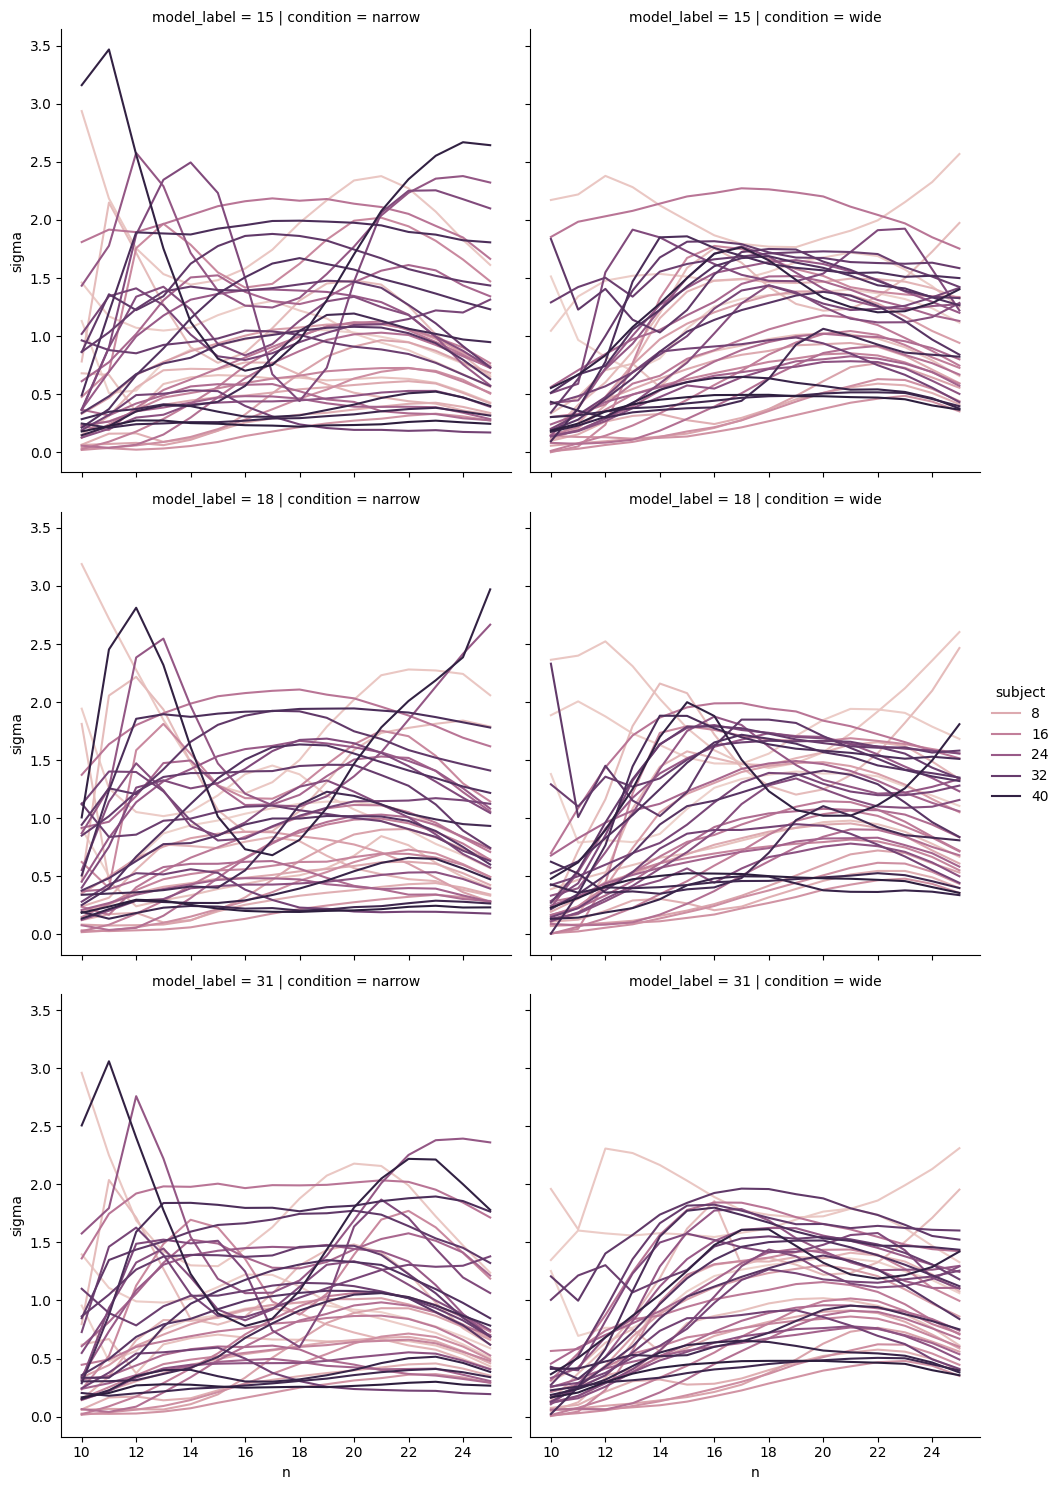

In [92]:
sns.relplot(index_filter(fmri_estimates_stats, wide=False), x='n', y='sigma', hue='subject', kind='line', col='condition', row='model_label') # model_label=15

## deltas

In [93]:
fisher_info_deltas

fi_diff  log_fi_diff  sqrt_fi_diff  inv_fi_diff  inv_sqrt_fi_diff     log_n
subject model_label n                                                                                 
1       15          10.0 -4.517753    -1.578028     -1.302013     0.675507          0.503465  2.302585
                    11.0 -1.851967    -0.693541     -0.563848     0.270302          0.215412  2.397895
                    12.0  0.759647     0.574263      0.329114    -0.446183         -0.252230  2.484907
                    13.0 -0.642712    -0.780934     -0.352006     0.998097          0.438661  2.564949
                    14.0 -0.162006    -0.358384     -0.120318     0.801324          0.267589  2.639057
...                            ...          ...           ...          ...               ...       ...
41      31          36.0  0.004423     0.016310      0.004247    -0.060139         -0.015659  3.583519
                    37.0  0.014591     0.058820      0.014647    -0.237189         -0.059056  3.610918
                    38.0  0.022645     0.099737      0.023760    -0.439636         -0.104689  3.637586
                    39.0  0.028919     0.139042      0.031699    -0.669591         -0.152532  3.663562
                    40.0  0.033701     0.176723      0.038574    -0.929131         -0.202541  3.688879

[3627 rows x 6 columns]

Index(['fi_diff', 'log_fi_diff', 'sqrt_fi_diff', 'inv_fi_diff', 'inv_sqrt_fi_diff', 'log_n'], dtype='object')


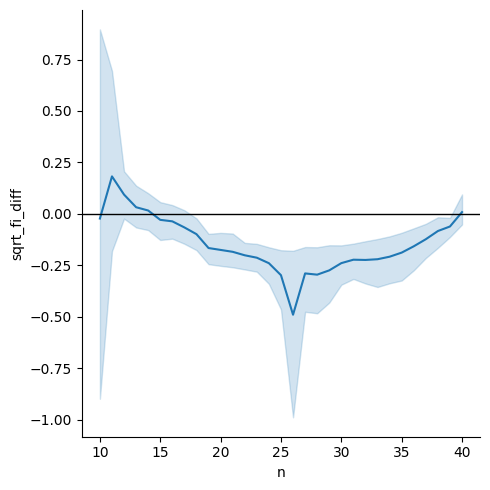

In [94]:
print(fisher_info_deltas.columns)
model_label = 31
sns.relplot( index_filter(fisher_info_deltas, model_label=model_label), x='n', y='sqrt_fi_diff', kind='line',) # model_label=15
axhline(0, color='k', linestyle='-', lw=1)
#ylim(-5,5)

Index(['mean_E_diff', 'mean_error_diff', 'var_E_diff', 'mean_abs_error_diff', 'sigma_diff', 'bias_diff', 'log_var_diff', 'log_n'], dtype='object')


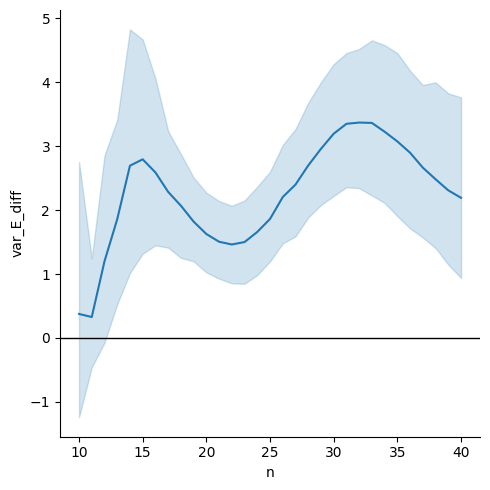

In [95]:
print(fmri_estimates_deltas.columns)
model_label = 31
wide_prior = True
sns.relplot( index_filter(fmri_estimates_deltas, model_label=model_label, wide=wide_prior), x='n', y='var_E_diff', kind='line',) # model_label=15
axhline(0, color='k', linestyle='-', lw=1)
#ylim(-5,5)

# Comparisons Stan/fMRI

## Stan vs. fMRI-decoding-quantities

### Variability across x

In [61]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide  condition n                                                                                            
1       15          False narrow    10.0  10.631045    0.631045  1.276577        0.631045  1.129857  0.631045  0.244182  2.302585
                                    11.0  11.175836    0.175836  0.259381        0.219162  0.509295  0.175836 -1.349456  2.397895
                                    12.0  12.060424    0.060424  0.282017        0.273017  0.531053  0.060424 -1.265786  2.484907
                                    13.0  13.059976    0.059976  0.596356        0.474482  0.772241  0.059976 -0.516918  2.564949
                                    14.0  14.295382    0.295382  0.779362        0.649081  0.882815  0.295382 -0.249280  2.639057
...                                             ...         ...       ...             ...       ...       ...       ...       ...
41      31          True  wide      36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
                                    37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
                                    38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
                                    39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
                                    40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[10998 rows x 8 columns]

In [62]:
MAX_COND

{'narrow': 25, 'wide': 40}

In [63]:
z = []
for boundary_buffer in [0,1,2]:
    for model_label in [15, 18, 31]:
        for wide_prior in [False, True]:
            for subject in index_filter(fmri_estimates_stats, model_label=model_label, wide=wide_prior).index.get_level_values('subject').unique():
                for cond in CONDITIONS:
                    a, b = 10+boundary_buffer, MAX_COND[cond]-boundary_buffer
                    dat = index_filter(fmri_estimates_stats, subject=subject, condition=cond, model_label=model_label, n=range(a, b+1), wide=wide_prior)
                    res = quick_ols(y=dat.log_var, x=dat.log_n)
                    z.append([boundary_buffer, subject, wide_prior, model_label, cond, res.params.log_n, res.params.const, res.rsquared, res.pvalues.log_n])
fmri_log_var_n_ols = pd.DataFrame(z, columns=['boundary_buffer', 'subject', 'wide', 'model_label', 'condition', 'slope', 'intercept', 'r2', 'pval']).set_index(['boundary_buffer', 'subject', 'wide', 'model_label', 'condition'])
fmri_log_var_n_ols

slope  intercept        r2          pval
boundary_buffer subject wide  model_label condition                                             
0               1       False 15          narrow     0.381524  -1.380257  0.051610  3.974709e-01
                                          wide       0.738361  -1.790186  0.208082  7.574470e-02
                2       False 15          narrow    -1.302426   3.720424  0.545275  1.087865e-03
                                          wide       0.408854  -0.364999  0.219756  6.700707e-02
                3       False 15          narrow    -0.025680   1.375510  0.000328  9.469060e-01
...                                                       ...        ...       ...           ...
2               39      True  31          wide       1.581002  -5.683608  0.788062  6.664039e-10
                40      True  31          narrow     0.843885  -1.641676  0.048950  4.895323e-01
                                          wide      -0.184223   2.720981  0.006624  6.865417e-01
                41      True  31          narrow     0.302238  -3.472482  0.230762  1.139440e-01
                                          wide       1.038516  -4.617994  0.877628  6.619167e-13

[1404 rows x 4 columns]

In [64]:
index_filter(fmri_log_var_n_ols, boundary_buffer=0, model_label=31, wide=True, condition=WIDE).r2.describe()

count    39.000000
mean      0.472967
std       0.292458
min       0.000055
25%       0.213005
50%       0.498837
75%       0.741454
max       0.933072
Name: r2, dtype: float64

In [65]:
index_filter(fmri_log_var_n_ols, boundary_buffer=0, model_label=31, wide=True, condition=WIDE).r2.sem()

0.04683070596802555

In [66]:
print( (index_filter(fmri_log_var_n_ols, boundary_buffer=0, model_label=31, wide=True, condition=WIDE).pval < 0.01).mean() )
index_filter(fmri_log_var_n_ols, boundary_buffer=0, model_label=31, wide=True, condition=WIDE).pval.describe(percentiles=[.75, .8, .9])

0.7692307692307693


count    3.900000e+01
mean     7.740141e-02
std      2.280454e-01
min      1.420336e-18
50%      9.006769e-06
75%      8.984285e-03
80%      1.223848e-02
90%      1.428499e-01
max      9.684603e-01
Name: pval, dtype: float64

In [67]:
res.pvalues.log_n

6.619167320444906e-13

In [68]:
res.params.const

-4.617993616458651

In [69]:
fmri_log_var_n_ols.groupby(['boundary_buffer', 'model_label', 'wide', 'condition']).describe()

slope                                                                        intercept                                 \
                                            count      mean       std       min       25%       50%       75%        max     count      mean       std        min   
boundary_buffer model_label wide  condition                                                                                                                         
0               15          False narrow     39.0  1.684899  2.418068 -1.944902  0.033993  1.110335  2.413149   7.710593      39.0 -5.506892  7.583867 -24.583819   
                                  wide       39.0  2.906070  2.293245 -0.101305  1.513877  2.558576  3.608710  10.474813      39.0 -8.759734  7.207713 -30.555954   
                            True  narrow     39.0  2.151862  2.780808 -1.759438  0.353307  1.509885  3.030257   8.772371      39.0 -6.532635  8.577276 -27.442260   
                                  wide       39.0  1.680197  1.653030 -0.524640  0.505257  1.200497  2.278429   6.005445      39.0 -4.700542  5.867192 -20.150079   
                18          False narrow     39.0  1.583574  2.357018 -2.417412  0.039463  0.980849  2.588936   7.632331      39.0 -5.238409  7.374026 -24.337327   
                                  wide       39.0  2.893793  2.178295 -0.362491  1.483661  2.475698  3.904227   8.145671      39.0 -8.727030  6.849512 -25.939707   
                            True  narrow     39.0  1.972724  2.760595 -2.259231  0.006302  1.399976  3.261907   8.618581      39.0 -6.062146  8.485898 -26.863623   
                                  wide       39.0  1.760005  1.607688 -0.900834  0.764929  1.631930  2.317797   6.089467      39.0 -4.965219  5.742240 -20.438883   
                31          False narrow     39.0  1.664336  2.396026 -1.911596  0.274443  0.982109  2.213341   7.774784      39.0 -5.463215  7.567012 -24.782377   
                                  wide       39.0  3.190606  2.112976 -0.019570  1.744323  2.655331  4.035317   8.284432      39.0 -9.681888  6.670073 -25.539352   
                            True  narrow     39.0  2.011146  2.625804 -1.662800  0.284567  1.204037  2.665920   8.606253      39.0 -6.271377  8.228277 -26.277866   
                                  wide       39.0  1.783739  1.571630 -0.569477  0.579825  1.573148  2.264180   5.736572      39.0 -5.194055  5.600625 -19.270875   
1               15          False narrow     39.0  1.573665  2.619719 -3.011576  0.050839  0.690860  2.024732   8.199856      39.0 -5.095688  8.147939 -25.360202   
                                  wide       39.0  2.254623  1.811904 -0.193039  1.011805  1.758814  2.910076   6.860987      39.0 -6.823284  5.954692 -22.386887   
                            True  narrow     39.0  2.020759  2.918902 -2.880973  0.110180  1.230821  2.505527   9.526491      39.0 -6.116204  8.924063 -28.857533   
                                  wide       39.0  1.486939  1.618552 -0.483678  0.279849  1.063990  2.080564   5.637206      39.0 -4.006716  5.801389 -18.437805   
                18          False narrow     39.0  1.530585  2.599289 -3.289381 -0.182646  0.868505  2.336793   7.934096      39.0 -5.002441  8.086943 -24.299418   
                                  wide       39.0  2.238688  1.784534 -0.239624  1.214653  1.738612  2.903292   6.977148      39.0 -6.779705  5.885793 -22.697745   
                            True  narrow     39.0  1.952636  2.934031 -3.207210 -0.157604  1.311398  3.031667   8.725382      39.0 -5.977705  8.931602 -26.599169   
                                  wide       39.0  1.585670  1.570036 -0.720943  0.522626  1.299802  2.061903   5.544600      39.0 -4.332101  5.668899 -18.523422   
                31          False narrow     39.0  1.533945  2.539091 -2.816359  0.177390  0.906457  2.007710   8.408343      39.0 -4.986293  7.955591 -26.001922   
                                  wide       39.0  2.515726  1.811399 -0.019861  1.4

In [70]:
stan_subj_n

m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6271  2.06576   4.33406   0.491465  1.43574  1.6271  2.302585
                  11.0  12.9481  1.69995   2.96530   0.603194  1.03588  1.9481  2.397895
                  12.0  14.6908  2.39927   5.88443   0.425824  1.72871  2.6908  2.484907
                  13.0  14.9564  2.13192   4.65695   0.480253  1.49023  1.9564  2.564949
                  14.0  16.8771  2.08874   4.46597   0.489797  1.45015  2.8771  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7192  3.64400  13.99690   0.289542  2.53287 -0.2808  3.583519
                  37.0  35.2929  3.63005  13.72570   0.286904  2.53779 -1.7071  3.610918
                  38.0  36.1955  3.43760  12.37650   0.304800  2.42296 -1.8045  3.637586
                  39.0  36.7015  3.29584  11.28910   0.314963  2.34759 -2.2985  3.663562
                  40.0  37.2749  3.09158  10.10140   0.342095  2.20157 -2.7251  3.688879

[1833 rows x 7 columns]

In [71]:
z = []
for boundary_buffer in [0,1,2]:
    for subject in fmri_estimates_stats.index.get_level_values('subject').unique():
        for cond in CONDITIONS:
            a, b = 10+boundary_buffer, MAX_COND[cond]-boundary_buffer
            dat = index_filter(stan_subj_n, subject=subject, condition=cond, n=range(a, b+1))
            res = quick_ols(y=dat.log_var, x=dat.log_n)
            z.append([boundary_buffer, subject, cond, res.params.log_n, res.params.const, res.rsquared, res.pvalues.log_n])
stan_log_var_n_ols = pd.DataFrame(z, columns=['boundary_buffer', 'subject', 'condition', 'slope', 'intercept', 'r2', 'pval']).set_index(['boundary_buffer', 'subject', 'condition'])
stan_log_var_n_ols

slope  intercept        r2          pval
boundary_buffer subject condition                                             
0               1       narrow     0.182768   0.928854  0.063102  3.480027e-01
                        wide       0.569543   0.363548  0.553942  1.587710e-06
                2       narrow    -0.197296   2.135654  0.068892  3.260568e-01
                        wide       0.670156   0.108912  0.472786  1.923060e-05
                3       narrow     0.511828   0.380341  0.220605  6.641074e-02
...                                     ...        ...       ...           ...
2               39      wide       0.968086  -0.869822  0.657921  2.871449e-07
                40      narrow    -0.105685   1.693801  0.018092  6.768468e-01
                        wide       0.549627   0.420890  0.429727  2.059371e-04
                41      narrow    -0.452917   2.618354  0.205446  1.389140e-01
                        wide       0.687404   0.262765  0.376131  6.698478e-04

[234 rows x 4 columns]

In [72]:
index_filter(stan_log_var_n_ols, boundary_buffer=0, condition=WIDE).r2.describe()

count    39.000000
mean      0.570709
std       0.155199
min       0.008075
25%       0.496536
50%       0.603830
75%       0.675431
max       0.814225
Name: r2, dtype: float64

In [73]:
index_filter(stan_log_var_n_ols, boundary_buffer=0, condition=WIDE).r2.sem()

0.024851686905962657

In [74]:
stan_log_var_n_ols.r2.sem()

0.015792940466175815

In [75]:
print( (index_filter(stan_log_var_n_ols, boundary_buffer=0, condition=WIDE).pval < 0.01).mean() )
index_filter(stan_log_var_n_ols, boundary_buffer=0, condition=WIDE).pval.describe(percentiles=[.75, .8, .9])

0.9743589743589743


count    3.900000e+01
mean     1.622931e-02
std      1.009849e-01
min      4.062611e-12
50%      2.735608e-07
75%      9.664142e-06
80%      2.130167e-05
90%      2.215024e-04
max      6.307082e-01
Name: pval, dtype: float64

In [76]:
stan_log_var_n_ols.groupby(['boundary_buffer', 'condition']).describe()

slope                                                                       intercept                                                    \
                          count      mean       std       min       25%       50%       75%       max     count      mean       std       min       25%       50%   
boundary_buffer condition                                                                                                                                           
0               narrow     39.0  0.477482  0.499533 -0.486937  0.171164  0.511828  0.851655  1.754794      39.0 -0.004383  1.499731 -3.739276 -1.057673 -0.256818   
                wide       39.0  0.866863  0.252967 -0.063510  0.723017  0.900583  1.028678  1.276685      39.0 -0.463028  0.839129 -1.752731 -1.113258 -0.556400   
1               narrow     39.0  0.304970  0.478090 -0.667175 -0.076060  0.324318  0.668961  1.304874      39.0  0.533127  1.411444 -2.359638 -0.607623  0.421568   
                wide       39.0  0.730541  0.244449 -0.046366  0.568224  0.749567  0.892700  1.163946      39.0  0.002244  0.805686 -1.427234 -0.472875 -0.021611   
2               narrow     39.0  0.206110  0.483283 -0.921769 -0.238473  0.192358  0.569672  1.036909      39.0  0.842647  1.417948 -1.566179 -0.287298  0.850124   
                wide       39.0  0.709584  0.244749 -0.120596  0.590073  0.692039  0.878462  1.207481      39.0  0.077577  0.802919 -1.500451 -0.417392  0.064233   

                                                 r2                                                                        pval                                    \
                                75%       max count      mean       std       min       25%       50%       75%       max count      mean       std           min   
boundary_buffer condition                                                                                                                                           
0               narrow     0.837108  2.885371  39.0  0.253628  0.207660  0.000335  0.055607  0.220605  0.406173  0.697388  39.0  0.203624  0.260039  5.681307e-05   
                wide       0.031510  2.778150  39.0  0.570709  0.155199  0.008075  0.496536  0.603830  0.675431  0.814225  39.0  0.016229  0.100985  4.062611e-12   
1               narrow     1.720254  3.581937  39.0  0.210678  0.177636  0.000814  0.049877  0.179901  0.365165  0.561723  39.0  0.262652  0.285183  2.028771e-03   
                wide       0.493492  2.746003  39.0  0.548386  0.176764  0.003821  0.460209  0.595384  0.656953  0.840419  39.0  0.019737  0.120031  2.867031e-12   
2               narrow     2.006751  4.218388  39.0  0.167900  0.144030  0.003443  0.043637  0.128437  0.270673  0.511445  39.0  0.320086  0.265968  8.937179e-03   
                wide       0.424042  2.965808  39.0  0.513773  0.174262  0.022010  0.428927  0.562329  0.633953  0.821498  39.0  0.013351  0.073617  7.645794e-11   

                                                                           
                                    25%           50%       75%       max  
boundary_buffer condition                                                  
0               narrow     8.248830e-03  6.641074e-02  0.379675  0.946375  
                wide       1.487524e-08  2.735608e-07  0.000010  0.630708  
1               narrow     2.209445e-02  1.306654e-01  0.442989  0.922878  
                wide       9.876625e-08  9.555255e-07  0.000053  0.750063  
2               narrow     8.292454e-02  2.526622e-01  0.516935  0.856261  
                wide       6.809279e-07  6.701937e-06  0.000210  0.460204

••• Model label: 18
  Wide prior: False
          n         r         CI95%     p-val   BF10     power
pearson  39  0.178969  [-0.09, 1.0]  0.137828  0.606  0.293264
           n        r         CI95%     p-val     power
spearman  39  0.16417  [-0.11, 1.0]  0.158974  0.262215
          n         r       CI95%     p-val   BF10     power
pearson  39  0.360223  [0.1, 1.0]  0.012141  4.542  0.741438
           n         r        CI95%     p-val     power
spearman  39  0.293117  [0.03, 1.0]  0.035073  0.575922
  Wide prior: True
          n         r         CI95%    p-val   BF10     power
pearson  39  0.044473  [-0.23, 1.0]  0.39403  0.249  0.084879
           n         r         CI95%     p-val     power
spearman  39  0.012348  [-0.26, 1.0]  0.470263  0.058389
          n         r       CI95%     p-val   BF10     power
pearson  39  0.358466  [0.1, 1.0]  0.012518  4.425  0.737462
           n         r        CI95%     p-val     power
spearman  39  0.372672  [0.12, 1.0]  0.009733  0.7688

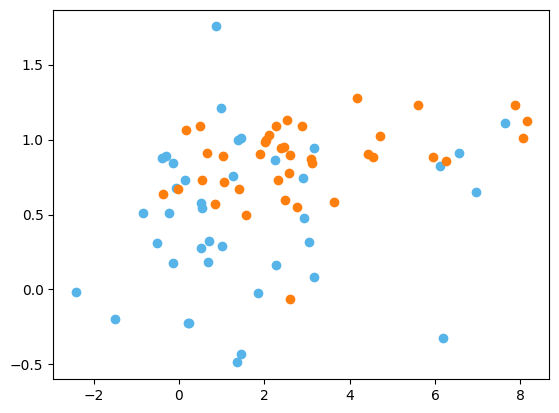

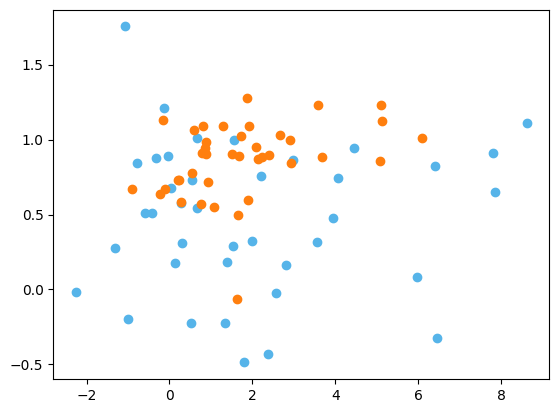

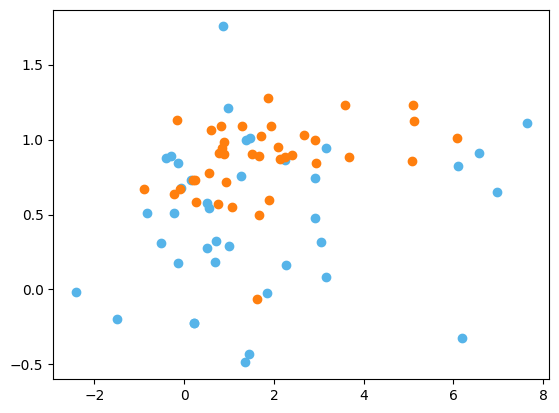

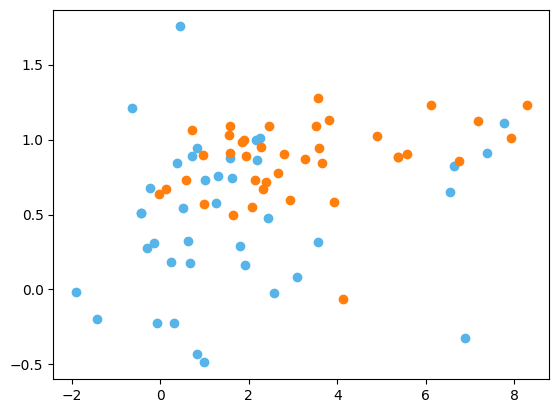

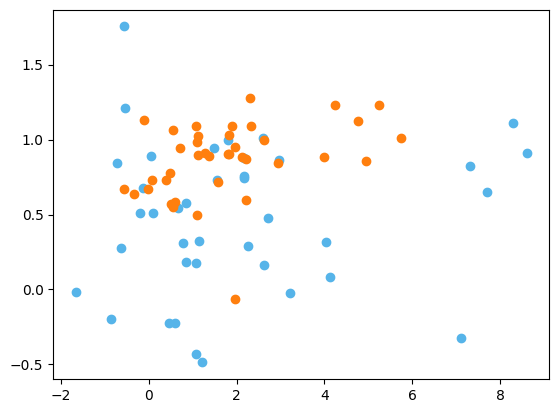

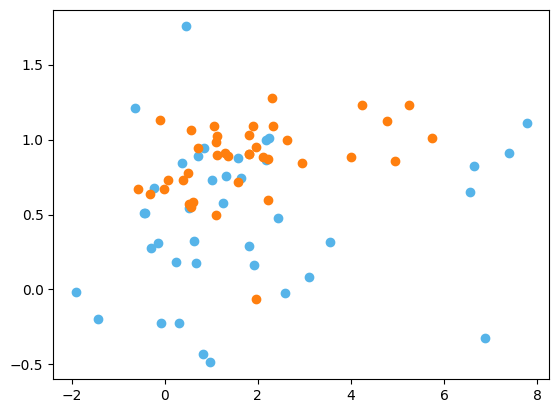

In [77]:
boundary_buffer = 0
for model_label in [18, 31]:
    print(f"••• Model label: {model_label}")
    for wide_prior in [False, True, 'cond']:
        print(f"  Wide prior: {wide_prior}")
        figure()
        for cond in CONDITIONS:
            subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
                index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
            wp = wide_prior if wide_prior != 'cond' else cond == WIDE
            xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide=wp).slope
            yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
            if len(xxx) != len(yyy):
                continue
            print( pg.corr(xxx, yyy, alternative='greater' )) # method='spearman'
            print( pg.corr(xxx, yyy, method='spearman', alternative='greater' ) )
            scatter(xxx, yyy, c=COLORS_COND[cond], )

          n         r       CI95%     p-val    BF10     power
pearson  38  0.488866  [0.2, 0.7]  0.001843  21.559  0.892171
           n         r         CI95%     p-val     power
spearman  38  0.449174  [0.15, 0.67]  0.004671  0.824804


/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/pingouin/correlation.py:133: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your results or use another robust correlation method.
  warnings.warn(


,n,r,CI95%,p-val,BF10,power,outliers
pearson,38,0.488866,"[0.25, 1.0]",0.000922,43.066,0.940404,NaN
spearman,38,0.449174,"[0.2, 1.0]",0.002336,NaN,0.895051,NaN
bicor,38,0.493977,"[0.26, 1.0]",0.000811,NaN,0.945028,NaN
percbend,38,0.494419,"[0.26, 1.0]",0.000802,NaN,0.945415,NaN
shepherd,38,0.563305,"[0.33, 1.0]",0.000213,NaN,0.977822,3.0
skipped,38,0.390680,"[0.12, 1.0]",0.011172,NaN,0.753952,4.0


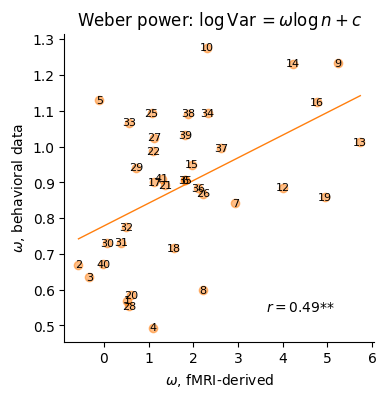

In [112]:
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
fig, ax = plt.subplots(figsize=(4, 4))
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
subjs = set(subjs) - set((24,))
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
r_pearsons = pg.corr(xxx, yyy,) # alternative='greater')
print( r_pearsons ) # method='spearman'
print( pg.corr(xxx, yyy, method='spearman' ) ) # alternative='greater', 
ax.scatter(x=xxx, y=yyy, color=c, alpha=.5)
for subj in subjs:
    ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
#sns.regplot(x=xxx, y=yyy, color=c, ax=ax, scatter_kws={'color': c, 'alpha': .5}, )
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.linspace(xxx.min(), xxx.max(), 100)
ax.plot(x_vals, odr_pred(res_odr, x_vals), color=c, lw=1,)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Weber power: $\log \operatorname{Var} = \omega \log n + c$')
ax.set_xlabel('$\omega$, fMRI-derived')
ax.set_ylabel('$\omega$, behavioral data')
pv = r_pearsons['p-val'].iloc[0]
ax.text(0.65, 0.1, f'$r = {r_pearsons.r.iloc[0]:.2f}${star_string(pv)}', transform=ax.transAxes)
pd.concat( [pg.corr(xxx, yyy, alternative='greater', method=m) for m in ['pearson', 'spearman', 'bicor', 'percbend', 'shepherd', 'skipped'] ] )
#fig.savefig(f'figures/weber_power.pdf', bbox_inches='tight')


In [114]:
fmri_estimates_stats

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject model_label wide  condition n                                                                                            
1       15          False narrow    10.0  10.631045    0.631045  1.276577        0.631045  1.129857  0.631045  0.244182  2.302585
                                    11.0  11.175836    0.175836  0.259381        0.219162  0.509295  0.175836 -1.349456  2.397895
                                    12.0  12.060424    0.060424  0.282017        0.273017  0.531053  0.060424 -1.265786  2.484907
                                    13.0  13.059976    0.059976  0.596356        0.474482  0.772241  0.059976 -0.516918  2.564949
                                    14.0  14.295382    0.295382  0.779362        0.649081  0.882815  0.295382 -0.249280  2.639057
...                                             ...         ...       ...             ...       ...       ...       ...       ...
41      31          True  wide      36.0  36.023040    0.023041  0.445585        0.492832  0.667522  0.023040 -0.808367  3.583519
                                    37.0  37.017834    0.017836  0.440337        0.497468  0.663579  0.017834 -0.820215  3.610918
                                    38.0  37.963100   -0.036901  0.407466        0.482546  0.638330 -0.036900 -0.897798  3.637586
                                    39.0  38.812283   -0.187718  0.311380        0.423914  0.558014 -0.187717 -1.166741  3.663562
                                    40.0  39.472120   -0.527880  0.224133        0.527880  0.473426 -0.527880 -1.495518  3.688879

[10998 rows x 8 columns]

In [115]:
stan_subj_n

m    sigma       var  inv_sigma  log_var    bias     log_n
subject condition n                                                                     
1       narrow    10.0  11.6271  2.06576   4.33406   0.491465  1.43574  1.6271  2.302585
                  11.0  12.9481  1.69995   2.96530   0.603194  1.03588  1.9481  2.397895
                  12.0  14.6908  2.39927   5.88443   0.425824  1.72871  2.6908  2.484907
                  13.0  14.9564  2.13192   4.65695   0.480253  1.49023  1.9564  2.564949
                  14.0  16.8771  2.08874   4.46597   0.489797  1.45015  2.8771  2.639057
...                         ...      ...       ...        ...      ...     ...       ...
41      wide      36.0  35.7192  3.64400  13.99690   0.289542  2.53287 -0.2808  3.583519
                  37.0  35.2929  3.63005  13.72570   0.286904  2.53779 -1.7071  3.610918
                  38.0  36.1955  3.43760  12.37650   0.304800  2.42296 -1.8045  3.637586
                  39.0  36.7015  3.29584  11.28910   0.314963  2.34759 -2.2985  3.663562
                  40.0  37.2749  3.09158  10.10140   0.342095  2.20157 -2.7251  3.688879

[1833 rows x 7 columns]

In [99]:
def smooth_ys(conv_w, dat_xs, dat_ys, xs=None, with_stdy=False):
    '''For each x' in xs, this considers all the occurences in which dat_xs = x, and computes the weighted average
    of all the dat_ys, each weighted by exp(-(x-x')^2/(2*conv_w^2)).
    If xs is None, it will be the (ordered) set of values encountered in dat_xs.
    Returns both xs and ys.
    If with_stdy is True, also returns '''
    assert dat_xs.shape == dat_ys.shape
    if xs is None:
        xs = np.array(sorted(list(set(dat_xs))))
    ys = np.ones(xs.shape)*np.nan
    if with_stdy:
        stdy = np.ones(xs.shape)*np.nan
    for ix,x in enumerate(xs):
        weights = np.exp(-(dat_xs-x)**2 / (2*conv_w**2))
        wsum = weights.sum()
        ys[ix] = (weights*dat_ys).sum() / wsum
        if with_stdy:
            stdy[ix] = np.sqrt( (weights*(dat_ys-ys[ix])**2).sum()  / wsum )
    if with_stdy:
        return xs, ys, stdy
    return xs, ys

In [117]:
index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer).loc[5]

,slope,intercept,r2,pval
wide,,,,
False,3.812110,-10.673016,0.628179,0.000251
True,-0.104759,1.763145,0.004947,0.706935


{1, 31}
{16, 9}


Text(0.5, 1.0, 'Response variability, behavioral data')

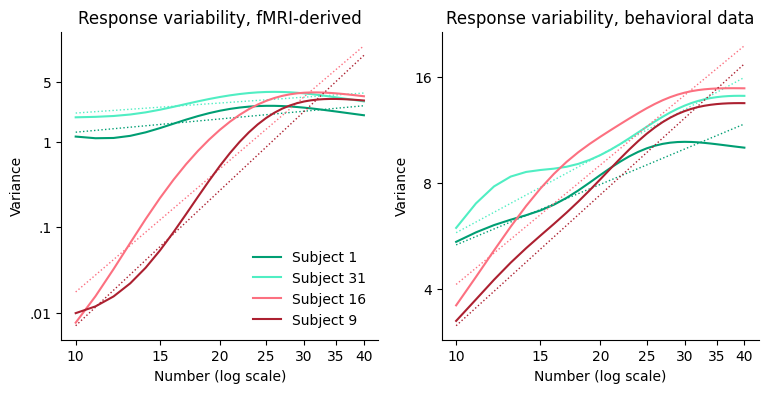

In [118]:
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
# fig, ax = plt.subplots(figsize=(4, 4))
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
subjs = set(subjs) - set((24,))
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
ind = (xxx>=0) & (xxx<=2) & (yyy<=.8)
#print( xxx[ind], yyy[ind] )
ns = np.arange(10, MAX_COND[cond]+1)
ilow = ind[ind].index
ilow = set(ilow) - set([18,32,40,28,30,20,  4])
print(ilow)
ind = (xxx>=4) & (yyy>=.95)
#print( xxx[ind], yyy[ind] )
ihi = ind[ind].index
ihi = set(ihi) - set([14, 13])
print(ihi)
log_ns = np.log(ns)
fig, axs = plt.subplots(ncols=2, figsize=(9, 4))
cols = ['#009E73', '#50EEC3', '#FC7080', '#aC2030', ] # sns.color_palette('colorblind')
conv_w = 0.2
lw = 1.5
qtyFMRI = 'log_var'
qtyStan = 'log_var'
xs = log_ns
ls_reg = ':'
for k,ii in enumerate(ilow):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ii, wide=wide_prior)[qtyFMRI], xs=xs)
    axs[0].plot(xs, ys, c=cols[k], label=f'Subject {ii}', lw=lw)
    slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide=wide_prior).loc[ii][['slope', 'intercept']]
    axs[0].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k], lw=1)
    #axs[0].axline((np.log(20), slope*np.log(20) + intercept), slope=slope, c=cols[k], ls=ls_reg, lw=1)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ii)[qtyStan], xs=xs)
    axs[1].plot(xs, ys , ls='-', c=cols[k], lw=lw)
    slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ii][['slope', 'intercept']]
    axs[1].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k], lw=1)
    #axs[1].axline((np.log(20), slope*np.log(20) + intercept), slope=slope, c=cols[k], ls=ls_reg, lw=1)
for k,ij in enumerate(ihi):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ij, wide=wide_prior)[qtyFMRI], xs=xs)
    axs[0].plot(xs,  ys, c=cols[k+2], label=f'Subject {ij}', lw=lw)
    slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide=wide_prior).loc[ij][['slope', 'intercept']]
    axs[0].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k+2], lw=1)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ij)[qtyStan], xs=xs)
    axs[1].plot(xs, ys , ls='-', c=cols[k+2], lw=lw)
    slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ij][['slope', 'intercept']]
    axs[1].plot(xs, slope*xs + intercept, ls=ls_reg, c=cols[k+2], lw=1)
    #axs[0].set_ylim(0,None)
    #axs[1].set_ylim(0,None)
axs[0].legend()
#axs[0].set_yticks([.5, 1, 1.5, 2, ])
for ax in axs:
    ax.set_xlabel('Number (log scale)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Variance')
    xticks = np.array([10, 15, 20, 25, 30, 35, 40])
    ax.set_xticks(np.log(xticks))
    ax.set_xticklabels(xticks)
yticks = np.array(['.01', '.1', 1, 5])
axs[0].set_yticks(np.log([float(y) for y in yticks]))
axs[0].set_yticklabels(yticks)
yticks = np.array([4, 8, 16])
axs[1].set_yticks(np.log(yticks))
axs[1].set_yticklabels(yticks)
axs[0].set_title('Response variability, fMRI-derived')
axs[1].set_title('Response variability, behavioral data')

In [119]:
xs

array([2.30258509, 2.39789527, 2.48490665, 2.56494936, 2.63905733, 2.7080502 , 2.77258872, 2.83321334, 2.89037176, 2.94443898, 2.99573227,
       3.04452244, 3.09104245, 3.13549422, 3.17805383, 3.21887582, 3.25809654, 3.29583687, 3.33220451, 3.36729583, 3.40119738, 3.4339872 ,
       3.4657359 , 3.49650756, 3.52636052, 3.55534806, 3.58351894, 3.61091791, 3.63758616, 3.66356165, 3.68887945])

[31, 1]
[16, 9]
          n         r        CI95%     p-val    BF10     power
pearson  38  0.488866  [0.25, 1.0]  0.000922  43.066  0.940404
           n         r         CI95%     p-val     power
spearman  38  0.449174  [0.15, 0.67]  0.004671  0.824804


Text(0.5, 1.0, 'Response variability, behavioral data')

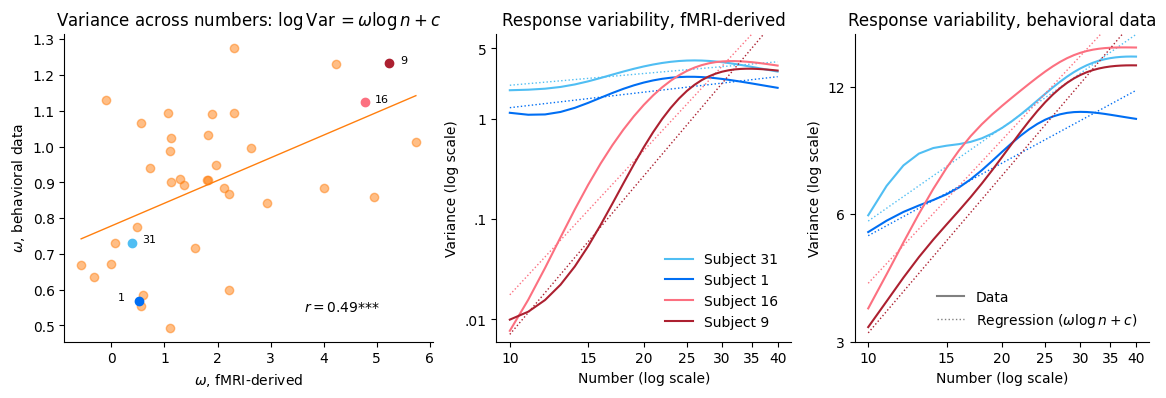

In [120]:
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
fig, axs = plt.subplots(ncols=3, figsize=(14, 4), width_ratios=(5,4,4))
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
subjs = set(subjs) - set((24,))
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
ind = (xxx>=0) & (xxx<=2) & (yyy<=.8)
#print( xxx[ind], yyy[ind] )
ns = np.arange(10, MAX_COND[cond]+1)
ilow = ind[ind].index
ilow = set(ilow) - set([18,32,40,28,30,20,  4])
ilow = [31, 1]
print(ilow)
ind = (xxx>=4) & (yyy>=.95)
#print( xxx[ind], yyy[ind] )
ihi = ind[ind].index
ihi = set(ihi) - set([14, 13])
ihi = [16, 9]
print(ihi)
#####
cols = ['#50EEC3', '#009E73', '#FC7080', '#aC2030', ]
cols = ['#50BEF3', '#006EA3', '#FC7080', '#aC2030', ]
cols = ['#50BEF3', '#006EF3', '#FC7080', '#aC2030', ]
cols_sid = {sid:col for sid, col in zip(ilow+ihi, cols)}

#####
ax = axs[0]
r_pearsons = pg.corr(xxx, yyy, alternative='greater')
print( r_pearsons ) # method='spearman'
print( pg.corr(xxx, yyy, method='spearman' ) )
ax.scatter(x=xxx[~np.isin(xxx.index, ilow+ihi)], y=yyy[~np.isin(yyy.index, ilow+ihi)], color=c, alpha=.5)
for subj in ilow+ihi:
    ax.scatter(x=xxx[subj], y=yyy[subj], color=cols_sid[subj], alpha=1., label=f'Subject {subj}',) #ec='k', lw=1)
ax.text(xxx.loc[31]+.2, yyy.loc[31], '31', color='k', fontsize=8,)
ax.text(xxx.loc[ 1]-.4, yyy.loc[ 1],  '1', color='k', fontsize=8,)
ax.text(xxx.loc[16]+.2, yyy.loc[16], '16', color='k', fontsize=8,)
ax.text(xxx.loc[ 9]+.2, yyy.loc[ 9],  '9', color='k', fontsize=8,)
# for subj in subjs:
#     ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
#sns.regplot(x=xxx, y=yyy, color=c, ax=ax, scatter_kws={'color': c, 'alpha': .5}, )
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.linspace(xxx.min(), xxx.max(), 100)
ax.plot(x_vals, odr_pred(res_odr, x_vals), color=c, lw=1,)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Variance across numbers: $\log \operatorname{Var} = \omega \log n + c$')
ax.set_xlabel('$\omega$, fMRI-derived')
ax.set_ylabel('$\omega$, behavioral data')
pv = r_pearsons['p-val'].iloc[0]
ax.text(0.65, 0.1, f'$r = {r_pearsons.r.iloc[0]:.2f}${star_string(pv)}', transform=ax.transAxes)

######
log_qties = True
conv_w = .2 if log_qties else 3
lw = 1.5
ns = np.arange(10+boundary_buffer, MAX_COND[cond]+1-boundary_buffer)
xs = np.log(ns) if log_qties else ns
qtyFMRI = 'log_var' if log_qties else 'sigma'
qtyStan = 'log_var' if log_qties else 'sigma'
for k,ii in enumerate(ilow+ihi):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ii, n=ns, wide=wide_prior)[qtyFMRI], xs=xs)
    axs[1].plot(xs, ys, c=cols[k], label=f'Subject {ii}', lw=lw)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ii, n=ns)[qtyStan], xs=xs)
    axs[2].plot(xs, ys , ls='-', c=cols[k], lw=lw)
    if log_qties:
        slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide=wide_prior).loc[ii][['slope', 'intercept']]
        axs[1].plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
        slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ii][['slope', 'intercept']]
        axs[2].plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
axs[1].legend()
for ax in axs[1:]:
    ax.set_xlabel('Number' + (' (log scale)' if log_qties else ''))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Variance (log scale)' if log_qties else 'Standard deviation')
    if log_qties:
        xticks = np.array([10, 15, 20, 25, 30, 35, 40])
        ax.set_xticks(np.log(xticks))
        ax.set_xticklabels(xticks)
if log_qties:        
    yticks = np.array(['.01', '.1', 1, 5])
    axs[1].set_yticks(np.log([float(y) for y in yticks]))
    axs[1].set_yticklabels(yticks)
    yticks = np.array([3, 6, 12])
    axs[2].set_yticks(np.log(yticks))
    axs[2].set_yticklabels(yticks)
    axs[1].set_ylim(np.log(.006), np.log(7))
    axs[2].set_ylim(np.log(3), np.log(16))
    axs[2].legend([Line2D([0], [0], c='grey', lw=lw), Line2D([0], [0], c='grey', ls=ls_reg, lw=1)],
                  ['Data', 'Regression ($\omega \log n + c$)'], loc='lower right')
else:
    axs[1].set_yticks([.5, 1, 1.5, 2, ])
axs[1].set_title('Response variability, fMRI-derived')
axs[2].set_title('Response variability, behavioral data')
#fig.suptitle('Data from 2025-07-24', x=.1, ha='left')
#fig.savefig(f'figures/variability_across_x.pdf', bbox_inches='tight')

### Average variability per subject in the two conditions

In [121]:
fmri_estimates_avgs

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var
subrange subject wide  condition model_label                                                                               
all      1       False narrow    15           17.496742   -0.003258  0.809486        0.639884  0.881334 -0.003258 -0.302409
                                 18           17.490109   -0.009891  0.918530        0.715775  0.941218 -0.009891 -0.165377
                                 31           17.489696   -0.010304  0.684116        0.579671  0.812900 -0.010304 -0.455493
                       wide      15           17.467846   -0.032154  1.465295        0.894194  1.186800 -0.032154  0.295767
                                 18           17.464351   -0.035649  1.434932        0.888099  1.175855 -0.035649  0.281057
...                                                 ...         ...       ...             ...       ...       ...       ...
1337     41      True  narrow    18           25.015866    0.015866  0.155676        0.208866  0.362512  0.015866 -2.205569
                                 31           25.017403    0.017403  0.181284        0.242189  0.401237  0.017403 -1.946800
                       wide      15           25.012638    0.012638  0.287656        0.362171  0.532198  0.012638 -1.276601
                                 18           25.009807    0.009808  0.294706        0.368574  0.539584  0.009807 -1.245556
                                 31           25.014618    0.014618  0.284279        0.357922  0.527312  0.014618 -1.302229

[3744 rows x 7 columns]

In [122]:
stan_avgs.index.get_level_values('subrange').unique()

Index(['all', 'narrowrange', '1124', '1223', '1322', '1139', '1238', '1337'], dtype='object', name='subrange')

In [123]:
index_filter(fmri_estimates_stats, model_label=31, condition=NARROW, wide=True)

mean_E  mean_error     var_E  mean_abs_error     sigma      bias   log_var     log_n
subject n                                                                                            
1       10.0  10.489996    0.489996  1.024747        0.489996  1.012298  0.489996  0.024446  2.302585
        11.0  11.101033    0.101033  0.199169        0.160104  0.446283  0.101033 -1.613602  2.397895
        12.0  12.170335    0.170334  0.335862        0.302554  0.579536  0.170335 -1.091055  2.484907
        13.0  13.130262    0.130262  0.559787        0.494164  0.748189  0.130262 -0.580198  2.564949
        14.0  14.257319    0.257318  0.729024        0.629840  0.853829  0.257319 -0.316048  2.639057
...                 ...         ...       ...             ...       ...       ...       ...       ...
41      36.0  36.046790    0.046790  0.441537        0.490404  0.664482  0.046790 -0.817494  3.583519
        37.0  37.029034    0.029035  0.437285        0.499277  0.661275  0.029034 -0.827170  3.610918
        38.0  37.973454   -0.026546  0.420786        0.491332  0.648680 -0.026546 -0.865631  3.637586
        39.0  38.806374   -0.193625  0.337467        0.437836  0.580919 -0.193626 -1.086287  3.663562
        40.0  39.435400   -0.564601  0.245129        0.564601  0.495105 -0.564600 -1.405971  3.688879

[1209 rows x 8 columns]

In [124]:
index_filter(fmri_estimates_avgs, subrange='all', model_label=31, condition=WIDE, wide=True)

,mean_E,mean_error,var_E,mean_abs_error,sigma,bias,log_var
subject,,,,,,,
1,24.983604,-0.016396,2.128483,1.037000,1.434839,-0.016396,0.682509
2,24.988247,-0.011752,2.575679,1.189598,1.585260,-0.011753,0.892416
3,25.059436,0.059436,12.014794,2.821999,3.354182,0.059436,2.363091
4,24.983643,-0.016357,1.059312,0.763118,1.002747,-0.016357,-0.065307
5,24.980352,-0.019649,4.879854,1.347119,2.132393,-0.019648,1.433597
6,24.983234,-0.016766,1.503094,0.875220,1.162093,-0.016766,0.002761
7,24.986268,-0.013731,0.435046,0.453908,0.605461,-0.013732,-1.304875
8,24.978957,-0.021043,1.041863,0.751501,0.961776,-0.021043,-0.278528
9,24.961596,-0.038404,1.893666,0.951336,1.164036,-0.038404,-0.530335


narrow
          n         r         CI95%     p-val    BF10     power
pearson  39  0.476103  [0.19, 0.69]  0.002186  18.384  0.881355
           n         r         CI95%   p-val     power
spearman  39  0.432996  [0.14, 0.66]  0.0059  0.802965
wide
          n         r         CI95%     p-val   BF10     power
pearson  39  0.332969  [0.02, 0.59]  0.038335  1.578  0.555645
           n         r         CI95%     p-val     power
spearman  39  0.336032  [0.02, 0.59]  0.036484  0.563901


Text(0, 0.5, 'Standard deviation, behavioral data')

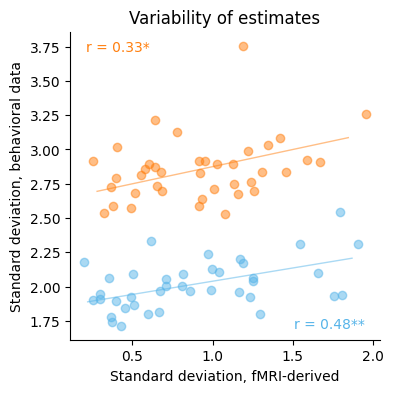

In [109]:
model_label = 31
subrange_per_cond = {NARROW:'narrowrange', WIDE:'narrowrange'} #'narrowrange' # '1124'
wide_prior = False #'cond'
qtyFMRI = 'sigma'; qtySTAN = 'avg_sigma'
#qtyFMRI = 'var_E'; qtySTAN = 'avg_var'
fig, ax = plt.subplots(figsize=(4, 4))
subjs = set(index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label).index.get_level_values('subject').unique()).intersection(
        index_filter(stan_avgs, subrange=subrange).index.get_level_values('subject').unique())
#subjs = set(subjs) - set((24,))
for cond in CONDITIONS:
    subrange = subrange_per_cond[cond]
    wp = (cond==WIDE) if wide_prior == 'cond' else wide_prior  #wp = wide_prior if wide_prior != 'cond' else (cond == WIDE)
    xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide=wp)[qtyFMRI]
    yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
    plt.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
    res_odr = odr_1dregression(x=xxx, y=yyy)
    x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
    plt.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
    print(cond)
    r_pearson = pg.corr(xxx, yyy) #, alternative='greater')
    print(r_pearson)
    print(pg.corr(xxx, yyy, method='spearman')) #, alternative='greater' ))
    pv = r_pearson['p-val'].iloc[0]
    ax.text({NARROW:.95, WIDE:.05}[cond], {NARROW:.05, WIDE:.95}[cond], f"r = {r_pearson.r.iloc[0]:.2f}{star_string(pv)}", transform=ax.transAxes, va='center', color=COLORS_COND[cond],
            ha='right' if cond == NARROW else 'left',  )

# for subj in subjs:
#     x1 = obvious_index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='narrow')[qtyFMRI][subj]
#     x2 = obvious_index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='wide')[qtyFMRI][subj]
#     y1 = index_filter(stan_avgs, subrange=subrange, condition='narrow')[qtySTAN][subj]
#     y2 = index_filter(stan_avgs, subrange=subrange, condition='wide')[qtySTAN][subj]
#     plt.plot([x1, x2], [y1, y2],
#         #color='limegreen' if (x2 > x1 and y2 > y1) else "#F75656", # if (x2 < x1 and y2 < y1) else 'gray',
#         color='grey',
#         alpha=0.5, linewidth=1
#     )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Variability of estimates')
ax.set_xlabel('Standard deviation, fMRI-derived')
ax.set_ylabel('Standard deviation, behavioral data')

#fig.savefig(f'figures/std_dev_fmri_vs_behavior.pdf', bbox_inches='tight')

narrow
           n         r         CI95%   p-val     power
spearman  39  0.432996  [0.14, 0.66]  0.0059  0.802965
0.005899684703302133
wide
           n         r         CI95%     p-val     power
spearman  39  0.336032  [0.02, 0.59]  0.036484  0.563901
0.03648374216898182


Text(1.1, 2, 'r = 0.34*')

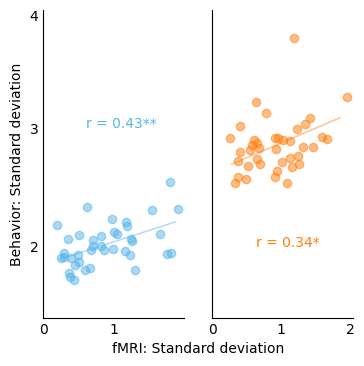

In [111]:
model_label = 31
subrange = 'narrowrange' # '1124'
qtyFMRI = 'sigma'; qtySTAN = 'avg_sigma'
wide_prior = False
corr_method = 'spearman' # 'pearson' #'spearman' #'pearson'
#qtyFMRI = 'var_E'; qtySTAN = 'avg_var'
fig, axs = plt.subplots(figsize=(4,4), ncols=2, sharey=True)
subjs = set(index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label).index.get_level_values('subject').unique()).intersection(
        index_filter(stan_avgs, subrange=subrange).index.get_level_values('subject').unique())
rs = {}
for ic,cond in enumerate(CONDITIONS):
    ax = axs[ic]
    xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide=wide_prior)[qtyFMRI]
    yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
    ax.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
    res_odr = odr_1dregression(x=xxx, y=yyy)
    x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
    ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
    print(cond)
    r_corr = pg.corr(xxx, yyy, method=corr_method) # alternative='greater', 
    rs[cond] = r_corr
    print(r_corr)
    print( r_corr["p-val"].iloc[0] )
    #print(pg.corr(xxx, yyy, method='spearman', alternative='greater' ))
    ax.tick_params(axis='both', length=0)
    ax.set_xlim(0,None)
sns.despine(fig)
axs[0].set_ylabel('Behavior: Standard deviation')
axs[0].set_yticks([2, 3, 4])
axs[0].get_yticklabels()[2].set_va('top')
axs[0].set_ylim(1.4, 4)
axs[0].set_xlabel('fMRI: Standard deviation', x=1.1)
axs[0].text(1.1, 3, f"r = {rs[NARROW].r.iloc[0]:.2f}{star_string(rs[NARROW]['p-val'].iloc[0])}", color=COLORS_COND[NARROW], ha='center')
axs[1].text(1.1, 2, f"r = {rs[WIDE].r.iloc[0]:.2f}{star_string(rs[WIDE]['p-val'].iloc[0])}", color=COLORS_COND[WIDE], ha='center')

In [93]:
r_pearson['p-val']

spearman    0.018242
Name: p-val, dtype: float64

In [127]:
axs[0].set_yticks([2, 3, 4])[2]

### Delta of variability across conditions

In [80]:
stan_delta_avgs

avg_var_delta_wn  avg_sigma_delta_wn  avg_inv_sigma_delta_wn  avg_log_var_delta_wn
subrange subject                                                                                    
all      1                 5.17332            0.932365               -0.142582              0.710005
         2                 5.29726            0.899024               -0.118458              0.638796
         3                 7.48430            1.100130               -0.114686              0.688436
         4                 6.19712            1.007670               -0.121861              0.686229
         5                 8.78104            1.481420               -0.219818              1.089600
...                            ...                 ...                     ...                   ...
1322     37                3.33378            0.633996               -0.108835              0.510532
         38                3.85896            0.755370               -0.133280              0.620238
         39                4.27392            0.851008               -0.166874              0.727767
         40                3.06597            0.598276               -0.105300              0.490295
         41                7.38094            1.257330               -0.187008              0.932225

[195 rows x 4 columns]

In [81]:
fmri_ests_avgs_deltas

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff
subrange subject wide  model_label                                                                                                    
all      1       False 15             -0.028896        -0.028896    0.655809             0.254310    0.305466  -0.028896      0.598176
                       18             -0.025758        -0.025758    0.516403             0.172324    0.234637  -0.025758      0.446434
                       31             -0.021607        -0.021607    0.647172             0.253735    0.319018  -0.021607      0.657903
                 True  15             -0.009398        -0.009398    1.475437             0.365632    0.520711  -0.009398      0.772774
                       18             -0.006143        -0.006143    1.267838             0.276767    0.416597  -0.006143      0.573453
...                                         ...              ...         ...                  ...         ...        ...           ...
1337     41      False 18             -0.015743        -0.015743    0.177769             0.228722    0.250979  -0.015743      1.497454
                       31             -0.008392        -0.008393    0.125707             0.165356    0.174288  -0.008392      0.992014
                 True  15             -0.004251        -0.004251    0.123439             0.140378    0.154276  -0.004251      0.812291
                       18             -0.006058        -0.006058    0.139030             0.159708    0.177072  -0.006058      0.960013
                       31             -0.002785        -0.002784    0.102995             0.115733    0.126075  -0.002785      0.644571

[1872 rows x 7 columns]

In [82]:
fmri_ests_avgs_deltas.columns, stan_delta_avgs.columns

(Index(['mean_E_diff', 'mean_error_diff', 'var_E_diff', 'mean_abs_error_diff', 'sigma_diff', 'bias_diff', 'log_var_diff'], dtype='object'),
 Index(['avg_var_delta_wn', 'avg_sigma_delta_wn', 'avg_inv_sigma_delta_wn', 'avg_log_var_delta_wn'], dtype='object'))

In [83]:
zz = []
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
for subrange in ['narrowrange', '1124', '1223', '1322']: # 'all', 
    for (a,b) in [
                (f'var_E_diff', 'avg_var_delta_wn'),
                (f'sigma_diff', 'avg_sigma_delta_wn'),
                (f'log_var_diff', 'avg_log_var_delta_wn'),
                ]:
        #print(a,b)
        cc = pg.corr(index_filter(fmri_ests_avgs_deltas, subrange=subrange, model_label=model_label, subject=subjects, wide=wide_prior)[a], # model_label=15
                     index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[b],
                     #method='spearman',
                     alternative='greater'
                     )
        if cc.r.values[0] < 0:
            continue
        #print( cc )
        cc.insert(0, 'stan_deltas', b)
        cc.insert(0, 'fmri_deltas', a)
        cc.insert(0, 'subrange', subrange)
        zz.append(cc)
        #print()
pd.concat(zz).sort_values(by='p-val')

,subrange,fmri_deltas,stan_deltas,n,r,CI95%,p-val,BF10,power
pearson,1223,log_var_diff,avg_log_var_delta_wn,38,0.422556,"[0.17, 1.0]",0.004110,11.619,0.854808
pearson,1124,log_var_diff,avg_log_var_delta_wn,38,0.416704,"[0.16, 1.0]",0.004627,10.487,0.844899
pearson,1124,sigma_diff,avg_sigma_delta_wn,38,0.416409,"[0.16, 1.0]",0.004655,10.434,0.844388
pearson,1223,sigma_diff,avg_sigma_delta_wn,38,0.403214,"[0.15, 1.0]",0.006034,8.341,0.820634
pearson,1322,log_var_diff,avg_log_var_delta_wn,38,0.371500,"[0.11, 1.0]",0.010825,5.06,0.756306
pearson,narrowrange,sigma_diff,avg_sigma_delta_wn,38,0.346768,"[0.08, 1.0]",0.016467,3.547,0.700032
pearson,narrowrange,log_var_diff,avg_log_var_delta_wn,38,0.330274,"[0.07, 1.0]",0.021425,2.843,0.660182
pearson,1322,sigma_diff,avg_sigma_delta_wn,38,0.301566,"[0.03, 1.0]",0.032886,1.989,0.587834
pearson,1124,var_E_diff,avg_var_delta_wn,38,0.276414,"[0.01, 1.0]",0.046487,1.494,0.522962
pearson,1223,var_E_diff,avg_var_delta_wn,38,0.261467,"[-0.01, 1.0]",0.056407,1.274,0.484473


Subject 24: 1.58693
Other subjects: Mean = 0.817, SD = 0.155
Subject 24 is 4.98 SD away from the mean of other subjects.
          n         r          CI95%     p-val   BF10     power
pearson  39  0.231009  [-0.09, 0.51]  0.157088  0.524  0.297144
           n         r         CI95%     p-val     power
spearman  39  0.337045  [0.02, 0.59]  0.035888  0.566627


/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/pingouin/correlation.py:133: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your results or use another robust correlation method.
  warnings.warn(


,n,r,CI95%,p-val,BF10,power,outliers
pearson,39,0.231009,"[-0.09, 0.51]",0.157088,0.524,0.297144,NaN
spearman,39,0.337045,"[0.02, 0.59]",0.035888,NaN,0.566627,NaN
bicor,39,0.369302,"[0.06, 0.61]",0.020683,NaN,0.652274,NaN
percbend,39,0.352300,"[0.04, 0.6]",0.027836,NaN,0.607519,NaN
shepherd,39,0.399228,"[0.08, 0.64]",0.015862,NaN,0.690584,3.0
skipped,39,0.399228,"[0.08, 0.64]",0.015862,NaN,0.690584,3.0


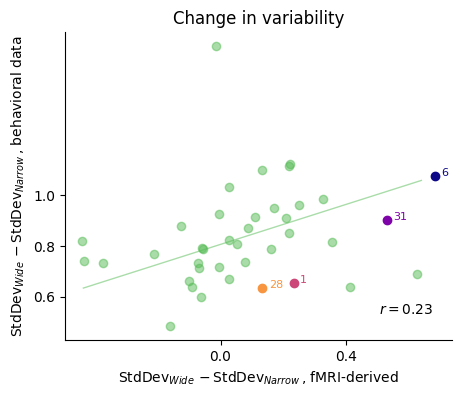

In [106]:
subrange = 'narrowrange'
model_label = 18
wide_prior = False
fig, ax = plt.subplots(figsize=(5,4))
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
#subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide=wide_prior)[qtyX] # model_label=15,
yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[qtyY]
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
iis = [6, 31, 1, 28 ]
ax.scatter(x=xxx[~np.isin(xxx.index, iis)], y=yyy[~np.isin(yyy.index, iis)], color=THIRD_COLOR, alpha=.5)
# for subj in subjects:
#     ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
cols = cm.plasma
for k, i in enumerate(iis):
    ax.scatter(x=xxx.loc[i], y=yyy.loc[i], color=cols(k / len(iis)),)
    ax.text(xxx[i]+.02, yyy[i], str(i), color=cols(k / len(iis)), fontsize=8,)
#sns.regplot(x=xxx, y=yyy, color=THIRD_COLOR, ax=ax)
res_odr = odr_1dregression(x=xxx, y=yyy)
x_vals = np.array([np.percentile(xxx, 2), np.percentile(xxx, 98)])
ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=THIRD_COLOR, )
p_corr_res = pg.corr(xxx, yyy,) # alternative='greater');
print(p_corr_res)
s_corr_res = pg.corr(xxx, yyy, method='spearman') #, alternative='greater')
print(s_corr_res)
#ax.set_title(f"Pearson r = {p_corr_res.r.iloc[0]:.2f} (pv = {p_corr_res['p-val'].iloc[0]:.3f})\n"
#          f"Spearman r = {s_corr_res.r.iloc[0]:.2f} (pv = {s_corr_res['p-val'].iloc[0]:.3f}) ({subrange})")
#suptitle(f"Model {model_label}", y=1.05)
ax.set_title('Change in variability')
ax.set_xlabel('$\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$, fMRI-derived')
ax.set_ylabel('$\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$, behavioral data')
pv = p_corr_res['p-val'].iloc[0]
ax.text(0.95, 0.1, f"$r = {p_corr_res.r.iloc[0]:.2f}${star_string(pv)}", transform=ax.transAxes, va='center', ha='right', ) #fontsize=12, )
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([0, .4])
ax.set_yticks([.6, .8, 1])

pd.concat( [pg.corr(xxx, yyy, method=m) for m in ['pearson', 'spearman', 'bicor', 'percbend', 'shepherd', 'skipped'] ] )

#fig.savefig(f'figures/delta_stddev_fmri_vs_behavior.pdf', bbox_inches='tight')


In [133]:
index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, n=ns, subject=ii).sigma

wide   n   
False  10.0    0.072082
       11.0    0.082746
       12.0    0.099562
       13.0    0.117503
       14.0    0.159922
       15.0    0.205538
       16.0    0.261123
       17.0    0.333186
       18.0    0.419018
       19.0    0.507382
       20.0    0.599551
       21.0    0.689403
       22.0    0.722653
       23.0    0.700801
       24.0    0.612031
       25.0    0.532970
True   10.0    0.066719
       11.0    0.079243
       12.0    0.098344
       13.0    0.117045
       14.0    0.154225
       15.0    0.202094
       16.0    0.261437
       17.0    0.336331
       18.0    0.425632
       19.0    0.523078
       20.0    0.650534
       21.0    0.785837
       22.0    0.953515
       23.0    1.087458
       24.0    1.266163
       25.0    1.374528
       26.0    1.499054
       27.0    1.609495
       28.0    1.700783
       29.0    1.796032
       30.0    1.837634
       31.0    1.902022
       32.0    1.921683
       33.0    1.906115
       34.0    1.880011
    

Text(0.5, 1.0, 'Response variability, behavioral data')

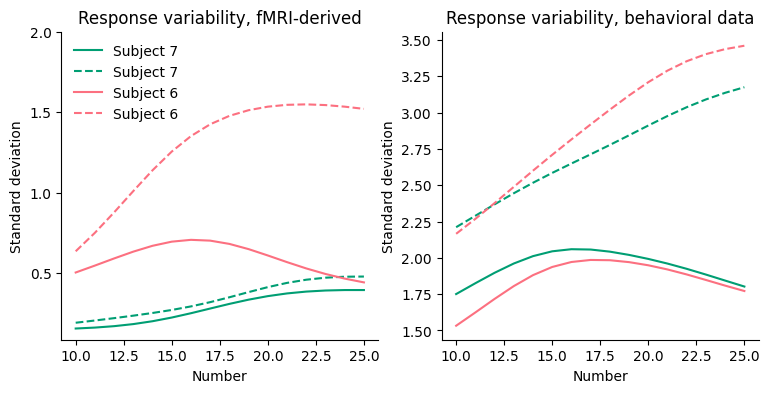

In [134]:
subrange = '1124'
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide=wide_prior)[qtyX] # model_label=15,
yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[qtyY]
# ind = (xxx>=0) & (xxx<=2) & (yyy<=.8)
# #print( xxx[ind], yyy[ind] )
# ns = np.arange(10, MAX_COND[cond]+1)
# ilow = ind[ind].index
# ilow = set(ilow) - set([18,32,40,28,30,20,  4])
# print(ilow)
ilow = [7,]
# ind = (xxx>=4) & (yyy>=.95)
# #print( xxx[ind], yyy[ind] )
# ihi = ind[ind].index
# ihi = set(ihi) - set([14, 13])
# print(ihi)
ihi = [6,]
ns = np.arange(10, 25+1)
#logns = np.log(ns)
fig, axs = plt.subplots(ncols=2, figsize=(9, 4))
cols = ['#009E73', '#50EEC3', '#FC7080', '#aC2030', ] # sns.color_palette('colorblind')
conv_w = 3
lw = 1.5
for k,ii in enumerate(ilow):
    for cond in CONDITIONS:
        ls = '-' if cond == NARROW else '--'
        xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, n=ns, subject=ii, wide=False).sigma, xs=ns)
        axs[0].plot(ns, ys, c=cols[k], label=f'Subject {ii}', lw=lw, ls=ls)
        xs, ys = smooth_ys(conv_w, ns, index_filter(stan_subj_n, condition=cond, n=ns, subject=ii).sigma, xs=ns)
        axs[1].plot(xs, ys , c=cols[k], lw=lw, ls=ls)
for k,ij in enumerate(ihi):
    for cond in CONDITIONS:
        ls = '-' if cond == NARROW else '--'
        xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, n=ns, subject=ij, wide=False).sigma, xs=ns)
        axs[0].plot(ns,  ys, c=cols[k+2], label=f'Subject {ij}', lw=lw, ls=ls)
        xs, ys = smooth_ys(conv_w, ns, index_filter(stan_subj_n, condition=cond, n=ns, subject=ij).sigma, xs=ns)
        #print(xs)
        axs[1].plot(xs, ys , c=cols[k+2], lw=lw, ls=ls)
    #axs[0].set_ylim(0,None)
    #axs[1].set_ylim(0,None)
axs[0].legend()
axs[0].set_yticks([.5, 1, 1.5, 2, ])
for ax in axs:
    ax.set_xlabel('Number')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Standard deviation')
axs[0].set_title('Response variability, fMRI-derived')
axs[1].set_title('Response variability, behavioral data')

In [135]:
index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label)[qtyX]

subject  wide 
1        False    0.208677
         True     0.376876
2        False    0.641959
         True     0.727766
3        False    0.016290
                    ...   
39       True    -0.108222
40       False   -0.378075
         True     1.253330
41       False    0.237834
         True     0.240112
Name: sigma_diff, Length: 76, dtype: float64

Index([3, 9, 13, 16, 18, 19, 21, 25, 27, 29, 33, 36, 37, 39, 40], dtype='int64', name='subject')


Text(0.5, 1.0, 'Change in variability, behavioral data')

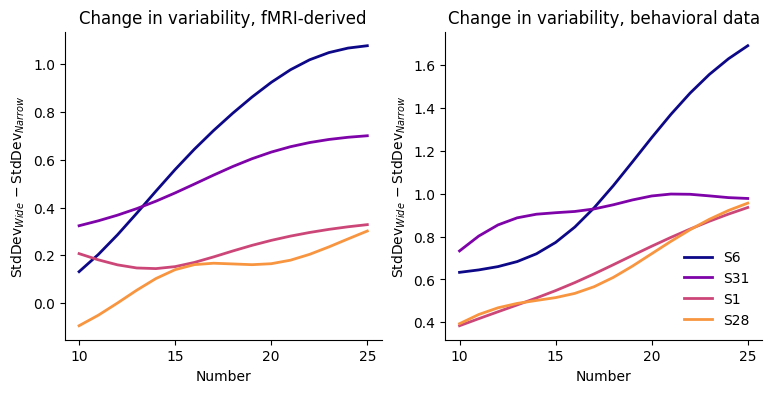

In [136]:
subrange = 'narrowrange'
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label, wide=wide_prior).index.get_level_values('subject').unique()
subjects = set(subjects) - set((24,))
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide=wide_prior)[qtyX] # model_label=15,
print(xxx[xxx<0].index)
iis =  [6, 7, 30]
iis = [1,2,6,7,8,12,17,22,28,30,31,38,]
iis = [6, 31, 1, 28 ] # 2, 30
#iis += [7,8,12,17,38,]
ns = np.arange(10, 25+1)
fig, axs = plt.subplots(ncols=2, figsize=(9, 4))
#cols = ['#009E73', '#50EEC3', '#FC7080', '#aC2030', ] # sns.color_palette('colorblind')
#cols = ['#50BEF3', '#006EF3', '#FC7080', '#aC2030', '#FFB300', '#D55E00', ] # sns.color_palette('colorblind')
cols = cm.plasma
conv_w = 3
lw = 2.
ls = '-' # 
for k,ii in enumerate(iis):
    xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_deltas, model_label=model_label, n=ns, wide=wide_prior, subject=ii).sigma_diff, xs=ns)
    axs[0].plot(ns, ys, c=cols(k/(len(iis))), label=f'S{ii}', lw=lw, ls=ls)
    #axs[0].text(ns[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
    xs, ys = smooth_ys(conv_w, ns, index_filter(stan_deltas_subj_n, n=ns, subject=ii).delta_sigma, xs=ns)
    axs[1].plot(xs, ys , c=cols(k/(len(iis))), label=f'S{ii}', lw=lw, ls=ls)
    #axs[1].text(xs[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
axs[1].legend(loc='lower right', )
#axs[0].set_yticks([.5, 1, 1.5, 2, ])
for ax in axs:
    ax.set_xlabel('Number')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('$\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$')
    ax.set_xticks([10,15,20,25])
    #ax.set_ylim(0,None)
axs[0].set_title('Change in variability, fMRI-derived')
axs[1].set_title('Change in variability, behavioral data')
#fig.savefig(f'figures/delta_stddev_across_x_examples.pdf', bbox_inches='tight')

In [137]:
index_filter(fmri_ests_avgs_deltas, model_label=model_label)

mean_E_diff  mean_error_diff  var_E_diff  mean_abs_error_diff  sigma_diff  bias_diff  log_var_diff
subrange subject wide                                                                                                     
all      1       False    -0.025758        -0.025758    0.516403             0.172324    0.234637  -0.025758      0.446434
                 True     -0.006143        -0.006143    1.267838             0.276767    0.416597  -0.006143      0.573453
         2       False    -0.069499        -0.069499    1.726722             0.413520    0.627773  -0.069499      0.963302
                 True     -0.020089        -0.020089    1.821264             0.393158    0.632985  -0.020089      0.935191
         3       False    -0.109031        -0.109031   -0.134210             0.853721   -0.003256  -0.109031      0.027593
...                             ...              ...         ...                  ...         ...        ...           ...
1337     39      True     -0.076091        -0.076091   -0.977610            -0.339439   -0.410325  -0.076091     -0.768691
         40      False     0.099476         0.099475   -1.014190             0.539706   -0.208191   0.099476     -0.119696
                 True     -0.131434        -0.131434    7.751154             1.880711    1.482274  -0.131434      1.336887
         41      False    -0.015743        -0.015743    0.177769             0.228722    0.250979  -0.015743      1.497454
                 True     -0.006058        -0.006058    0.139030             0.159708    0.177072  -0.006058      0.960013

[624 rows x 7 columns]

In [138]:
print( index_filter(stan_delta_avgs, subrange='1124').loc[24].avg_sigma_delta_wn )
stan.loc['delta_avg_sigma_s_1124[22]']

1.65745


Mean            1.657450
MCSE            0.001749
StdDev          0.195296
MAD             0.198068
5%              1.345260
50%             1.654000
95%             1.984610
ESS_bulk    12774.400000
ESS_tail     8048.870000
R_hat           1.000600
Name: delta_avg_sigma_s_1124[22], dtype: float64

In [139]:
stan

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-27492.300000,1.443070,64.707900,64.863700,-27599.300000,-27492.700000,-27386.900000,2010.54,3651.61,1.00348
z_m_0_15[1],0.114610,0.000566,0.021739,0.021247,0.078855,0.114435,0.151094,1480.90,2538.84,1.00544
z_m_0_15[2],0.099510,0.000547,0.022211,0.022235,0.063319,0.099588,0.135871,1653.63,3347.16,1.00280
z_m_0_15[3],0.116600,0.000439,0.022596,0.022414,0.079168,0.116657,0.153351,2666.43,4364.59,1.00258
z_m_0_15[4],0.101373,0.000458,0.022635,0.022545,0.063642,0.101505,0.138453,2448.83,4141.75,1.00395
...,...,...,...,...,...,...,...,...,...,...
delta_avg_log_var_s_1322[35],0.510532,0.001216,0.153398,0.154659,0.255985,0.510545,0.762470,16217.20,7281.18,1.00044
delta_avg_log_var_s_1322[36],0.620238,0.001170,0.152782,0.152259,0.368349,0.619860,0.874401,17369.80,7457.56,1.00030
delta_avg_log_var_s_1322[37],0.727767,0.001210,0.156056,0.154791,0.465421,0.728736,0.985814,16875.30,7503.76,1.00082
delta_avg_log_var_s_1322[38],0.490295,0.001218,0.158946,0.159789,0.229985,0.491158,0.751249,17153.40,7003.40,1.00109


### Mixed effects

In [140]:
model_label = 31
df = index_filter(fmri_estimates_deltas, model_label=model_label, n=range(10,26), wide=False).join( stan_deltas_subj_n, )
df.reset_index(inplace=True)
df

,subject,n,mean_E_diff,mean_error_diff,var_E_diff,mean_abs_error_diff,sigma_diff,bias_diff,log_var_diff,log_n,delta_inv_sigma,delta_log_var,delta_sigma,delta_var
0,1,10.0,-0.081344,-0.081344,0.657403,-0.081344,0.297477,-0.081344,0.541726,2.302585,0.039015,-0.143129,-0.133141,-0.502046
1,1,11.0,0.073202,0.073202,0.255408,0.035656,0.217849,0.073202,0.751992,2.397895,-0.179203,0.705200,0.718774,3.037980
2,1,12.0,0.088131,0.088130,0.265157,0.071266,0.199304,0.088131,0.603769,2.484907,-0.038018,0.202496,0.276524,1.552040
3,1,13.0,0.211437,0.211437,0.016345,0.029273,0.010774,0.211437,0.028410,2.564949,-0.110987,0.528181,0.647982,3.282000
4,1,14.0,-0.120991,-0.120990,0.084625,-0.043338,0.048880,-0.120991,0.112962,2.639057,-0.100952,0.483441,0.600344,3.100070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,41,21.0,-0.010460,-0.010458,0.145889,0.183575,0.195583,-0.010460,1.073894,3.044522,-0.372635,1.869150,2.598490,15.944600
620,41,22.0,-0.008782,-0.008781,0.130691,0.168489,0.173002,-0.008782,0.932580,3.091042,-0.141807,0.593044,0.647813,2.963900
621,41,23.0,-0.019991,-0.019993,0.116401,0.154286,0.154269,-0.019991,0.829520,3.135494,-0.182260,0.865990,1.078390,5.648060
622,41,24.0,-0.052578,-0.052577,0.083908,0.123595,0.124280,-0.052578,0.744805,3.178054,-0.307031,1.531800,2.065310,12.007800


In [141]:
#qty_beh = 'delta_log_inv_var'; qty_fmri = 'log_var_diff'
qty_beh = 'delta_sigma'; qty_fmri = 'sigma_diff'
model = smf.mixedlm(f"{qty_beh} ~ {qty_fmri}", df, groups="n",
                    #re_formula=f"~ {qty_fmri}"
                    #re_formula=f"~ log_n"
                    #re_formula=f"~ {qty_fmri} + n"
                    )
result = model.fit()
print( result.summary() )

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_sigma
No. Observations: 624     Method:             REML       
No. Groups:       16      Scale:              0.2183     
Min. group size:  39      Log-Likelihood:     -437.8024  
Max. group size:  39      Converged:          Yes        
Mean group size:  39.0                                   
----------------------------------------------------------
             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept    0.835     0.087  9.628  0.000   0.665   1.005
sigma_diff   0.043     0.049  0.872  0.383  -0.053   0.138
n Var        0.115     0.096                              



In [142]:
# Regress out the effect of x (categorical) from both variables
resid_beh = smf.ols(f"{qty_beh} ~ C(n)", data=df).fit().resid
resid_fmri = smf.ols(f"{qty_fmri} ~ C(n)", data=df).fit().resid
df[f'{qty_beh}_adj'] = resid_beh
df[f'{qty_fmri}_adj'] = resid_fmri
model = smf.mixedlm(f"{qty_beh}_adj ~ {qty_fmri}_adj", df,
                    groups="subject",
                    re_formula=f"~ {qty_fmri}_adj")
result = model.fit()
result.summary()


/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/apc/Documents/Neuro/numerosity-fmri/neural_priors/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/apc/Do

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
=======================================================================
Model:                MixedLM    Dependent Variable:    delta_sigma_adj
No. Observations:     624        Method:                REML           
No. Groups:           39         Scale:                 0.1865         
Min. group size:      16         Log-Likelihood:        -388.9660      
Max. group size:      16         Converged:             No             
Mean group size:      16.0                                             
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                    -0.002    0.032 -0.060 0.953 -0.065  0.061
sigma_diff_adj               -0.013    0.058 -0.230 0.818 -0.127  0.101
subject Var                   0.027    0.022                           
subject x sigma_diff_adj Cov  0.006    0.021                           
sigma_diff_adj Var            0.003                                    
=======================================================================

"""

## Stan vs fMRI-Fisher-information

### Avg variability

In [143]:
fisher_info_avgs

fi    log_fi   sqrt_fi     inv_fi  inv_sqrt_fi
subrange subject model_label condition                                                      
all      1       15          narrow     0.855621 -1.172242  0.706231   5.068577     2.080115
                             wide       0.251763 -2.447645  0.377351  18.130914     3.942094
                 18          narrow     0.843114 -1.413441  0.656623   6.623666     2.375812
                             wide       0.274819 -2.578914  0.368716  21.365276     4.262218
                 31          narrow     0.516915 -1.606773  0.541309   6.827314     2.467959
...                                          ...       ...       ...        ...          ...
1322     41      15          wide       0.701192 -0.361723  0.835927   1.444619     1.200130
                 18          narrow     2.052164  0.713177  1.430516   0.493025     0.701097
                             wide       0.666308 -0.407681  0.815933   1.505791     1.226607
                 31          narrow     1.587406  0.455942  1.258020   0.638048     0.797441
                             wide       0.772112 -0.283385  0.873105   1.356512     1.158676

[1170 rows x 5 columns]

In [144]:
stan_avgs

avg_var  avg_sigma  avg_inv_sigma  avg_log_var
subrange condition subject                                                 
all      narrow    1         4.52088    2.09285       0.493343      1.44519
                   2         5.15803    2.23618       0.461450      1.57827
                   3         6.72513    2.54331       0.409841      1.82631
                   4         5.61183    2.33472       0.440872      1.66681
                   5         4.06040    1.95983       0.544057      1.28464
...                              ...        ...            ...          ...
1337     wide      37       11.41220    3.27085       0.326721      2.30413
                   38       12.14610    3.36843       0.318773      2.35849
                   39       10.44700    3.12579       0.344917      2.20704
                   40        9.43286    2.98738       0.354276      2.13250
                   41       13.41200    3.54345       0.302852      2.46119

[507 rows x 4 columns]

In [145]:
index_filter(stan_avgs, subrange='all', condition='narrow') #.loc[1]

,avg_var,avg_sigma,avg_inv_sigma,avg_log_var
subject,,,,
1,4.52088,2.09285,0.493343,1.44519
2,5.15803,2.23618,0.461450,1.57827
3,6.72513,2.54331,0.409841,1.82631
4,5.61183,2.33472,0.440872,1.66681
5,4.06040,1.95983,0.544057,1.28464
6,3.52425,1.81868,0.595958,1.12244
7,3.88920,1.91319,0.561765,1.22994
8,4.55732,2.09499,0.496002,1.44096
9,3.88264,1.92441,0.546733,1.25966


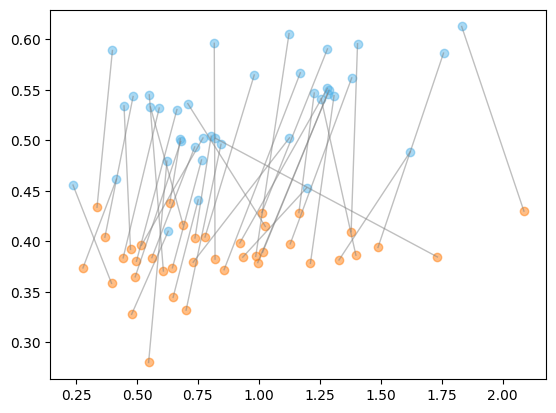

In [146]:
model_label = 31
subrange = 'narrowrange'
for cond in CONDITIONS:
    plt.scatter(index_filter(fisher_info_avgs, subrange=subrange, model_label=model_label, condition=cond).sqrt_fi,
                index_filter(stan_avgs, subrange=subrange, condition=cond).avg_inv_sigma, alpha=0.5, color=COLORS_COND[cond], )
for subj in stan_avgs.index.get_level_values('subject').unique():
    plt.plot(
        [index_filter(fisher_info_avgs, subrange=subrange, model_label=model_label, condition='narrow').sqrt_fi[subj],
         index_filter(fisher_info_avgs, subrange=subrange, model_label=model_label, condition='wide').sqrt_fi[subj]],
        [index_filter(stan_avgs, subrange=subrange, condition='narrow').avg_inv_sigma[subj], index_filter(stan_avgs, subrange=subrange, condition='wide').avg_inv_sigma[subj]],
        color='gray', alpha=0.5, linewidth=1
    )

### Deltas

In [147]:
fisher_info_avgs_deltas.columns, stan_delta_avgs.columns

(Index(['fi_delta_wn', 'log_fi_delta_wn', 'sqrt_fi_delta_wn', 'inv_fi_delta_wn', 'inv_sqrt_fi_delta_wn'], dtype='object'),
 Index(['avg_var_delta_wn', 'avg_sigma_delta_wn', 'avg_inv_sigma_delta_wn', 'avg_log_var_delta_wn'], dtype='object'))

In [148]:
zz = []
model_label = 18
subjects = index_filter(fisher_info_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
# /!\ Filtering out subject
#subjects = set(subjects) - set((36,)) # 24, 33, 36
for subrange in ['narrowrange', '1124', '1223', '1322']: # 'all', 
    for (a,b) in [(f'inv_fi_delta_wn', 'avg_var_delta_wn'),
                  (f'inv_sqrt_fi_delta_wn', 'avg_sigma_delta_wn'),
                  (f'log_fi_delta_wn', 'avg_log_var_delta_wn'),
                  (f'sqrt_fi_delta_wn', 'avg_inv_sigma_delta_wn'),
        ]:
        #print(a,b)
        cc = pg.corr(index_filter(fisher_info_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label)[a], # model_label=15, 
                     index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[b],
                     #method='spearman', #'pearson', #'spearman', #
                     method='pearson',
                     alternative='greater' 
                     )
        if cc.r.values[0] < 0:
             continue
        #print( cc )
        cc.insert(0, 'stan_deltas', b)
        cc.insert(0, 'fmri_deltas', a)
        cc.insert(0, 'subrange', subrange)
        zz.append(cc)
pd.concat(zz).sort_values(by='p-val')

,subrange,fmri_deltas,stan_deltas,n,r,CI95%,p-val,BF10,power
pearson,1223,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.225216,"[-0.04, 1.0]",0.084025,0.908,0.400960
pearson,1322,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.217215,"[-0.05, 1.0]",0.092041,0.843,0.381335
pearson,1124,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.193224,"[-0.08, 1.0]",0.119284,0.682,0.324861
pearson,narrowrange,sqrt_fi_delta_wn,avg_inv_sigma_delta_wn,39,0.184786,"[-0.09, 1.0]",0.130046,0.635,0.305965


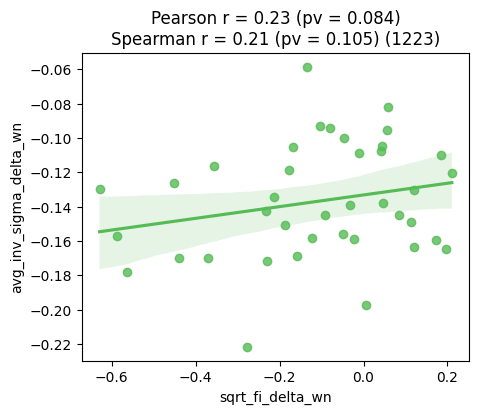

In [149]:
subrange = '1223' # 'narrowrange', '1124', '1223', '1322'
model_label = 18
subjects = index_filter(fisher_info_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
#subjects = set(subjects) - set((36,)) # 24, 33, 36
for (x_fi, y_stan) in [ ('sqrt_fi_delta_wn', 'avg_inv_sigma_delta_wn'),
                       ]:
    plt.figure(figsize=(5,4))
    xxx = index_filter(fisher_info_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label)[x_fi] # model_label=model_label, 
    yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[y_stan] 
    sns.regplot(x=xxx, y=yyy, color=THIRD_COLOR)
    p_corr_res = pg.corr(xxx, yyy, method='pearson', alternative='greater') # stats.spearmanr(xxx, yyy)
    s_corr_res = pg.corr(xxx, yyy, method='spearman', alternative='greater')
    plt.title(f"Pearson r = {p_corr_res.r.iloc[0]:.2f} (pv = {p_corr_res['p-val'].iloc[0]:.3f})\n"
            f"Spearman r = {s_corr_res.r.iloc[0]:.2f} (pv = {s_corr_res['p-val'].iloc[0]:.3f}) ({subrange})")

### Variability across x

In [150]:
index_filter(fisher_info, model_label=15)

fi    log_fi   sqrt_fi    inv_fi  inv_sqrt_fi     log_n  one_over_n
subject n    condition                                                                           
1       10.0 narrow     5.692601  1.739167  2.385917  0.175667     0.419126  2.302585    0.100000
        11.0 narrow     3.702477  1.309002  1.924182  0.270089     0.519701  2.397895    0.090909
        12.0 narrow     0.979151 -0.021069  0.989521  1.021293     1.010590  2.484907    0.083333
        13.0 narrow     1.185767  0.170390  1.088929  0.843336     0.918333  2.564949    0.076923
        14.0 narrow     0.537878 -0.620123  0.733402  1.859156     1.363509  2.639057    0.071429
...                          ...       ...       ...       ...          ...       ...         ...
41      36.0 wide       0.289024 -1.241244  0.537610  3.459915     1.860085  3.583519    0.027778
        37.0 wide       0.270477 -1.307566  0.520074  3.697166     1.922802  3.610918    0.027027
        38.0 wide       0.253010 -1.374326  0.503001  3.952413     1.988068  3.637586    0.026316
        39.0 wide       0.236594 -1.441408  0.486410  4.226645     2.055881  3.663562    0.025641
        40.0 wide       0.221195 -1.508711  0.470314  4.520899     2.126241  3.688879    0.025000

[1833 rows x 7 columns]

If $\mu(x) = \log(x)$, then $I(x) = (\mu'(x)/\sigma)^2$, i.e., $\log I(x) = -2 \log x - \log \sigma^2$.

In [151]:
z = []
model_label = 31
subjs = index_filter(fisher_info, model_label=model_label).index.get_level_values('subject').unique()
for subject in subjs:
    for cond in CONDITIONS:
        dat = index_filter(fisher_info, subject=subject,condition=cond, model_label=model_label)
        res = quick_ols(y=dat.log_fi, x=dat.log_n)
        z.append([subject, cond, res.params.log_n])
fi_log_I_n_slopes = pd.DataFrame(z, columns=['subject', 'condition', 'slope']).set_index(['subject', 'condition'])
fi_log_I_n_slopes

slope
subject condition          
1       narrow    -2.261165
        wide      -2.582113
2       narrow    -0.559262
        wide      -0.721642
3       narrow    -2.433253
...                     ...
39      wide      -2.130958
40      narrow    -0.935793
        wide      -1.890423
41      narrow    -1.994930
        wide      -1.646614

[78 rows x 1 columns]

In [152]:
#sns.histplot(fi_log_I_n_slopes, x='slope', hue='condition', cumulative=False, element='step', kde=True )
fi_log_I_n_slopes.describe()

,slope
count,78.000000
mean,-2.380600
std,1.432373
min,-5.499747
25%,-3.240333
50%,-2.367059
75%,-1.533794
max,1.301140


In [153]:
stan_log_var_n_ols.index.get_level_values('subject').unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

In [154]:
stan_log_var_n_ols

slope  intercept        r2          pval
boundary_buffer subject condition                                             
0               1       narrow     0.182768   0.928854  0.063102  3.480027e-01
                        wide       0.569543   0.363548  0.553942  1.587710e-06
                2       narrow    -0.197296   2.135654  0.068892  3.260568e-01
                        wide       0.670156   0.108912  0.472786  1.923060e-05
                3       narrow     0.511828   0.380341  0.220605  6.641074e-02
...                                     ...        ...       ...           ...
2               39      wide       0.968086  -0.869822  0.657921  2.871449e-07
                40      narrow    -0.105685   1.693801  0.018092  6.768468e-01
                        wide       0.549627   0.420890  0.429727  2.059371e-04
                41      narrow    -0.452917   2.618354  0.205446  1.389140e-01
                        wide       0.687404   0.262765  0.376131  6.698478e-04

[234 rows x 4 columns]

          n         r          CI95%     p-val   BF10     power
pearson  39  0.067734  [-0.25, 0.38]  0.682019  0.216  0.069205
          n         r         CI95%     p-val   BF10     power
pearson  39  0.442143  [0.15, 0.66]  0.004829  9.171  0.821439


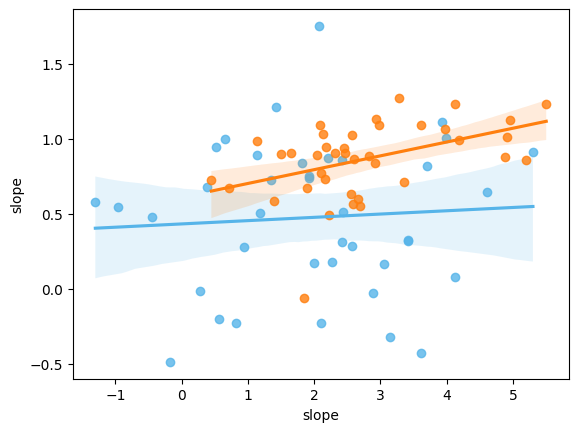

In [155]:
for cond in CONDITIONS:
    xxx = index_filter(-fi_log_I_n_slopes, condition=cond, subject=stan_log_var_n_ols.index.get_level_values('subject').unique()).slope
    yyy = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=0).slope
    print(pg.corr(xxx, yyy)) # method='spearman'
    sns.regplot(x=xxx, y=yyy, color=COLORS_COND[cond], )

          n        r           CI95%     p-val      BF10     power
pearson  39 -0.66733  [-0.81, -0.45]  0.000003  6328.212  0.998276
          n         r           CI95%         p-val       BF10     power
pearson  39 -0.733146  [-0.85, -0.54]  1.109407e-07  1.539e+05  0.999895


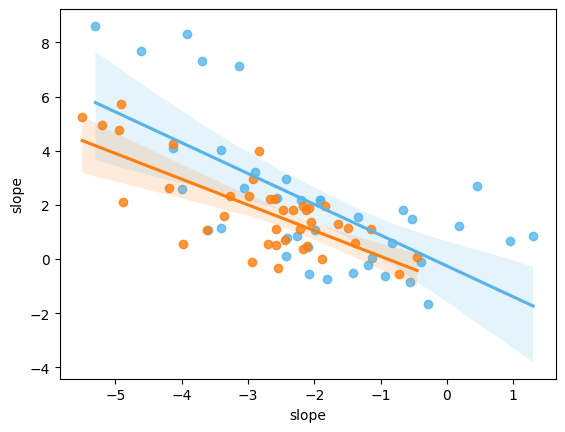

In [156]:
for cond in CONDITIONS:
    xxx = index_filter(fi_log_I_n_slopes, condition=cond, subject=stan_log_var_n_ols.index.get_level_values('subject').unique()).slope
    yyy = index_filter(fmri_log_var_n_ols, condition=cond, model_label=31, boundary_buffer=0, wide=True).slope
    print( pg.corr(xxx, yyy) )
    sns.regplot(x=xxx, y=yyy, color=COLORS_COND[cond], )

# Actual trials fMRI-derived estimates and posteriors

In [157]:
beh.groupby(['subject', 'range', 'n']).response.std().groupby('range').describe()

,count,mean,std,min,25%,50%,75%,max
range,,,,,,,,
narrow,624.0,1.973409,0.578030,0.0,1.601282,1.926321,2.332247,3.777464
wide,1206.0,3.019566,1.237478,0.0,2.168589,2.939195,3.753699,8.895067


In [158]:
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  
spherical_noise subject condition t                                   
False           1       narrow    1              low            high  
                                  2              low             low  
                                  3              low            high  
                                  4              low             low  
                                  5              low             low  
...                                              ...             ...  
True            41      wide      236            low             low  
                                  237           high             low  
                                  238           high             low  
                                  239            low            high  
                                  240           high            high  

[37440 rows x 14 columns]

In [159]:
da = index_filter(fmri_trial_resps, spherical_noise=True)
print( pg.corr( da.response, da.E, alternative='greater' ) )
for cond in CONDITIONS:
    print(f'••• {cond} •••')
    da = index_filter(fmri_trial_resps, condition=cond, spherical_noise=True)
    print( pg.corr( da.response, da.E, alternative='greater' ) )
    subject_corrs = da.groupby(level='subject').apply(lambda g: pg.corr(g.response, g.E, alternative='greater'))
    print( subject_corrs.describe() )

             n       r       CI95%          p-val        BF10  power
pearson  18282  0.2111  [0.2, 1.0]  1.549455e-183  1.596e+179    1.0
••• narrow •••
            n        r        CI95%         p-val       BF10     power
pearson  9145  0.05351  [0.04, 1.0]  1.526948e-07  1.289e+04  0.999746
                n          r      p-val      power
count   39.000000  39.000000  39.000000  39.000000
mean   234.487179   0.048405   0.316477   0.273929
std      3.299695   0.071338   0.274852   0.279247
min    226.000000  -0.090395   0.001685   0.001267
25%    233.000000  -0.000321   0.050911   0.049527
50%    235.000000   0.042711   0.259620   0.158810
75%    237.000000   0.108076   0.501954   0.501384
max    239.000000   0.188923   0.915004   0.903028
••• wide •••
            n         r        CI95%     p-val     BF10     power
pearson  9137  0.043892  [0.03, 1.0]  0.000014  174.998  0.994659
                n          r      p-val      power
count   39.000000  39.000000  39.000000  39.000000

## Bambi -- see dedicated notebook

## Excursions

In [160]:
excursions = beh.groupby(['subject', 'range', 'n'])[['response','range','n']].apply(lambda x: 
                x.response - stan_subj_n.loc[(int(x.index.get_level_values('subject').unique()[0]), x.range.unique()[0], x.n.unique()[0])].m
                )
excursions = excursions.droplevel([0,1,2])
excursions

subject  session  run  trial_nr
01       1        1    7          -1.6271
                       22          0.3729
                       29         -1.6271
                  2    7          -1.6271
                       14         -1.6271
                                    ...  
41       1        7    19          1.7251
         2        1    16          2.7251
                       28          2.7251
                       29          2.7251
                  4    4           0.7251
Name: response, Length: 18720, dtype: float64

In [161]:
beh['excursion'] = excursions
beh

onset  phase  response  nr_frames     n  jitter  start_marker_position  response_time   onset_abs  duration   range  error  \
subject session run trial_nr                                                                                                                                    
01      1       1   1          68.826307      5       NaN       30.0  11.0     6.0                   24.0            NaN   76.378611  0.500457  narrow    NaN   
                    2          76.016292      5      19.0       31.0  23.0     4.0                   14.0       1.317963   83.568595  0.517188  narrow   -4.0   
                    3          87.026471      5      25.0       30.0  23.0     6.0                   11.0       0.834244   94.578775  0.500469  narrow    2.0   
                    4          97.085656      5      24.0       30.0  22.0     5.0                   22.0       1.701381  104.637959  0.500559  narrow    2.0   
                    5         106.744768      5      17.0       31.0  21.0     5.0                   22.0       2.018881  114.297072  0.517009  narrow   -4.0   
...                                  ...    ...       ...        ...   ...     ...                    ...            ...         ...       ...     ...    ...   
41      2       8   26        275.797056      5      25.0       30.0  24.0     4.0                   12.0       1.635028  278.746204  0.500532  narrow    1.0   
                    27        286.857371      5      24.0       30.0  19.0     6.0                   15.0       1.701679  289.806518  0.500510  narrow    5.0   
                    28        296.683059      5      22.0       30.0  17.0     5.0                   15.0       0.100000  299.632207  0.500525  narrow    5.0   
                    29        307.476458      5      19.0       30.0  19.0     6.0                   20.0       1.751607  310.425606  0.500458  narrow    0.0   
                    30        317.202043      5      19.0       30.0  19.0     5.0                   24.0       0.049945  320.151190  0.500598  narrow    0.0   

                              abs_error  squared_error  excursion  
subject session run trial_nr                                       
01      1       1   1               NaN            NaN        NaN  
                    2               4.0           16.0    -3.0543  
                    3               2.0            4.0     2.9457  
                    4               2.0            4.0     1.7902  
                    5               4.0           16.0    -3.2187  
...                                 ...            ...        ...  
41      2       8   26              1.0            1.0     1.2431  
                    27              5.0           25.0     3.1827  
                    28              5.0           25.0     2.8592  
                    29              0.0            0.0    -1.8173  
                    30              0.0            0.0    -1.8173  

[18720 rows x 15 columns]

In [162]:
excursions_fmri = fmri_trial_resps.groupby(['spherical_noise', 'subject', 'condition', 'n'])[['response', 'n']].apply(lambda x: 
                x.response - stan_fmri_subj_n.loc[(int(x.index.get_level_values('subject').unique()[0]),
                                                   x.index.get_level_values('condition').unique()[0],
                                                   x.n.unique()[0],
                                                   x.index.get_level_values('spherical_noise').unique()[0])].m
                )
excursions_fmri = excursions_fmri.droplevel([0,1,2,3])
excursions_fmri

spherical_noise  subject  condition  t  
False            1        narrow     7      -6.7592
                                     22     -4.7592
                                     29     -6.7592
                                     37     -6.7592
                                     44     -6.7592
                                             ...   
True             41       wide       79     14.5037
                                     136    15.5037
                                     148    15.5037
                                     149    15.5037
                                     214    13.5037
Name: response, Length: 37440, dtype: float64

In [163]:
fmri_trial_resps['excursion'] = excursions_fmri
fmri_trial_resps

response     n  response_time  error  abs_error  squared_error          E        sd   E_narrow     E_wide  sd_narrow   sd_wide  \
spherical_noise subject condition t                                                                                                                                     
False           1       narrow    1         NaN  11.0            NaN    NaN        NaN            NaN  17.537264  5.247544  17.537264  28.895398   5.247544  6.506345   
                                  2        19.0  23.0       1.317963   -4.0        4.0           16.0  18.092014  2.777531  18.092014  22.410648   2.777531  6.116189   
                                  3        25.0  23.0       0.834244    2.0        2.0            4.0  17.128694  3.821620  17.128694  26.572495   3.821620  7.904282   
                                  4        24.0  22.0       1.701381    2.0        2.0            4.0  13.736838  2.043997  13.736838  14.762215   2.043997  3.323689   
                                  5        17.0  21.0       2.018881   -4.0        4.0           16.0  13.780057  2.001030  13.780057  14.782096   2.001030  3.248581   
...                                         ...   ...            ...    ...        ...            ...        ...       ...        ...        ...        ...       ...   
True            41      wide      236      29.0  24.0       0.283771    5.0        5.0           25.0  12.409954  0.526706  12.409954  12.409954   0.526706  0.526706   
                                  237      39.0  34.0       0.930894    5.0        5.0           25.0  39.976022  0.046817        NaN  39.976022        NaN  0.046817   
                                  238      39.0  32.0       0.817487    7.0        7.0           49.0  39.986598  0.026446        NaN  39.986598        NaN  0.026446   
                                  239      10.0  10.0       1.501680    0.0        0.0            0.0  20.269931  0.700548  20.269931  20.269931   0.700548  0.700548   
                                  240      29.0  24.0       2.085694    5.0        5.0           25.0  15.565216  0.621741  15.565216  15.565216   0.621741  0.621741   

                                      E_median_split sd_median_split  excursion  
spherical_noise subject condition t                                              
False           1       narrow    1              low            high        NaN  
                                  2              low             low     1.7735  
                                  3              low            high     7.7735  
                                  4              low             low     6.9846  
                                  5              low             low    -0.0594  
...                                              ...             ...        ...  
True            41      wide      236            low             low     4.2404  
                                  237           high             low    14.8018  
                                  238           high             low    14.3647  
                                  239            low            high   -13.8570  
                                  240           high            high     4.2404  

[37440 rows x 15 columns]

In [164]:
pd.concat([
    pg.corr( index_filter(fmri_trial_resps, spherical_noise=True).excursion, beh.excursion, method='pearson'),
    pg.corr( index_filter(fmri_trial_resps, spherical_noise=False).excursion, beh.excursion, method='pearson'),
], keys=['spherical_noise', 'no_spherical_noise'])

,,n,r,CI95%,p-val,BF10,power
spherical_noise,pearson,18097,0.157942,"[0.14, 0.17]",2.052190e-101,1.659e+97,1.0
no_spherical_noise,pearson,18097,0.154393,"[0.14, 0.17]",6.103498e-97,5.711e+92,1.0


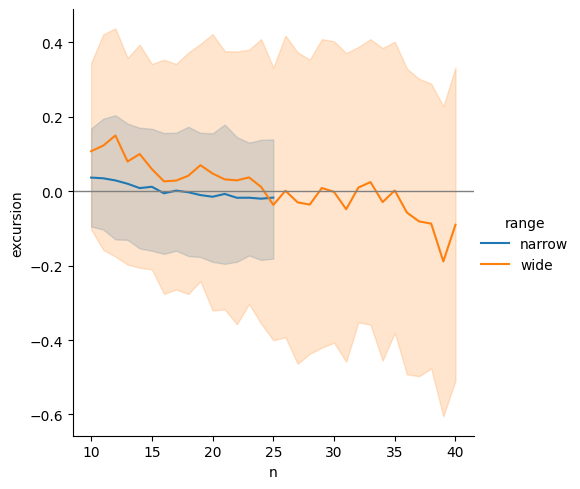

In [165]:
sns.relplot(data=beh, x='n', y='excursion', hue='range', kind='line', )
axhline(0, color='grey', ls='-', lw=1)

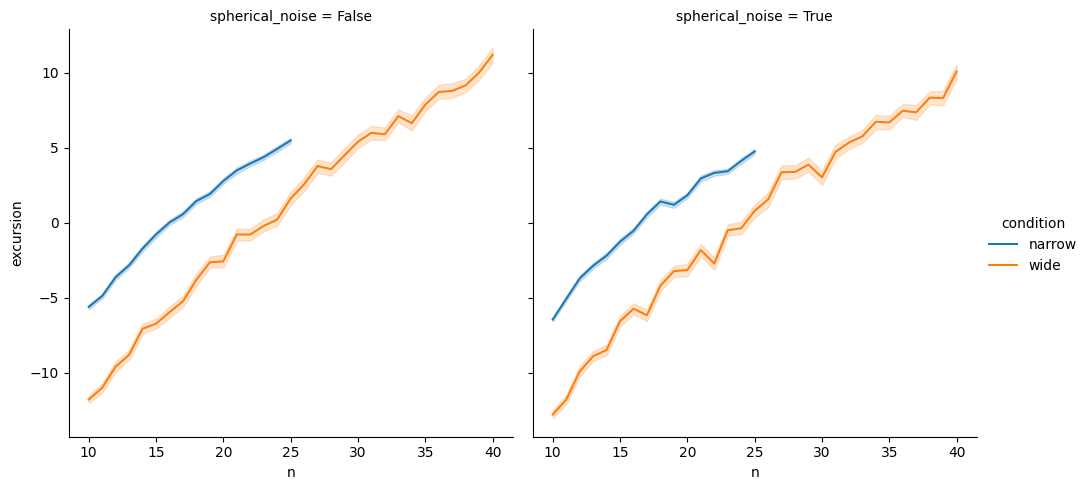

In [166]:
sns.relplot(data=index_filter(fmri_trial_resps), x='n', y='excursion', hue='condition', kind='line', col='spherical_noise')

<Axes: xlabel='excursion', ylabel='Count'>

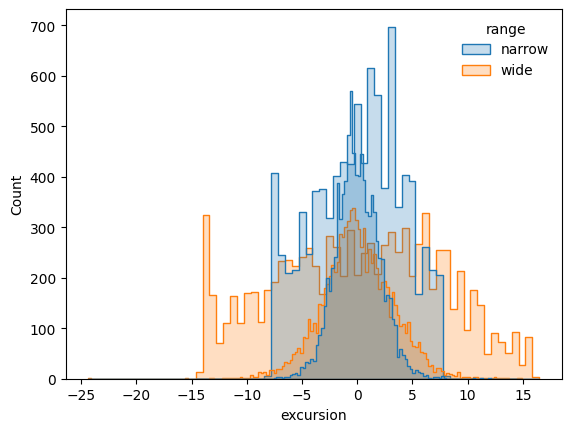

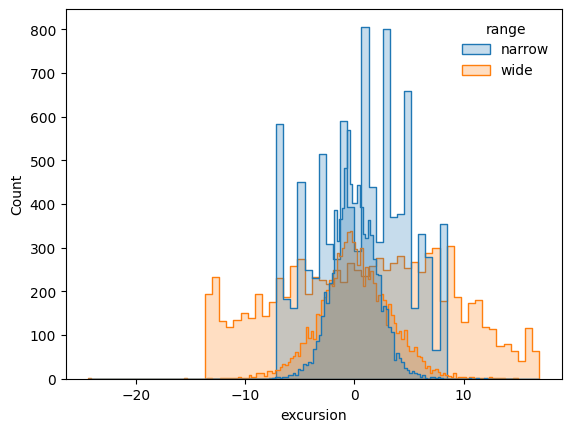

In [167]:
sns.histplot(index_filter(fmri_trial_resps, spherical_noise=True), x='excursion', element='step', hue='condition',)
sns.histplot(beh, x='excursion', element='step', hue='range')
figure()
sns.histplot(index_filter(fmri_trial_resps, spherical_noise=False), x='excursion', element='step', hue='condition',)
sns.histplot(beh, x='excursion', element='step', hue='range')

## Posterior

# ⭐️ FIGURE

• inv_sqrt_fi
Paired t-test: t = -6.529, p = 1.07e-07, dof = 38
• mean_abs_error
Narrow 0.6861819308619469 Wide 0.7988711471158726
Paired t-test: t = -3.48467, p = 0.00126, dof = 38
• Variability, fMRI vs behavior
narrow
fMRI-sigma, stan-avg_sigma: spearman correlation
           n         r         CI95%   p-val     power
spearman  39  0.432996  [0.14, 0.66]  0.0059  0.802965
wide
fMRI-sigma, stan-avg_sigma: spearman correlation
           n         r         CI95%     p-val     power
spearman  39  0.336032  [0.02, 0.59]  0.036484  0.563901
• Change in variability
Subject 24: 1.58693
Other subjects: Mean = 0.817, SD = 0.155
Subject 24 is 4.98 SD away from the mean of other subjects.
           n         r         CI95%     p-val     power
spearman  38  0.370828  [0.06, 0.62]  0.021907  0.644238
• Variability, across x
Subject 24: -0.06350988961507142
Other subjects: Mean = 0.891, SD = 0.204
Subject 24 is -4.68 SD away from the mean of other subjects.
           n         r         CI9

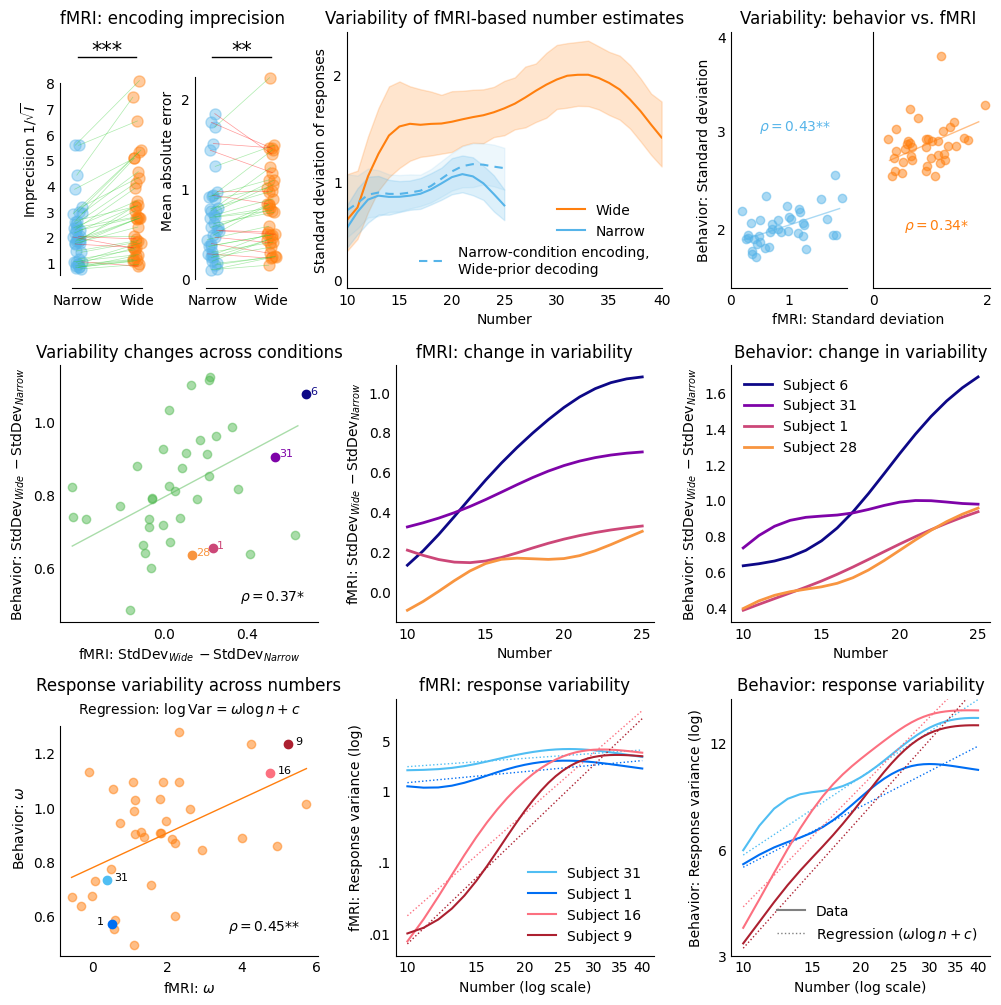

In [117]:
fig, axs = plt.subplots(figsize=(12, 12), nrows=3, ncols=3, gridspec_kw=dict(hspace=.3, wspace=0.3))
#fig = plt.figure(figsize=(12, 12))
#gs_toprow = GridSpec(nrows=3, ncols=4, figure=fig, width_ratios=[.4, .4, 1.2, 1.], hspace=.3,) # wspace=.3*4/3)

SHOW_DECODING_IMPRECISION = True
CORR_METHOD = 'spearman' # 'pearson' 
CORR_LETTER = {'spearman':'\\rho', 'pearson':'r'}[CORR_METHOD]

##### sqrt{I}
#ax = fig.add_subplot(gs_toprow[0, 0])
if SHOW_DECODING_IMPRECISION:
    gs = GridSpec(nrows=3, ncols=4, figure=fig, hspace=.3, width_ratios=[.35,.35,1.3,1])
    ax = fig.add_subplot( gs[0,0] )
    ax.set_title('fMRI: encoding imprecision', ha='left', x=0)
else:
    gs = GridSpec(nrows=3, ncols=4, figure=fig, hspace=.3, width_ratios=[.25,.25,1.4,1.1])
    ax = fig.add_subplot( gs[0,0:2] )
    ax.set_title('fMRI: encoding imprecision', ha='left', x=-.2)
axs[0, 0].remove()
model_label = 31
subrange = 'narrowrange' # '1124' # 'all'
qty = 'inv_sqrt_fi' # 'log_fi'
xx1 = index_filter(fisher_info_avgs, subrange=subrange, condition=NARROW, model_label=model_label)[qty].rename(NARROW)
xx2 = index_filter(fisher_info_avgs, subrange=subrange, condition=WIDE, model_label=model_label)[qty].rename(WIDE)
paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2, color_decr_line='red', color_incr_line='limegreen', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE])
ax.set_xlim(0.7, 2.3)
ax.set_ylim({'sqrt_fi':(-.1,2.3), 'inv_sqrt_fi':(0,10)}.get(qty, (None,None)))
ax.set_xticks([1, 2])
ax.set_yticks({'sqrt_fi':[0,1,2], 'inv_sqrt_fi':[1,2,3,4,5,6,7,8]}.get(qty, [0,1]))
#ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_xticklabels(['Narrow', 'Wide'])
###ax.set_title('fMRI: Fisher information')
# paired test
paired_test = pg.ttest(xx1, xx2, paired=True) #, alternative='less' if qty in ['inv_sqrt_fi', 'inv_fi'] else 'greater')
print(f"• {qty}")
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
y_line = {'sqrt_fi':2.1, 'inv_sqrt_fi':8.75}.get(qty, 2)
star_line(ax, 1, 2, .9, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.01, vertical_lines_length=0., yTransAxes=True)
ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds({'sqrt_fi':(0,2), 'inv_sqrt_fi':(.5,8)}.get(qty, (None,None)))
ax.spines.bottom.set_bounds((.9, 2.1))
ax.set_ylabel({'sqrt_fi':'$\sqrt{I}$', 'inv_sqrt_fi':'Imprecision $1/\sqrt{I}$'}.get(qty, qty))


###### MSE, or Std Dev of estimates
if SHOW_DECODING_IMPRECISION:
    #ax = fig.add_subplot(gs_toprow[0, 1])
    ax = fig.add_subplot( gs[0,1] )
    model_label = 31
    subrange = 'narrowrange' # 'narrowrange' # '1124'
    wide_prior = False # True
    qty = 'mean_abs_error' # 'sigma' # 'mean_abs_error' 
    xx1 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=NARROW, wide=wide_prior)[qty].rename(NARROW)
    xx2 = index_filter(fmri_estimates_avgs, model_label=model_label, subrange=subrange, condition=WIDE, wide=wide_prior)[qty].rename(WIDE)
    paired_strip_plot(ax, x1=1, x2=2, y1=xx1, y2=xx2, color_decr_line='red', color_incr_line='limegreen', col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE],)
    ax.set_xlim(0.7, 2.3)
    ax.set_ylim({'sigma':(-.1,3.3), 'mean_abs_error':(-.1,2.75)}.get(qty, (0,3.3)))
    ax.set_yticks({'sigma':[0,1,2,3], 'mean_abs_error':[0,1,2]}.get(qty, [0,1,2]))
    ax.set_xticks([1, 2])
    #ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
    ax.set_xticklabels(['Narrow', 'Wide'])
    #ax.set_title('Imprecision of fMRI-derived number estimates', ha='left', x=0)
    #ax.set_title('Imprecision in neural encoding and in number estimates', ha='left', x=0)
    # paired test
    paired_test = pg.ttest(xx1, xx2, paired=True) #, alternative='less')
    print(f"• {qty}")
    print('Narrow', xx1.mean(), 'Wide', xx2.mean())
    print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.5f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
    star_line(ax, 1, 2, .9, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.01, vertical_lines_length=0., yTransAxes=True)
    ax.tick_params(axis='both', length=0)
    ax.spines.left.set_bounds({'sigma':(0, 3.), 'mean_abs_error':(0, 2.25)}.get(qty, (None,None)))
    ax.spines.bottom.set_bounds((.9, 2.1))
    ax.set_ylabel({'sigma':'Average standard deviation', 'mean_abs_error':'Mean absolute error'}.get(qty, qty))


###### Standard deviation of estimates, vs number
## ••• /!\ Here we use the estimates decoded with each correct prior ! ••• ##
axs[0,1].remove()
#ax = fig.add_subplot(gs_toprow[0, 2])
#ax = fig.add_subplot(3, 3, 2)
if SHOW_DECODING_IMPRECISION:
    this_gs = GridSpec(nrows=3, ncols=3, figure=fig, width_ratios=[.85, 1.15, 1.], hspace=.3, wspace=.2) # wspace=.3*4/3) # width_ratios=[.7, 1.3, 1.]
else:
    this_gs = GridSpec(nrows=3, ncols=3, figure=fig, width_ratios=[.65, 1.25, 1.1], hspace=.3, wspace=.2)
ax = fig.add_subplot(this_gs[0,1])
#ax = axs[0,1]
ax.set_ylim(0, 2.4)
for cond in [WIDE, NARROW]:
    sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide=cond==WIDE, condition=cond, n=range(10,MAX_COND[cond]+1)), x='n', y='sigma', label=cond.capitalize(),
                 color=COLORS_COND[cond], ax=ax)
sns.lineplot(index_filter(fmri_estimates_stats, model_label=31, wide=True, condition=NARROW, n=range(10,26)), x='n', y='sigma',
             label='Narrow-condition encoding,\nWide-prior decoding', 
             color=COLORS_COND[NARROW], ax=ax, dashes=[4, 3],err_kws=dict(alpha=.1)) # errorbar=None, #  gapcolor=COLORS_COND[WIDE], 
leg_hands = list(zip( *ax.get_legend_handles_labels() ))
leg1 = ax.legend( *zip( *leg_hands[:2] ), loc=(.65, .175) )
leg2 = ax.legend( *zip( *leg_hands[2:] ), loc='lower right' )
ax.add_artist(leg1) 
ax.set_xlim(10, 40)
ax.set_xlabel('Number')
ax.set_ylabel('Standard deviation of responses')
#ax.legend(loc='lower right', )
ax.set_yticks([0, 1, 2])
ax.tick_params(axis='both', length=0)
ax.get_yticklabels()[0].set_va('bottom')
ax.set_title('Variability of fMRI-based number estimates')


###### Variability of estimates, fMRI vs behavior
#ax = fig.add_subplot(gs_toprow[0, 3])
#ax = fig.add_subplot(3, 3, 3)
model_label = 31
subrange = 'narrowrange' #'narrowrange' # '1124'
wide_prior = False #'cond'
qtyFMRI = 'sigma'; qtySTAN = 'avg_sigma'
#qtyFMRI = 'var_E'; qtySTAN = 'avg_var'
subjs = set(index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label).index.get_level_values('subject').unique()).intersection(
        index_filter(stan_avgs, subrange=subrange).index.get_level_values('subject').unique())
print("• Variability, fMRI vs behavior")
if False:
    ax = axs[0,2]
    for cond in CONDITIONS:
        wp = wide_prior if wide_prior != 'cond' else cond == WIDE
        xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide_prior=wp)[qtyFMRI]
        yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
        ax.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
        res_odr = odr_1dregression(x=xxx, y=yyy)
        x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
        ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
        print(cond)
        r_pearson = pg.corr(xxx, yyy, alternative='greater')
        print(r_pearson)
        print(pg.corr(xxx, yyy, method='spearman', alternative='greater' ))
        pv = r_pearson['p-val'].iloc[0]
        ax.text({NARROW:.95, WIDE:.05}[cond], {NARROW:.05, WIDE:.95}[cond], f"r = {r_pearson.r.iloc[0]:.2f}{star_string(pv)}", transform=ax.transAxes, va='center', color=COLORS_COND[cond],
                ha='right' if cond == NARROW else 'left',  )
    ax.set_yticks([2,2.5,3, 3.5])
    if False:
        for subj in subjs:
            x1 = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='narrow', wide_prior=wide_prior if wide_prior != 'cond' else False)[qtyFMRI][subj]
            x2 = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition='wide'  , wide_prior=wide_prior if wide_prior != 'cond' else True)[qtyFMRI][subj]
            y1 = index_filter(stan_avgs, subrange=subrange, condition='narrow')[qtySTAN][subj]
            y2 = index_filter(stan_avgs, subrange=subrange, condition='wide')[qtySTAN][subj]
            plt.plot([x1, x2], [y1, y2],
                #color='limegreen' if (x2 > x1 and y2 > y1) else "#F75656", # if (x2 < x1 and y2 < y1) else 'gray',
                color='grey',
                alpha=0.5, linewidth=1
            )
    ax.set_title('Variability: behavior vs. fMRI')
    ax.set_xlabel('fMRI: Standard deviation')
    ax.set_ylabel('Behavior: Standard deviation')
    ax.tick_params(axis='both', length=0)
else:
    axs[0,2].remove()
    if SHOW_DECODING_IMPRECISION:
        gs = GridSpec(nrows=3, ncols=6, figure=fig, hspace=.3, width_ratios=[1, 1, 1, 1.85, 1, 1])
    else:
        gs = GridSpec(nrows=3, ncols=6, figure=fig, hspace=.3, width_ratios=[1, 1, 1, 1.75, 1.15, 1.15])
    these_axs = [ fig.add_subplot( gs[0,4], ), ]
    these_axs.append( fig.add_subplot( gs[0,5], sharey=these_axs[0] ) )
    rs = {}
    for ic,cond in enumerate(CONDITIONS):
        ax = these_axs[ic]
        xxx = index_filter(fmri_estimates_avgs, subrange=subrange, model_label=model_label, condition=cond, subject=subjs, wide=wide_prior)[qtyFMRI]
        yyy = index_filter(stan_avgs, subrange=subrange, condition=cond, subject=subjs)[qtySTAN]
        ax.scatter(xxx, yyy, alpha=0.5, color=COLORS_COND[cond], )
        res_odr = odr_1dregression(x=xxx, y=yyy)
        x_vals = np.array([np.percentile(xxx, 1), np.percentile(xxx, 99)])
        ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=COLORS_COND[cond], )
        print(cond)
        r_corr = pg.corr(xxx, yyy, method=CORR_METHOD) #, alternative='greater')
        rs[cond] = r_corr
        print(f'fMRI-{qtyFMRI}, stan-{qtySTAN}: {CORR_METHOD} correlation')
        print(r_corr)
        #print(pg.corr(xxx, yyy, method='spearman', alternative='greater' ))
        ax.tick_params(axis='both', length=0)
        ax.set_xlim(0,None)
    sns.despine(fig)
    these_axs[0].set_ylabel('Behavior: Standard deviation')
    these_axs[0].set_yticks([2, 3, 4])
    these_axs[0].get_yticklabels()[2].set_va('top')
    these_axs[0].set_ylim(1.4, 4)
    these_axs[0].set_xlabel('fMRI: Standard deviation', x=1.1)
    these_axs[0].text(1.1, 3, f"${CORR_LETTER} = {rs[NARROW].r.iloc[0]:.2f}${star_string(rs[NARROW]['p-val'].iloc[0])}", color=COLORS_COND[NARROW], ha='center')
    these_axs[1].text(1.1, 2, f"${CORR_LETTER} = {rs[WIDE].r.iloc[0]:.2f}${star_string(rs[WIDE]['p-val'].iloc[0])}", color=COLORS_COND[WIDE], ha='center')
    these_axs[1].tick_params(labelleft=False)
    these_axs[0].set_title('Variability: behavior vs. fMRI', x=1.1, ha='center')


###### Changes in variability
ax = axs[1,0] # fig.add_subplot(gs_row2and3[2, 0])
subrange = 'narrowrange'
model_label = 18
wide_prior = False
subjects = index_filter(fmri_ests_avgs_deltas, model_label=model_label).index.get_level_values('subject').unique()
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
#qtyX, qtyY = 'var_E_diff', 'avg_var_delta_wn'
xxx = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide=wide_prior)[qtyX] # model_label=15,
yyy = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[qtyY]
subjects = set(subjects) - set((24,))
xxx_excl24 = index_filter(fmri_ests_avgs_deltas, subrange=subrange, subject=subjects, model_label=model_label, wide=wide_prior)[qtyX] # model_label=15,
yyy_excl24 = index_filter(stan_delta_avgs, subrange=subrange, subject=subjects)[qtyY]
print("• Change in variability")
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
iis = [6, 31, 1, 28 ]
ax.scatter(x=xxx_excl24[~np.isin(xxx_excl24.index, iis)], y=yyy_excl24[~np.isin(yyy_excl24.index, iis)], color=THIRD_COLOR, alpha=.5)
# for subj in subjects: ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
cols = cm.plasma
for k, i in enumerate(iis):
    ax.scatter(x=xxx.loc[i], y=yyy.loc[i], color=cols(k / len(iis)),)
    ax.text(xxx[i]+.02, yyy[i], str(i), color=cols(k / len(iis)), fontsize=8,)
#sns.regplot(x=xxx, y=yyy, color=THIRD_COLOR, ax=ax)
res_odr = odr_1dregression(x=xxx_excl24, y=yyy_excl24)
x_vals = np.array([np.percentile(xxx_excl24, 2), np.percentile(xxx_excl24, 98)])
ax.plot(x_vals, odr_pred(res_odr, x_vals), lw=1, alpha=0.5, c=THIRD_COLOR, )
r_corr = pg.corr(xxx_excl24, yyy_excl24, method=CORR_METHOD) 
print(r_corr)
ax.set_title('Variability changes across conditions') #('Individual adaptations')
ax.set_xlabel('fMRI: $\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$')
ax.set_ylabel('Behavior: $\operatorname{StdDev}_{Wide} - \operatorname{StdDev}_{Narrow}$')
pv = r_corr['p-val'].iloc[0]
ax.text(0.95, 0.1, f"${CORR_LETTER} = {r_corr.r.iloc[0]:.2f}${star_string(pv)}", transform=ax.transAxes, va='center', ha='right', ) #fontsize=12, )
ax.set_xticks([0, .4])
ax.set_yticks([.6, .8, 1])
ax.tick_params(axis='both', length=0)

########### Example subjects
ax_fmri = axs[1, 1] # fig.add_subplot(gs_row2and3[2, 1])
ax_beh  = axs[1, 2] # fig.add_subplot(gs_row2and3[2, 2])
subrange = '1124'
model_label = 18
wide_prior = False
qtyX, qtyY = 'sigma_diff', 'avg_sigma_delta_wn'
iis = [6, 31, 1, 28 ] # 2, 30
ns = np.arange(10, 25+1)
cols = cm.plasma
conv_w = 3
lw = 2.
for k,ii in enumerate(iis):
    xs, ys = smooth_ys(conv_w, ns, index_filter(fmri_estimates_deltas, model_label=model_label, n=ns, subject=ii, wide=False).sigma_diff, xs=ns)
    ax_fmri.plot(ns, ys, c=cols(k/(len(iis))), label=f'Subject {ii}', lw=lw)
    #axs[0].text(ns[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
    xs, ys = smooth_ys(conv_w, ns, index_filter(stan_deltas_subj_n, n=ns, subject=ii).delta_sigma, xs=ns)
    ax_beh.plot(xs, ys , c=cols(k/(len(iis))), label=f'Subject {ii}', lw=lw)
    #axs[1].text(xs[-1]+.5, ys[-1], str(ii), color=cols(k/(len(iis))), fontsize=8, ha='left', va='center')
ax_beh.legend(loc='upper left', )
#axs[0].set_yticks([.5, 1, 1.5, 2, ])
for i, ax in enumerate((ax_fmri, ax_beh)):
    ax.set_xlabel('Number')
    ax.tick_params(axis='both', length=0)
    z = 'fMRI' if i == 0 else 'Behavior'
    ax.set_ylabel(f'{z}: $\operatorname{{StdDev}}_{{Wide}} - \operatorname{{StdDev}}_{{Narrow}}$')
    ax.set_xticks([10,15,20,25])
    #ax.set_ylim(0,None)
ax_fmri.set_title('fMRI: change in variability')
ax_beh.set_title('Behavior: change in variability')



######## Variability across x: Weber exponent
#ax = fig.add_subplot(gs_row2and3[1, 0])
ax = axs[2,0]
model_label = 31
cond = WIDE
boundary_buffer = 0
wide_prior = True
c = COLORS_COND[cond] # FOURTH_COLOR
subjs = set(index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique()).intersection(
    index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).index.get_level_values('subject').unique())
xxx = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide=wide_prior).slope
yyy = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
subjs = set(subjs) - set((24,))
xxx_excl24 = index_filter(fmri_log_var_n_ols, condition=cond, model_label=model_label, subject=subjs, boundary_buffer=boundary_buffer, wide=wide_prior).slope
yyy_excl24 = index_filter(stan_log_var_n_ols, condition=cond, subject=subjs, boundary_buffer=boundary_buffer).slope
print("• Variability, across x")
if 24 in yyy:
    mm, sd = yyy.drop(24).describe()[['mean', 'std']]
    print('Subject 24:', yyy[24])
    print(f"Other subjects: Mean = {mm:.3f}, SD = {sd:.3f}")
    print(f"Subject 24 is {((yyy[24] - mm) / sd):.2f} SD away from the mean of other subjects.")
someSubjs = [31, 1, 16, 9]
ns = np.arange(10, MAX_COND[cond]+1)
cols = ['#50BEF3', '#006EF3', '#FC7080', '#aC2030', ]
cols_sid = {sid:col for sid, col in zip(someSubjs, cols)}
r_corr = pg.corr(xxx_excl24, yyy_excl24, method=CORR_METHOD) #, alternative='greater' )
print( r_corr ) # method='spearman'
ax.scatter(x=xxx_excl24[~np.isin(xxx_excl24.index, someSubjs)], y=yyy_excl24[~np.isin(yyy_excl24.index, someSubjs)], color=c, alpha=.5)
for k,subj in enumerate(someSubjs):
    ax.scatter(x=xxx[subj], y=yyy[subj], color=cols_sid[subj], alpha=1., label=f'Subject {subj}',) #ec='k', lw=1)
ax.text(xxx.loc[31]+.2, yyy.loc[31], '31', color='k', fontsize=8,)
ax.text(xxx.loc[ 1]-.4, yyy.loc[ 1],  '1', color='k', fontsize=8,)
ax.text(xxx.loc[16]+.2, yyy.loc[16], '16', color='k', fontsize=8,)
ax.text(xxx.loc[ 9]+.2, yyy.loc[ 9],  '9', color='k', fontsize=8,)
# for subj in subjs:
#     ax.text(xxx[subj], yyy[subj], str(subj), color='k', fontsize=8, ha='center', va='center')
#sns.regplot(x=xxx, y=yyy, color=c, ax=ax, scatter_kws={'color': c, 'alpha': .5}, )
res_odr = odr_1dregression(x=xxx_excl24, y=yyy_excl24)
x_vals = np.linspace(xxx_excl24.min(), xxx_excl24.max(), 100)
ax.plot(x_vals, odr_pred(res_odr, x_vals), color=c, lw=1,)
ax.set_title('Response variability across numbers')
ax.text(.5, .945, 'Regression: $\log \operatorname{Var} = \omega \log n + c$', transform=ax.transAxes, ha='center', )
ax.set_xlabel('fMRI: $\omega$')
ax.set_ylabel('Behavior: $\omega$')
pv = r_corr['p-val'].iloc[0]
ax.text(0.65, 0.1, f'${CORR_LETTER} = {r_corr.r.iloc[0]:.2f}${star_string(pv)}', transform=ax.transAxes)
ax.tick_params(axis='both', length=0)
ax.set_ylim(None, 1.399)
ax.spines.left.set_bounds((ax.get_ylim()[0], 1.3))

##### example subjects
ax_fmri = axs[2,1] # fig.add_subplot(gs_row2and3[1, 1])
ax_beh  = axs[2,2] # fig.add_subplot(gs_row2and3[1, 2])
log_qties = True
conv_w = .2 if log_qties else 3
lw = 1.5
ns = np.arange(10+boundary_buffer, MAX_COND[cond]+1-boundary_buffer)
xs = np.log(ns) if log_qties else ns
qtyFMRI = 'log_var' if log_qties else 'sigma'
qtyStan = 'log_var' if log_qties else 'sigma'
for k,ii in enumerate(someSubjs):
    xs, ys = smooth_ys(conv_w, xs, index_filter(fmri_estimates_stats, model_label=model_label, condition=cond, subject=ii, n=ns, wide=wide_prior)[qtyFMRI], xs=xs)
    ax_fmri.plot(xs, ys, c=cols[k], label=f'Subject {ii}', lw=lw)
    xs, ys = smooth_ys(conv_w, xs, index_filter(stan_subj_n, condition=cond, subject=ii, n=ns)[qtyStan], xs=xs)
    ax_beh.plot(xs, ys , ls='-', c=cols[k], lw=lw)
    if log_qties:
        slope, intercept = index_filter(fmri_log_var_n_ols, model_label=model_label, condition=cond, boundary_buffer=boundary_buffer, wide=wide_prior).loc[ii][['slope', 'intercept']]
        ax_fmri.plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
        slope, intercept = index_filter(stan_log_var_n_ols, condition=cond, boundary_buffer=boundary_buffer).loc[ii][['slope', 'intercept']]
        ax_beh.plot(xs, slope*xs + intercept, ls=':', c=cols[k], lw=1)
ax_fmri.legend()
for i,ax in enumerate([ax_fmri, ax_beh]):
    ax.set_xlabel('Number' + (' (log scale)' if log_qties else ''))
    ax.tick_params(axis='both', length=0)
    z = 'fMRI' if i == 0 else 'Behavior'
    ax.set_ylabel(f'{z}: Response variance (log)' if log_qties else f'{z}: Response standard deviation')
    if log_qties:
        xticks = np.array([10, 15, 20, 25, 30, 35, 40])
        ax.set_xticks(np.log(xticks))
        ax.set_xticklabels(xticks)
if log_qties:        
    y_ticks = np.array(['.01', '.1', 1, 5])
    ax_fmri.set_yticks(np.log([float(y) for y in y_ticks]))
    ax_fmri.set_yticklabels(y_ticks)
    # print(ax_fmri.get_ylim())
    # ax_fmri.set_ylim(None, 2.5)
    y_ticks = np.array([3, 6, 12])
    ax_beh.set_yticks(np.log(y_ticks))
    ax_beh.set_yticklabels(y_ticks)
    ax_beh.set_ylim(np.log(3), np.log(16))
    ls_reg = ':'
    ax_beh.legend([Line2D([0], [0], c='grey', lw=lw), Line2D([0], [0], c='grey', ls=ls_reg, lw=1)],
                  ['Data', 'Regression ($\omega \log n + c$)'], loc='lower right')
else:
    ax_fmri.set_yticks([.5, 1, 1.5, 2, ])
ax_fmri.set_title('fMRI: response variability')
ax_beh.set_title('Behavior: response variability')


sns.despine(fig=fig)

plt.savefig('figures/fmri_beh_variability.pdf', bbox_inches='tight')